# Part 1: Book Genre Classification

In this notebook, build a complete text classification pipeline for predicting the genre of a book from its description.

The assignment compares two text representations:

1. **TF-IDF**, which represents descriptions using weighted word counts.
2. **Sentence embeddings**, which represent descriptions using dense semantic vectors from the `description_emb` column.

You will train and compare several classifiers:

- **Naive Bayes**
- **k-Nearest Neighbors**
- **Logistic Regression**
- **Multi-Layer Perceptron**

The notebook also studies class imbalance. First, train a baseline model. Then test different imbalance-handling strategies and choose the best one using the development set. Use the selected strategy for the remaining experiments.

The final model is evaluated only once on the test set. Analyze its behavior using model comparison plots, a confusion matrix, per-class scores, and error examples.

## 0. Setup

Run the setup cell before starting the assignment. Scikit-learn is installed only because PCA is used for visualization. Do not use scikit-learn classifiers, vectorizers, scalers, splitters, or metrics in this assignment.

In [2]:
!pip install -q pandas "numpy>=2.0" scipy scikit-learn matplotlib tqdm 


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install -q gdown


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import ast
import json
import math
import re
import time
import warnings
from collections import Counter, defaultdict
import gdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

from IPython.display import display
from tqdm.auto import tqdm


from sklearn.decomposition import PCA

tqdm.pandas()
warnings.filterwarnings("ignore")

# Dataset
This is the dataset you worked with in Phase 1.
Each row in the dataset represents one book. The main fields used in this assignment are:

- `description`: the text used for classification.
- `genres`: the source of the target label.
- `description_emb`: a precomputed embedding of the description.

The `description_emb` column was added before this notebook using `BAAI/bge-large-en-v1.5`. This model creates 1024-dimensional dense vectors designed to capture semantic similarity between texts.


### Run this cell if you are using colab to download the dataset automatically

In [5]:
url = "https://drive.google.com/file/d/1KGPZ7lKkxkPR4azBRLxEoG7ngo8EXrDC/view?usp=drive_link"
output = "books.csv"

#gdown.download(url, output, quiet=False, fuzzy=True)

## 1. Configuration

Set the input and output paths. The input CSV must already contain a `description_emb` column.

In [6]:
# =========================
# File paths
# =========================
CSV_PATH = "books_with_description_emb.csv"
OUTPUT_DEV_RESULTS_CSV = "classification_dev_results.csv"
OUTPUT_TEST_RESULTS_CSV = "classification_test_results.csv"
OUTPUT_TEST_PREDICTIONS_CSV = "classification_test_predictions.csv"

# =========================
# Column names
# =========================
DESCRIPTION_COLUMN = "description"
EMBEDDING_COLUMN = "description_emb"
GENRES_COLUMN = "genres"
TITLE_COLUMN = "title"

# =========================
# Dataset settings
# =========================
RANDOM_STATE = 42
TOP_N_CLASSES = 10
MIN_SAMPLES_PER_CLASS = 100

# Keep the test set untouched until final evaluation.
TRAIN_SIZE = 0.70
DEV_SIZE = 0.15
TEST_SIZE = 0.15

# =========================
# TF-IDF settings
# =========================
# Cap features to keep sparse matrix multiplications highly efficient.
MAX_TFIDF_FEATURES = 10000 
NGRAM_RANGE = (1, 2)
MIN_DF = 3 
MAX_DF = 0.8 

# =========================
# Scratch model settings
# =========================
KNN_NEIGHBORS = 5

LR_MAX_EPOCHS = 60
LR_IMBALANCE_EPOCHS = 40
LR_LEARNING_RATE = 0.5
LR_BATCH_SIZE = 512
LR_ALPHA = 1e-4



DENSE_TFIDF_FEATURES_FOR_MLP = 500 
MLP_HIDDEN_DIM = 128
MLP_MAX_EPOCHS = 35
MLP_LEARNING_RATE = 1e-3
MLP_BATCH_SIZE = 128
MLP_ALPHA = 1e-4

# =========================
# Imbalance handling settings
# =========================
IMBALANCE_STRATEGIES = [
    "none",               # baseline: keep the original training distribution
    "random_oversample",  # duplicate minority-class rows until all classes match the largest class
    "random_undersample", # sample majority-class rows down to the smallest class
    "median_resample",    # move every class toward the median class size
]

# =========================
# Visualization settings
# =========================
MAX_POINTS_FOR_PCA_PLOT = 3000
FIG_DPI = 140

## 2. Visualization utilities

Use the following plotting helpers throughout the notebook. Do not change them unless you want to improve the visual design consistently across all plots.

In [7]:
def set_research_plot_style():
    # Use a clean, publication-friendly style while keeping Matplotlib defaults for colors.
    plt.rcParams.update({
        "figure.dpi": FIG_DPI,
        "savefig.dpi": FIG_DPI,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.8,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.frameon": False,
    })


set_research_plot_style()


def add_value_labels_to_bars(ax, fmt="{:.3f}", padding=3, fontsize=8):
    for container in ax.containers:
        labels = []
        for bar in container:
            value = bar.get_height()
            if np.isnan(value):
                labels.append("")
            elif abs(value) >= 100:
                labels.append(f"{value:,.0f}")
            else:
                labels.append(fmt.format(value))
        ax.bar_label(container, labels=labels, padding=padding, fontsize=fontsize)


def plot_horizontal_count_distribution(counts, title, xlabel="Number of examples", show_percent=True):
    counts = pd.Series(counts).sort_values(ascending=True)
    total = counts.sum()

    fig_height = max(4.5, 0.42 * len(counts) + 1.5)
    fig, ax = plt.subplots(figsize=(11, fig_height))
    bars = ax.barh(counts.index.astype(str), counts.values)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Class")
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

    x_max = counts.max() if len(counts) else 1
    ax.set_xlim(0, x_max * 1.18)

    for bar, value in zip(bars, counts.values):
        if show_percent and total > 0:
            label = f"{value:,}  ({value / total:.1%})"
        else:
            label = f"{value:,}"
        ax.text(
            bar.get_width() + x_max * 0.015,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()


def plot_grouped_metric_bars(df_plot, category_col, metric_cols, title, ylabel, sort_by=None, rotation=45):
    plot_df = df_plot.copy()
    if sort_by is not None:
        plot_df = plot_df.sort_values(sort_by, ascending=False).reset_index(drop=True)

    labels = plot_df[category_col].astype(str).tolist()
    x = np.arange(len(labels))
    width = 0.78 / max(1, len(metric_cols))

    fig_width = max(11, 0.65 * len(labels) + 4)
    fig, ax = plt.subplots(figsize=(fig_width, 5.8))

    for i, metric in enumerate(metric_cols):
        offset = (i - (len(metric_cols) - 1) / 2) * width
        ax.bar(x + offset, plot_df[metric].astype(float).values, width, label=metric)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=rotation, ha="right")
    ax.set_ylim(0, min(1.05, max(0.05, plot_df[metric_cols].to_numpy().max() * 1.15)))
    ax.legend(loc="best")
    ax.grid(axis="y")
    ax.grid(axis="x", visible=False)

    add_value_labels_to_bars(ax, fmt="{:.3f}", padding=2, fontsize=7)
    plt.tight_layout()
    plt.show()


def plot_metric_heatmap(matrix_df, title, xlabel, ylabel, value_format=".3f"):
    matrix_df = matrix_df.copy()
    fig_width = max(7.5, 0.75 * matrix_df.shape[1] + 4)
    fig_height = max(4.5, 0.45 * matrix_df.shape[0] + 2)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    values = matrix_df.to_numpy(dtype=float)
    im = ax.imshow(values, aspect="auto")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(np.arange(matrix_df.shape[1]))
    ax.set_yticks(np.arange(matrix_df.shape[0]))
    ax.set_xticklabels(matrix_df.columns.astype(str), rotation=45, ha="right")
    ax.set_yticklabels(matrix_df.index.astype(str))

    for i in range(matrix_df.shape[0]):
        for j in range(matrix_df.shape[1]):
            value = values[i, j]
            if np.isfinite(value):
                ax.text(j, i, format(value, value_format), ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.grid(False)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix_professional(y_true, y_pred, class_names, title):
    cm_counts = scratch_confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    cm_norm = scratch_confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)), normalize="true")
    cm_norm = np.nan_to_num(cm_norm)

    fig_width = max(8, 0.75 * len(class_names) + 4)
    fig_height = max(7, 0.65 * len(class_names) + 3)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    im = ax.imshow(cm_norm, aspect="auto")

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            count = int(cm_counts[i, j])
            pct = cm_norm[i, j]
            if count > 0:
                label = f"{count}\n{pct:.0%}"
            else:
                label = ""
            ax.text(j, i, label, ha="center", va="center", fontsize=7)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Row-normalized proportion")
    ax.grid(False)
    plt.tight_layout()
    plt.show()


def plot_per_class_f1(report_df, title):
    plot_df = report_df.copy().sort_values("f1-score", ascending=True)

    fig_height = max(4.8, 0.45 * len(plot_df) + 1.5)
    fig, ax = plt.subplots(figsize=(11, fig_height))
    bars = ax.barh(plot_df.index.astype(str), plot_df["f1-score"].astype(float).values)

    ax.set_title(title)
    ax.set_xlabel("F1-score")
    ax.set_ylabel("Class")
    ax.set_xlim(0, 1.05)
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

    for bar, (_, row) in zip(bars, plot_df.iterrows()):
        label = f"F1={row['f1-score']:.3f}, n={int(row['support'])}"
        ax.text(
            min(bar.get_width() + 0.015, 1.01),
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()


def plot_pca_projection(X, y, class_names, title, max_points=3000, random_state=42):
    rng = np.random.default_rng(random_state)
    n = X.shape[0]
    sample_idx = np.arange(n)

    if n > max_points:
        sample_idx = rng.choice(sample_idx, size=max_points, replace=False)

    X_sample = X[sample_idx]
    y_sample = y[sample_idx]

    pca = PCA(n_components=2, random_state=random_state)
    coords = pca.fit_transform(X_sample)

    fig, ax = plt.subplots(figsize=(10, 7))

    for class_id, class_name in enumerate(class_names):
        mask = y_sample == class_id
        if np.any(mask):
            ax.scatter(
                coords[mask, 0],
                coords[mask, 1],
                s=16,
                alpha=0.65,
                label=class_name,
                linewidths=0,
            )

    explained = pca.explained_variance_ratio_ * 100
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({explained[0]:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({explained[1]:.1f}% variance)")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="Genre")
    ax.grid(True)
    plt.tight_layout()
    plt.show()


def plot_confusion_pairs(errors_df, true_col="true_label", pred_col="predicted_label", top_n=12):
    if len(errors_df) == 0:
        print("No errors to visualize.")
        return

    pairs = (
        errors_df
        .groupby([true_col, pred_col])
        .size()
        .sort_values(ascending=False)
        .head(top_n)
    )

    labels = [f"{true} → {pred}" for true, pred in pairs.index]
    values = pairs.values

    fig_height = max(4.5, 0.4 * len(labels) + 1.5)
    fig, ax = plt.subplots(figsize=(11, fig_height))
    bars = ax.barh(labels[::-1], values[::-1])

    ax.set_title(f"Top {len(labels)} Confusion Pairs")
    ax.set_xlabel("Number of test examples")
    ax.set_ylabel("True → predicted")
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

    x_max = values.max() if len(values) else 1
    ax.set_xlim(0, x_max * 1.18)
    for bar, value in zip(bars, values[::-1]):
        ax.text(
            bar.get_width() + x_max * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{value:,}",
            va="center",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()

## 3. Load the dataset


In [8]:
try:
    df = pd.read_csv(CSV_PATH)
except pd.errors.ParserError:
    # Use the slower Python parser if the CSV contains difficult quoted fields.
    df = pd.read_csv(CSV_PATH, engine='python')

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

required_columns = [DESCRIPTION_COLUMN, EMBEDDING_COLUMN, GENRES_COLUMN, TITLE_COLUMN]
missing = [col for col in required_columns if col not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

display(df.head())

Dataset shape: (3000, 25)
Columns:
['Unnamed: 0', 'bookId', 'title', 'author', 'series', 'description', 'genres', 'awards', 'characters', 'places', 'isbn', 'isbn13', 'language', 'first_publish_date', 'publish_date', 'num_pages', 'num_ratings', 'num_reviews', 'avg_rating', 'rated_1', 'rated_2', 'rated_3', 'rated_4', 'rated_5', 'description_emb']


,Unnamed: 0,bookId,title,author,series,description,genres,awards,characters,places,...,num_pages,num_ratings,num_reviews,avg_rating,rated_1,rated_2,rated_3,rated_4,rated_5,description_emb
0,4249,4255,Harry Potter and the Philosopher's Stone,J.K. Rowling,Harry Potter #1,When a letter arrives for unhappy but ordinary...,"Art,Biography,Business,Children's,Christian,Cl...",Mythopoeic Fantasy Award for Children's Litera...,"Draco Malfoy,Ron Weasley,Petunia Dursley,Verno...","London, England,Hogwarts School of Witchcraft ...",...,223.0,7437005,117859,4.48,126396,147247,627970,1694668,4840724,"[-0.0039046169258654118, -0.023151082918047905..."
1,2,3,Harry Potter and the Sorcerer's Stone,"J.K. Rowling,Mary GrandPré",Harry Potter #1,Harry Potter's life is miserable. His parents ...,"Art,Biography,Business,Children's,Christian,Cl...",Mythopoeic Fantasy Award for Children's Litera...,"Draco Malfoy,Ron Weasley,Petunia Dursley,Verno...","London, England,Hogwarts School of Witchcraft ...",...,309.0,7434783,117823,4.48,126344,147184,627803,1694206,4839246,"[0.006142752710729837, -0.03195742145180702, -..."
2,12110,12024,Twilight,Stephenie Meyer,The Twilight Saga #1,"About three things I was absolutely positive.,...","Art,Biography,Business,Children's,Christian,Cl...","Georgia Peach Book Award 2007,Buxtehuder Bulle...","Edward Cullen,Jacob Black,Laurent,Renee,Bella ...","Forks, Washington,Phoenix, Arizona,Washington ...",...,544.0,5173079,106718,3.61,562807,560978,1052619,1164865,1831810,"[0.055690325796604156, -0.03585127741098404, -..."
3,2656,2661,To Kill a Mockingbird,Harper Lee,To Kill a Mockingbird,Lawyer Atticus Finch defends the real mockingb...,"Art,Biography,Business,Children's,Christian,Cl...","Pulitzer Prize for Fiction 1961,Audie Award fo...","Scout Finch,Atticus Finch,Jem Finch,Arthur Rad...","Maycomb, Alabama,Alabama",...,323.0,4712812,94358,4.28,85019,156544,598802,1395089,2477358,"[0.056648898869752884, -0.02620820701122284, 0..."
4,2655,2660,To Kill a Mockingbird,Harper Lee,To Kill a Mockingbird,Harper Lee's classic novel of a lawyer in the ...,"Art,Biography,Business,Children's,Christian,Cl...","Pulitzer Prize for Fiction 1961,Audie Award fo...","Scout Finch,Atticus Finch,Jem Finch,Arthur Rad...","Maycomb, Alabama,Alabama",...,284.0,4712812,94358,4.28,85019,156544,598802,1395089,2477358,"[0.020673654973506927, -0.026255520060658455, ..."


## 4. Create one target genre

Map each book to one high-level genre. If a book has several genres, choose one target label using the priority list and repeated genre counts.

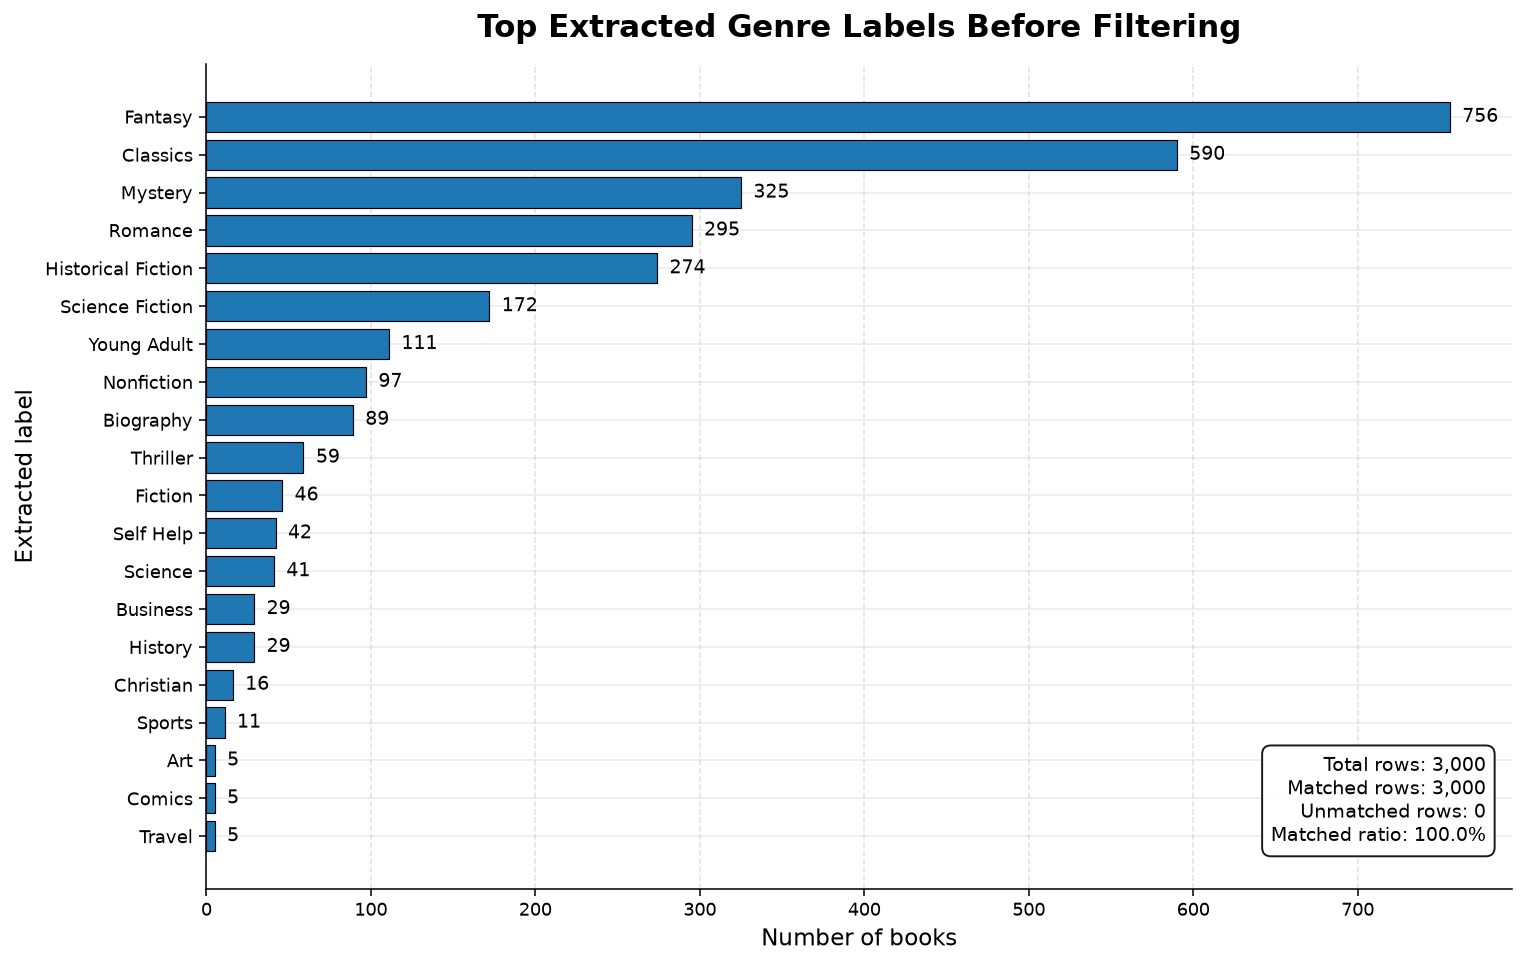

In [9]:
TARGET_GENRES = [
    "Fantasy",
    "Romance",
    "Mystery",
    "Thriller",
    "Science Fiction",
    "Historical Fiction",
    "Young Adult",
    "Classics",
    "Fiction",
    "Nonfiction",
    "History",
    "Biography",
    "Memoir",
    "Horror",
    "Children's",
    "Science",
    "Business",
    "Psychology",
    "Self Help",
    "Poetry",
    "Graphic Novels",
    "Comics",
    "Travel",
    "Sports",
    "Christian",
    "Cookbooks",
    "Music",
    "Art",
]
from collections import Counter
import matplotlib.pyplot as plt

TARGET_GENRE_SET = set(TARGET_GENRES)
# Create priority mapping: lower index means higher priority based on the list order
GENRE_PRIORITY = {genre: idx for idx, genre in enumerate(TARGET_GENRES)}


def split_genres(genres_value):
    # Split one raw genre cell into cleaned genre tokens.
    if genres_value is None:
        return []

    text = str(genres_value).strip()
    if not text:
        return []

    return [g.strip().strip('"').strip("'") for g in text.split(",") if g.strip()]


def choose_main_genre(genres_value):
    # Convert a multi-genre row into one supervised label.
    genres = split_genres(genres_value)
    candidates = [g for g in genres if g in TARGET_GENRE_SET]

    if not candidates:
        return None

    # Count frequencies of valid target genres in this row
    counts = Counter(candidates)
    
    # Sort by frequency (descending) and break ties with priority index (ascending)
    return sorted(counts.keys(), key=lambda g: (-counts[g], GENRE_PRIORITY[g]))[0]


# Apply the classification logic to generate our target labels
df["label"] = df[GENRES_COLUMN].apply(choose_main_genre)


# =========================
# Visualize extracted labels
# =========================

label_counts = (
    df["label"]
    .fillna("No selected target genre")
    .value_counts()
    .head(20)
    .sort_values()
)

total_rows = len(df)
matched_rows = df["label"].notna().sum()
unmatched_rows = df["label"].isna().sum()

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    label_counts.index,
    label_counts.values,
    edgecolor="black",
    linewidth=0.6,
)

ax.set_title(
    "Top Extracted Genre Labels Before Filtering",
    fontsize=16,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Number of books", fontsize=12)
ax.set_ylabel("Extracted label", fontsize=12)

ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

max_count = label_counts.max()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max_count * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=10,
    )

summary_text = (
    f"Total rows: {total_rows:,}\n"
    f"Matched rows: {matched_rows:,}\n"
    f"Unmatched rows: {unmatched_rows:,}\n"
    f"Matched ratio: {matched_rows / total_rows:.1%}"
)

ax.text(
    0.98,
    0.05,
    summary_text,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="white",
        edgecolor="black",
        alpha=0.9,
    ),
)

plt.tight_layout()
plt.show()

## 5. Clean rows and keep common classes

Keep rows with a usable description, a usable embedding, and one of the selected labels.

In [10]:
import ast

df[DESCRIPTION_COLUMN] = df[DESCRIPTION_COLUMN].fillna("").astype(str)


df[EMBEDDING_COLUMN] = df[EMBEDDING_COLUMN].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df_model = df[df["label"].notna()].copy()

genre_counts = df_model["label"].value_counts()

eligible_genres = genre_counts[genre_counts >= MIN_SAMPLES_PER_CLASS]

if len(eligible_genres) < 2:
    print(
        "MIN_SAMPLES_PER_CLASS is too strict. Falling back to classes with at least 5 examples."
    )
    eligible_genres = genre_counts[genre_counts >= 5].head(TOP_N_CLASSES)

selected_genres = eligible_genres.head(TOP_N_CLASSES).index.tolist()

df_model = df_model[df_model["label"].isin(selected_genres)].copy()
df_model = df_model.reset_index(drop=True)

if df_model["label"].nunique() < 2:
    raise ValueError(
        "Need at least two classes after filtering. Lower MIN_SAMPLES_PER_CLASS or TOP_N_CLASSES."
    )

print("Selected genres:")
print(selected_genres)
print()
print("Final dataset shape:", df_model.shape)

class_counts = df_model["label"].value_counts()
class_summary = pd.DataFrame(
    {
        "count": class_counts,
        "proportion": class_counts / class_counts.sum(),
    }
)

display(class_summary)

Selected genres:
['Fantasy', 'Classics', 'Mystery', 'Romance', 'Historical Fiction', 'Science Fiction', 'Young Adult']

Final dataset shape: (2523, 26)


,count,proportion
label,,
Fantasy,756,0.299643
Classics,590,0.233849
Mystery,325,0.128815
Romance,295,0.116924
Historical Fiction,274,0.108601
Science Fiction,172,0.068173
Young Adult,111,0.043995


### Class distribution after filtering


classes who are rare may need special attention during evaluation.

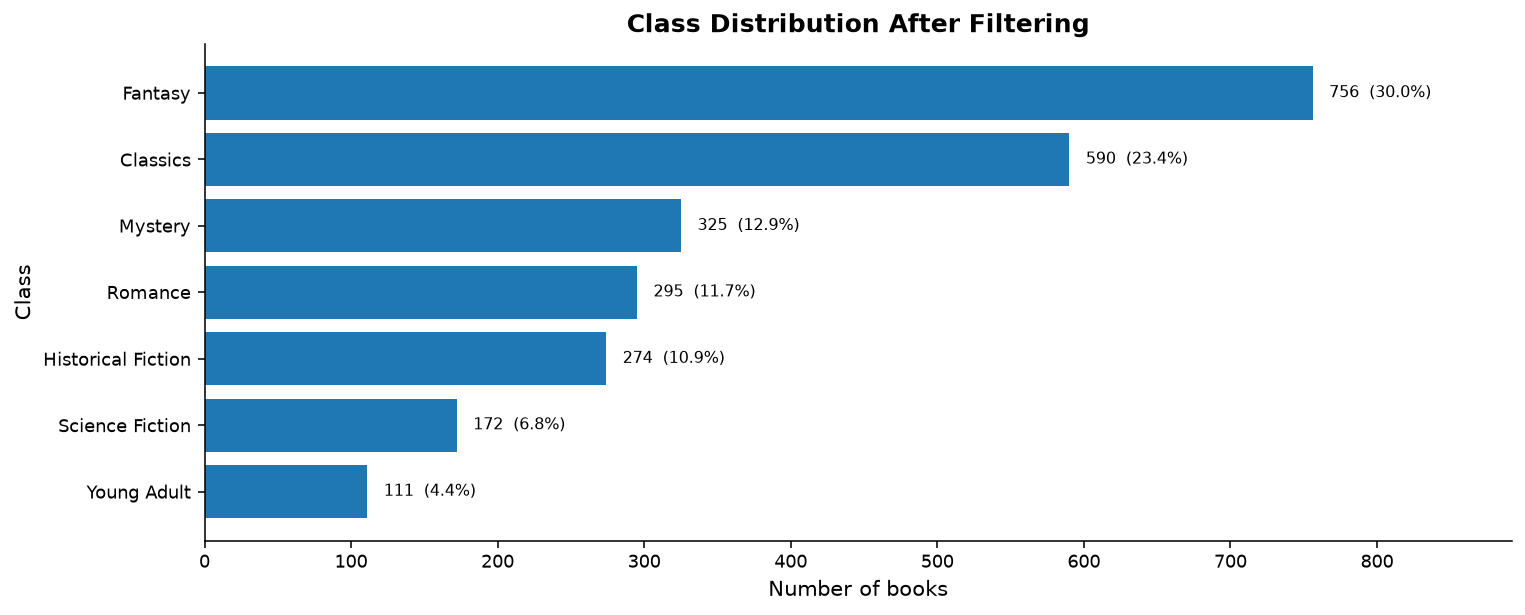

In [11]:
plot_horizontal_count_distribution(
    df_model["label"].value_counts(),
    title="Class Distribution After Filtering",
    xlabel="Number of books",
)

In [12]:
import ast
import json
import numpy as np


def parse_embedding(value):
    # Each cell should contain a JSON-style list of floats, e.g. "[0.1, -0.2, ...]".
    text = str(value).strip()

    if not text:
        return None

    try:
        parsed = json.loads(text)
    except json.JSONDecodeError:
        try:
            parsed = ast.literal_eval(text)
        except (ValueError, SyntaxError):
            return None

    arr = np.asarray(parsed, dtype=np.float32)

    if arr.ndim != 1 or arr.size == 0:
        return None

    return arr


# Parse all embedding column entries into individual arrays
parsed_embeddings = df_model[EMBEDDING_COLUMN].apply(parse_embedding)

# Create a boolean mask identifying rows that successfully turned into valid arrays
valid_embedding_mask = parsed_embeddings.apply(lambda x: x is not None)

if not valid_embedding_mask.all():
    print(
        "Dropping rows with invalid embeddings:",
        int((~valid_embedding_mask).sum()),
    )
    df_model = df_model[valid_embedding_mask].reset_index(drop=True)
    parsed_embeddings = parsed_embeddings[valid_embedding_mask].reset_index(
        drop=True
    )

# Stack the series of 1D arrays into a single unified 2D matrix (samples x dimensions)
embedding_matrix = np.vstack(parsed_embeddings.tolist())

print("Embedding matrix shape:", embedding_matrix.shape)

Dropping rows with invalid embeddings: 58
Embedding matrix shape: (2465, 1024)



## 6. Scratch implementations

Read these classes before running the experiments. These are the implementations that must be used throughout the notebook.

The goal is not to beat mature libraries. The goal is to make each method transparent enough to inspect, modify, and debug.


In [13]:

# ============================================================
# Utility helpers
# ============================================================

def as_1d_int_array(values):
    return np.asarray(values, dtype=int).ravel()


def stable_softmax(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)


def one_hot(y, n_classes):
    y = as_1d_int_array(y)
    Y = np.zeros((len(y), n_classes), dtype=np.float32)
    Y[np.arange(len(y)), y] = 1.0
    return Y


def safe_sparse_to_dense(X):
    if sparse.issparse(X):
        return X.toarray()
    return np.asarray(X)


def l2_normalize_rows(X, eps=1e-12):
    if sparse.issparse(X):
        row_norms = np.sqrt(np.asarray(X.multiply(X).sum(axis=1)).ravel())
        row_norms[row_norms < eps] = 1.0
        return X.multiply(1.0 / row_norms[:, None]).tocsr()

    X = np.asarray(X, dtype=np.float32)
    row_norms = np.linalg.norm(X, axis=1, keepdims=True)
    row_norms[row_norms < eps] = 1.0
    return X / row_norms


# ============================================================
# Label encoding and stratified splitting
# ============================================================

class ScratchLabelEncoder:
    def fit(self, labels):
        self.classes_ = np.array(sorted(pd.Series(labels).astype(str).unique()))
        self.class_to_id_ = {label: i for i, label in enumerate(self.classes_)}
        return self

    def transform(self, labels):
        return np.array([self.class_to_id_[str(label)] for label in labels], dtype=int)

    def fit_transform(self, labels):
        return self.fit(labels).transform(labels)

    def inverse_transform(self, ids):
        ids = as_1d_int_array(ids)
        return self.classes_[ids]


def stratified_train_dev_test_split(y, train_size=0.70, dev_size=0.15, test_size=0.15, random_state=42):
    # Preserve the class distribution in train/dev/test.
    y = as_1d_int_array(y)
    rng = np.random.default_rng(random_state)

    if not np.isclose(train_size + dev_size + test_size, 1.0):
        raise ValueError("train_size + dev_size + test_size must equal 1.")

    train_idx, dev_idx, test_idx = [], [], []

    for class_id in np.unique(y):
        class_indices = np.where(y == class_id)[0]
        rng.shuffle(class_indices)
        n = len(class_indices)

        n_train = int(np.floor(n * train_size))
        n_dev = int(np.floor(n * dev_size))
        n_test = n - n_train - n_dev

        if n >= 3:
            if n_dev == 0:
                n_dev = 1
                n_train = max(1, n_train - 1)
            if n_test == 0:
                n_test = 1
                n_train = max(1, n_train - 1)

        train_idx.extend(class_indices[:n_train])
        dev_idx.extend(class_indices[n_train:n_train + n_dev])
        test_idx.extend(class_indices[n_train + n_dev:])

    train_idx = np.array(train_idx, dtype=int)
    dev_idx = np.array(dev_idx, dtype=int)
    test_idx = np.array(test_idx, dtype=int)

    rng.shuffle(train_idx)
    rng.shuffle(dev_idx)
    rng.shuffle(test_idx)

    return train_idx, dev_idx, test_idx


# ============================================================
# TF-IDF from scratch
# ============================================================

class ScratchTfidfVectorizer:
    def __init__(
        self,
        lowercase=True,
        ngram_range=(1, 1),
        min_df=1,
        max_df=1.0,
        max_features=None,
        sublinear_tf=True,
        norm="l2",
    ):
        self.lowercase = lowercase
        self.ngram_range = ngram_range
        self.min_df = min_df
        self.max_df = max_df
        self.max_features = max_features
        self.sublinear_tf = sublinear_tf
        self.norm = norm
        self.token_pattern = re.compile(r"(?u)\b\w\w+\b")

    def _tokens(self, text):
        text = "" if text is None else str(text)
        if self.lowercase:
            text = text.lower()
        return self.token_pattern.findall(text)

    def _analyze(self, text):
        tokens = self._tokens(text)
        min_n, max_n = self.ngram_range

        terms = []
        for n in range(min_n, max_n + 1):
            if len(tokens) >= n:
                terms.extend([" ".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)])
        return terms

    def fit(self, documents):
        documents = list(documents)
        n_docs = len(documents)

        df_counter = Counter()
        tf_counter = Counter()

        for doc in tqdm(documents, desc="Fitting scratch TF-IDF"):
            terms = self._analyze(doc)
            tf_counter.update(terms)
            df_counter.update(set(terms))

        min_df_abs = self.min_df if isinstance(self.min_df, int) else int(math.ceil(self.min_df * n_docs))
        max_df_abs = self.max_df if isinstance(self.max_df, int) else int(math.floor(self.max_df * n_docs))

        candidate_terms = [
            term for term, df in df_counter.items()
            if df >= min_df_abs and df <= max_df_abs
        ]

        candidate_terms = sorted(candidate_terms, key=lambda term: (-tf_counter[term], term))
        if self.max_features is not None:
            candidate_terms = candidate_terms[:self.max_features]

        self.vocabulary_ = {term: i for i, term in enumerate(candidate_terms)}
        self.feature_names_ = np.array(candidate_terms, dtype=object)

        dfs = np.array([df_counter[term] for term in candidate_terms], dtype=np.float64)
        self.idf_ = np.log((1.0 + n_docs) / (1.0 + dfs)) + 1.0
        return self

    def transform(self, documents):
        if not hasattr(self, "vocabulary_"):
            raise ValueError("Vectorizer must be fitted before transform.")

        documents = list(documents)
        rows, cols, data = [], [], []

        for row_id, doc in enumerate(tqdm(documents, desc="Transforming with scratch TF-IDF")):
            counts = Counter(term for term in self._analyze(doc) if term in self.vocabulary_)

            for term, count in counts.items():
                col_id = self.vocabulary_[term]
                tf = 1.0 + math.log(count) if self.sublinear_tf else float(count)
                rows.append(row_id)
                cols.append(col_id)
                data.append(tf * self.idf_[col_id])

        X = sparse.csr_matrix(
            (data, (rows, cols)),
            shape=(len(documents), len(self.vocabulary_)),
            dtype=np.float32,
        )

        if self.norm == "l2":
            X = l2_normalize_rows(X)

        return X

    def fit_transform(self, documents):
        return self.fit(documents).transform(documents)

    def get_feature_names_out(self):
        return self.feature_names_


def select_top_sparse_columns_by_variance(X, max_features):
    # Convert only a selected subset of sparse TF-IDF features to dense form for the MLP.
    if not sparse.issparse(X):
        X = sparse.csr_matrix(X)

    n_features = X.shape[1]
    keep = min(max_features, n_features)

    mean = np.asarray(X.mean(axis=0)).ravel()
    mean_sq = np.asarray(X.power(2).mean(axis=0)).ravel()
    variance = mean_sq - mean ** 2

    selected = np.argsort(variance)[-keep:]
    selected = np.sort(selected)

    return selected


# ============================================================
# Scaling from scratch
# ============================================================

class ScratchStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps

    def fit(self, X):
        X = np.asarray(X, dtype=np.float32)
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ < self.eps] = 1.0
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class ScratchScaledClassifier:
    def __init__(self, estimator):
        self.estimator = estimator
        self.scaler = ScratchStandardScaler()

    def fit(self, X, y):
        X_scaled = self.scaler.fit_transform(safe_sparse_to_dense(X))
        self.estimator.fit(X_scaled, y)
        return self

    def predict(self, X):
        X_scaled = self.scaler.transform(safe_sparse_to_dense(X))
        return self.estimator.predict(X_scaled)


# ============================================================
# Metrics from scratch
# ============================================================

def scratch_confusion_matrix(y_true, y_pred, labels=None, normalize=None):
    y_true = as_1d_int_array(y_true)
    y_pred = as_1d_int_array(y_pred)

    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
    labels = as_1d_int_array(labels)

    label_to_position = {label: i for i, label in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=np.float64)

    for true_label, pred_label in zip(y_true, y_pred):
        if true_label in label_to_position and pred_label in label_to_position:
            cm[label_to_position[true_label], label_to_position[pred_label]] += 1

    if normalize == "true":
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm = cm / row_sums

    return cm


def per_class_metrics(y_true, y_pred, labels):
    cm = scratch_confusion_matrix(y_true, y_pred, labels=labels)
    rows = []

    for i, label in enumerate(labels):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        support = cm[i, :].sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        rows.append({
            "label": label,
            "precision": precision,
            "recall": recall,
            "f1-score": f1,
            "support": support,
        })

    return pd.DataFrame(rows)


def compute_metrics(y_true, y_pred):
    y_true = as_1d_int_array(y_true)
    y_pred = as_1d_int_array(y_pred)
    labels = np.unique(np.concatenate([y_true, y_pred]))

    class_df = per_class_metrics(y_true, y_pred, labels)
    accuracy = float(np.mean(y_true == y_pred))

    cm = scratch_confusion_matrix(y_true, y_pred, labels=labels)
    total_tp = float(np.trace(cm))
    total_fp = float(cm.sum(axis=0).sum() - total_tp)
    total_fn = float(cm.sum(axis=1).sum() - total_tp)

    micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    micro_f1 = (
        2 * micro_precision * micro_recall / (micro_precision + micro_recall)
        if (micro_precision + micro_recall) > 0
        else 0.0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": float(class_df["precision"].mean()),
        "macro_recall": float(class_df["recall"].mean()),
        "macro_f1": float(class_df["f1-score"].mean()),
        "micro_precision": float(micro_precision),
        "micro_recall": float(micro_recall),
        "micro_f1": float(micro_f1),
    }


def classification_report_scratch(y_true, y_pred, target_names, digits=3, output_dict=False):
    labels = np.arange(len(target_names))
    class_df = per_class_metrics(y_true, y_pred, labels=labels)
    class_df["class_name"] = target_names

    metrics = compute_metrics(y_true, y_pred)
    accuracy = metrics["accuracy"]

    if output_dict:
        report = {}
        for _, row in class_df.iterrows():
            report[row["class_name"]] = {
                "precision": float(row["precision"]),
                "recall": float(row["recall"]),
                "f1-score": float(row["f1-score"]),
                "support": float(row["support"]),
            }

        report["accuracy"] = accuracy
        report["macro avg"] = {
            "precision": metrics["macro_precision"],
            "recall": metrics["macro_recall"],
            "f1-score": metrics["macro_f1"],
            "support": float(len(y_true)),
        }
        report["micro avg"] = {
            "precision": metrics["micro_precision"],
            "recall": metrics["micro_recall"],
            "f1-score": metrics["micro_f1"],
            "support": float(len(y_true)),
        }
        return report

    name_width = max(12, max(len(str(name)) for name in target_names) + 2)
    header = f"{'':>{name_width}} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}"
    lines = [header]

    for _, row in class_df.iterrows():
        lines.append(
            f"{row['class_name']:>{name_width}} "
            f"{row['precision']:>10.{digits}f} "
            f"{row['recall']:>10.{digits}f} "
            f"{row['f1-score']:>10.{digits}f} "
            f"{int(row['support']):>10d}"
        )

    lines.append("")
    lines.append(f"{'accuracy':>{name_width}} {'':>10} {'':>10} {accuracy:>10.{digits}f} {len(y_true):>10d}")
    lines.append(
        f"{'macro avg':>{name_width}} "
        f"{metrics['macro_precision']:>10.{digits}f} "
        f"{metrics['macro_recall']:>10.{digits}f} "
        f"{metrics['macro_f1']:>10.{digits}f} "
        f"{len(y_true):>10d}"
    )
    lines.append(
        f"{'micro avg':>{name_width}} "
        f"{metrics['micro_precision']:>10.{digits}f} "
        f"{metrics['micro_recall']:>10.{digits}f} "
        f"{metrics['micro_f1']:>10.{digits}f} "
        f"{len(y_true):>10d}"
    )

    return "\n".join(lines)


# ============================================================
# Classifiers from scratch
# ============================================================

class ScratchMultinomialNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        y = as_1d_int_array(y)
        X = X.tocsr() if sparse.issparse(X) else sparse.csr_matrix(X)

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_features = X.shape[1]

        class_count = np.zeros(n_classes, dtype=np.float64)
        feature_count = np.zeros((n_classes, n_features), dtype=np.float64)

        for i, class_id in enumerate(self.classes_):
            mask = y == class_id
            class_count[i] = mask.sum()
            feature_count[i, :] = np.asarray(X[mask].sum(axis=0)).ravel()

        smoothed_fc = feature_count + self.alpha
        smoothed_cc = smoothed_fc.sum(axis=1, keepdims=True)

        self.class_log_prior_ = np.log(class_count / class_count.sum())
        self.feature_log_prob_ = np.log(smoothed_fc / smoothed_cc)
        self.coef_ = self.feature_log_prob_
        return self

    def predict(self, X):
        X = X.tocsr() if sparse.issparse(X) else sparse.csr_matrix(X)
        scores = X @ self.feature_log_prob_.T + self.class_log_prior_
        return self.classes_[np.asarray(scores).argmax(axis=1)]


class ScratchGaussianNB:
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        X = safe_sparse_to_dense(X).astype(np.float32)
        y = as_1d_int_array(y)

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_features = X.shape[1]

        self.theta_ = np.zeros((n_classes, n_features), dtype=np.float32)
        self.var_ = np.zeros((n_classes, n_features), dtype=np.float32)
        self.class_prior_ = np.zeros(n_classes, dtype=np.float32)

        global_var = np.var(X, axis=0).max()
        eps = self.var_smoothing * global_var if global_var > 0 else self.var_smoothing

        for i, class_id in enumerate(self.classes_):
            X_c = X[y == class_id]
            self.theta_[i] = X_c.mean(axis=0)
            self.var_[i] = X_c.var(axis=0) + eps
            self.class_prior_[i] = len(X_c) / len(X)

        return self

    def predict(self, X):
        X = safe_sparse_to_dense(X).astype(np.float32)
        log_priors = np.log(self.class_prior_ + 1e-12)

        preds = []
        batch_size = 512

        for start in range(0, X.shape[0], batch_size):
            Xb = X[start:start + batch_size]
            log_prob = -0.5 * (
                np.log(2.0 * np.pi * self.var_[None, :, :])
                + ((Xb[:, None, :] - self.theta_[None, :, :]) ** 2) / self.var_[None, :, :]
            )
            scores = log_prob.sum(axis=2) + log_priors
            preds.extend(self.classes_[np.argmax(scores, axis=1)])

        return np.asarray(preds, dtype=int)


class ScratchKNNClassifier:
    def __init__(self, n_neighbors=5, metric="cosine", batch_size=256):
        self.n_neighbors = n_neighbors
        self.metric = metric
        self.batch_size = batch_size

    def fit(self, X, y):
        self.y_train_ = as_1d_int_array(y)
        self.classes_ = np.unique(self.y_train_)

        if self.metric != "cosine":
            raise ValueError("This assignment implementation supports cosine kNN.")

        self.X_train_ = l2_normalize_rows(X)
        return self

    def predict(self, X):
        X_eval = l2_normalize_rows(X)
        preds = []

        for start in range(0, X_eval.shape[0], self.batch_size):
            Xb = X_eval[start:start + self.batch_size]

            sims = Xb @ self.X_train_.T
            if sparse.issparse(sims):
                sims = sims.toarray()
            else:
                sims = np.asarray(sims)

            k = min(self.n_neighbors, sims.shape[1])
            neighbor_idx = np.argpartition(-sims, kth=k-1, axis=1)[:, :k]

            for row_neighbors in neighbor_idx:
                neighbor_labels = self.y_train_[row_neighbors]
                counts = np.bincount(neighbor_labels, minlength=int(self.classes_.max()) + 1)
                preds.append(np.argmax(counts))

        return np.asarray(preds, dtype=int)


class ScratchSoftmaxLogisticRegression:
    def __init__(
        self,
        learning_rate=0.5,
        max_epochs=60,
        batch_size=512,
        alpha=1e-4,
        random_state=42,
        verbose=False,
    ):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.alpha = alpha
        self.random_state = random_state
        self.verbose = verbose

    def fit(self, X, y):
        y = as_1d_int_array(y)
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_samples, n_features = X.shape

        rng = np.random.default_rng(self.random_state)
        self.W_ = rng.normal(0, 0.01, size=(n_features, n_classes)).astype(np.float32)
        self.b_ = np.zeros(n_classes, dtype=np.float32)
        self.loss_history_ = []

        indices = np.arange(n_samples)

        for epoch in range(self.max_epochs):
            rng.shuffle(indices)

            for start in range(0, n_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                Xb = X[batch_idx]
                yb = y[batch_idx]

                logits = Xb @ self.W_ + self.b_
                logits = np.asarray(logits)
                probs = stable_softmax(logits)

                Yb = one_hot(yb, n_classes)
                error = (probs - Yb) / len(yb)

                if sparse.issparse(Xb):
                    grad_W = Xb.T @ error
                    grad_W = np.asarray(grad_W)
                else:
                    grad_W = Xb.T @ error

                grad_W += self.alpha * self.W_
                grad_b = error.sum(axis=0)

                self.W_ -= self.learning_rate * grad_W
                self.b_ -= self.learning_rate * grad_b

            if self.verbose or epoch == self.max_epochs - 1:
                loss = self._loss(X, y)
                self.loss_history_.append(loss)
                if self.verbose and (epoch % 10 == 0 or epoch == self.max_epochs - 1):
                    print(f"epoch={epoch + 1:03d}, loss={loss:.4f}")

        self.coef_ = self.W_.T
        self.intercept_ = self.b_
        return self

    def _loss(self, X, y):
        y = as_1d_int_array(y)
        logits = np.asarray(X @ self.W_ + self.b_)
        probs = stable_softmax(logits)
        n = len(y)
        ce = -np.log(probs[np.arange(n), y] + 1e-12).mean()
        reg = 0.5 * self.alpha * np.sum(self.W_ ** 2)
        return float(ce + reg)

    def predict_proba(self, X):
        logits = np.asarray(X @ self.W_ + self.b_)
        return stable_softmax(logits)

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]


class ScratchMLPClassifier:
    def __init__(
        self,
        hidden_dim=128,
        learning_rate=1e-3,
        max_epochs=35,
        batch_size=128,
        alpha=1e-4,
        random_state=42,
        verbose=False,
    ):
        self.hidden_dim = hidden_dim
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.alpha = alpha
        self.random_state = random_state
        self.verbose = verbose

    def fit(self, X, y):
        X = safe_sparse_to_dense(X).astype(np.float32)
        y = as_1d_int_array(y)

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_samples, n_features = X.shape

        rng = np.random.default_rng(self.random_state)

        self.W1_ = rng.normal(0, np.sqrt(2.0 / n_features), size=(n_features, self.hidden_dim)).astype(np.float32)
        self.b1_ = np.zeros(self.hidden_dim, dtype=np.float32)
        self.W2_ = rng.normal(0, np.sqrt(2.0 / self.hidden_dim), size=(self.hidden_dim, n_classes)).astype(np.float32)
        self.b2_ = np.zeros(n_classes, dtype=np.float32)

        self.loss_history_ = []
        indices = np.arange(n_samples)

        for epoch in range(self.max_epochs):
            rng.shuffle(indices)

            for start in range(0, n_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                Xb = X[batch_idx]
                yb = y[batch_idx]

                Z1 = Xb @ self.W1_ + self.b1_
                A1 = np.maximum(0, Z1)
                logits = A1 @ self.W2_ + self.b2_
                probs = stable_softmax(logits)

                Yb = one_hot(yb, n_classes)
                dlogits = (probs - Yb) / len(yb)

                dW2 = A1.T @ dlogits + self.alpha * self.W2_
                db2 = dlogits.sum(axis=0)

                dA1 = dlogits @ self.W2_.T
                dZ1 = dA1 * (Z1 > 0)

                dW1 = Xb.T @ dZ1 + self.alpha * self.W1_
                db1 = dZ1.sum(axis=0)

                self.W1_ -= self.learning_rate * dW1
                self.b1_ -= self.learning_rate * db1
                self.W2_ -= self.learning_rate * dW2
                self.b2_ -= self.learning_rate * db2

            if self.verbose or epoch == self.max_epochs - 1:
                loss = self._loss(X, y)
                self.loss_history_.append(loss)
                if self.verbose and (epoch % 10 == 0 or epoch == self.max_epochs - 1):
                    print(f"epoch={epoch + 1:03d}, loss={loss:.4f}")

        return self

    def _loss(self, X, y):
        probs = self.predict_proba(X)
        ce = -np.log(probs[np.arange(len(y)), y] + 1e-12).mean()
        reg = 0.5 * self.alpha * (np.sum(self.W1_ ** 2) + np.sum(self.W2_ ** 2))
        return float(ce + reg)

    def predict_proba(self, X):
        X = safe_sparse_to_dense(X).astype(np.float32)
        Z1 = X @ self.W1_ + self.b1_
        A1 = np.maximum(0, Z1)
        logits = A1 @ self.W2_ + self.b2_
        return stable_softmax(logits)

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]


## 7. Encode labels and visualize sentence embeddings

Use PCA only for visualization.


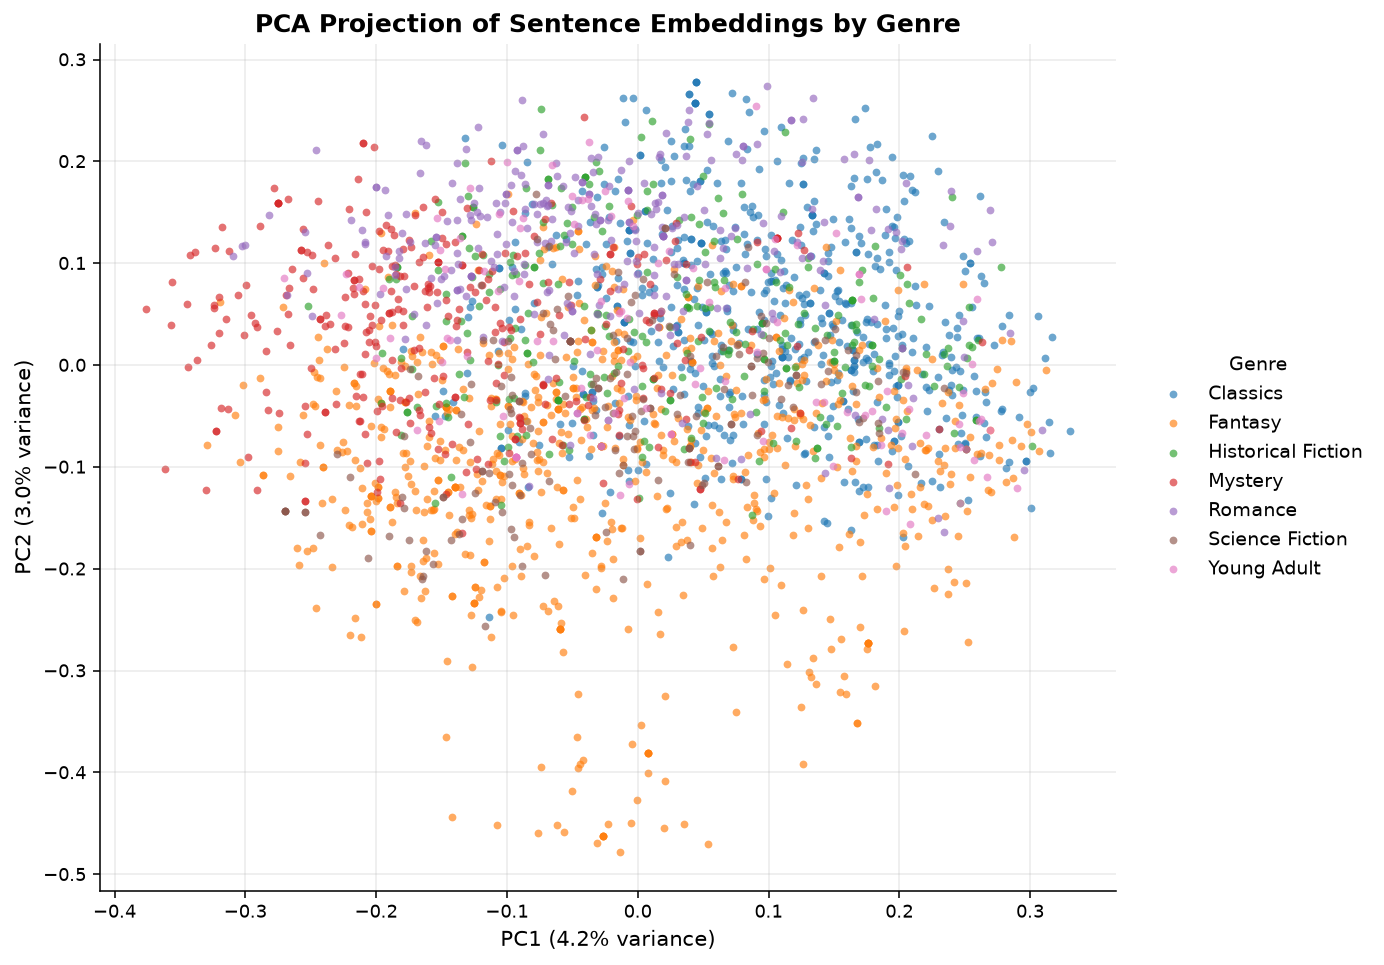

In [14]:
label_encoder = ScratchLabelEncoder()
y_all = label_encoder.fit_transform(df_model["label"])
class_names = label_encoder.classes_
plot_pca_projection(
    embedding_matrix,
    y_all,
    class_names,
    title="PCA Projection of Sentence Embeddings by Genre",
    max_points=MAX_POINTS_FOR_PCA_PLOT,
    random_state=RANDOM_STATE,
)

## 8. Create train/dev/test splits

Split the dataset into train, development, and test sets. Preserve the label distribution using stratified splits.

In [15]:
train_idx, dev_idx, test_idx = stratified_train_dev_test_split(
    y_all,
    train_size=TRAIN_SIZE,
    dev_size=DEV_SIZE,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

y_train = y_all[train_idx]
y_dev = y_all[dev_idx]
y_test = y_all[test_idx]

print("Train size:", len(train_idx))
print("Dev size:", len(dev_idx))
print("Test size:", len(test_idx))
print("Classes:", class_names.tolist())

Train size: 1722
Dev size: 367
Test size: 376
Classes: ['Classics', 'Fantasy', 'Historical Fiction', 'Mystery', 'Romance', 'Science Fiction', 'Young Adult']


### Split distributions

Check that the stratified split preserved the class proportions.

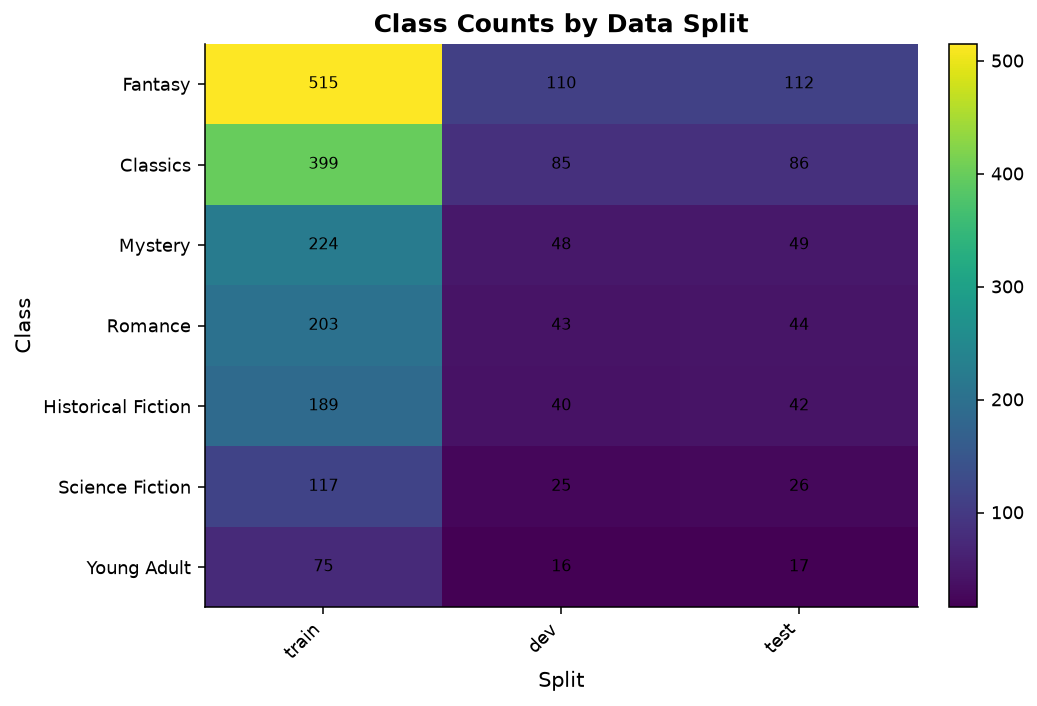

,train,dev,test
Fantasy,515,110,112
Classics,399,85,86
Mystery,224,48,49
Romance,203,43,44
Historical Fiction,189,40,42
Science Fiction,117,25,26
Young Adult,75,16,17


In [16]:
split_distribution_df = pd.DataFrame({
    "train": pd.Series(label_encoder.inverse_transform(y_train)).value_counts(),
    "dev": pd.Series(label_encoder.inverse_transform(y_dev)).value_counts(),
    "test": pd.Series(label_encoder.inverse_transform(y_test)).value_counts(),
}).fillna(0).astype(int)

plot_metric_heatmap(
    split_distribution_df,
    title="Class Counts by Data Split",
    xlabel="Split",
    ylabel="Class",
    value_format=".0f",
)

display(split_distribution_df)

**TODO:** Are the train/dev/test distributions similar enough? Why does this matter?

## 9. Build TF-IDF features

Fit the scratch TF-IDF vectorizer only on the training descriptions. Transform the development and test descriptions with the same fitted vocabulary and IDF values.

In [17]:
train_texts = df_model[DESCRIPTION_COLUMN].iloc[train_idx].tolist()
dev_texts = df_model[DESCRIPTION_COLUMN].iloc[dev_idx].tolist()
test_texts = df_model[DESCRIPTION_COLUMN].iloc[test_idx].tolist()

tfidf_vectorizer = ScratchTfidfVectorizer(
    lowercase=True,
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF,
    max_df=MAX_DF,
    max_features=MAX_TFIDF_FEATURES,
    sublinear_tf=True,
    norm="l2",
)

# Fit the scratch vectorizer on training text and project all splits into the sparse TF-IDF space
X_tfidf_train = tfidf_vectorizer.fit_transform(train_texts)
X_tfidf_dev = tfidf_vectorizer.transform(dev_texts)
X_tfidf_test = tfidf_vectorizer.transform(test_texts)

# Slice the dense 2D embedding matrix using the matching split indices
X_emb_train = embedding_matrix[train_idx]
X_emb_dev = embedding_matrix[dev_idx]
X_emb_test = embedding_matrix[test_idx]

print("TF-IDF train shape:", X_tfidf_train.shape)
print("Sentence embedding train shape:", X_emb_train.shape)

Fitting scratch TF-IDF:   0%|          | 0/1722 [00:00<?, ?it/s]

Transforming with scratch TF-IDF:   0%|          | 0/1722 [00:00<?, ?it/s]

Transforming with scratch TF-IDF:   0%|          | 0/367 [00:00<?, ?it/s]

Transforming with scratch TF-IDF:   0%|          | 0/376 [00:00<?, ?it/s]

TF-IDF train shape: (1722, 10000)
Sentence embedding train shape: (1722, 1024)


## 10. Evaluation utilities

Use macro-F1 as the main selection metric because the dataset is imbalanced.

In [18]:
import time


def fit_predict_and_score(model, X_train_current, y_train_current, X_eval_current, y_eval_current):
    start_time = time.time()
    model.fit(X_train_current, y_train_current)
    train_seconds = time.time() - start_time

    start_time = time.time()
    y_pred = model.predict(X_eval_current)
    predict_seconds = time.time() - start_time

    metrics = compute_metrics(y_eval_current, y_pred)
    return metrics, train_seconds, predict_seconds, y_pred

## 11. Handle class imbalance

Compare the baseline against several resampling strategies. Select the best strategy using development macro-F1, then use that selected strategy for all later models.

In [19]:
def make_resampled_indices(y, strategy, random_state=42):
    # Return row indices into the current training arrays after applying a resampling strategy.
    rng = np.random.default_rng(random_state)
    y = np.asarray(y)
    all_indices = np.arange(len(y))

    if strategy == "none":
        return all_indices

    counts = pd.Series(y).value_counts().sort_index()

    if strategy == "random_oversample":
        target_count = int(counts.max())
    elif strategy == "random_undersample":
        target_count = int(counts.min())
    elif strategy == "median_resample":
        target_count = int(np.median(counts.values))
    else:
        raise ValueError(f"Unknown imbalance strategy: {strategy}")

    selected_indices = []

    for class_id in counts.index:
        class_indices = all_indices[y == class_id]
        replace = len(class_indices) < target_count   # sample w/ replacement only when growing a class
        chosen = rng.choice(class_indices, size=target_count, replace=replace)
        selected_indices.extend(chosen.tolist())

    selected_indices = np.asarray(selected_indices)
    rng.shuffle(selected_indices)
    return selected_indices


def subset_rows(X, row_indices):
    # Works for both NumPy arrays and scipy sparse matrices.
    return X[row_indices]


strategy_distribution_rows = []

for strategy in IMBALANCE_STRATEGIES:
    selected_rows = make_resampled_indices(y_train, strategy)
    strategy_labels = np.asarray(class_names)[np.asarray(y_train)[selected_rows]]  # int -> name
    counts = pd.Series(strategy_labels).value_counts()

    for class_name in class_names:
        strategy_distribution_rows.append({
            "imbalance_strategy": strategy,
            "class": class_name,
            "count": int(counts.get(class_name, 0)),
        })

strategy_distribution_df = pd.DataFrame(strategy_distribution_rows)
strategy_distribution_matrix = (
    strategy_distribution_df
    .pivot(index="class", columns="imbalance_strategy", values="count")
    .loc[class_names, IMBALANCE_STRATEGIES]
)

display(strategy_distribution_matrix)

imbalance_strategy,none,random_oversample,random_undersample,median_resample
class,,,,
Classics,399,515,75,203
Fantasy,515,515,75,203
Historical Fiction,189,515,75,203
Mystery,224,515,75,203
Romance,203,515,75,203
Science Fiction,117,515,75,203
Young Adult,75,515,75,203


Use scratch softmax logistic regression as the strategy-selection model. It is fast enough for repeated trials and works with both sparse TF-IDF and dense sentence embeddings.

**TODO:** After running the strategy comparison, explain whether the selected strategy improves minority-class performance or mostly changes the score by changing the training distribution.

In [20]:
imbalance_results = []

for strategy in IMBALANCE_STRATEGIES:
    selected_rows = make_resampled_indices(
        y_train,
        strategy=strategy,
        random_state=RANDOM_STATE,
    )

    X_tfidf_train_strategy = subset_rows(X_tfidf_train, selected_rows)
    X_emb_train_strategy = subset_rows(X_emb_train, selected_rows)
    y_train_strategy = np.asarray(y_train)[selected_rows]

    candidates = [
        (
            "TF-IDF",
            ScratchSoftmaxLogisticRegression(
                learning_rate=LR_LEARNING_RATE,
                max_epochs=LR_IMBALANCE_EPOCHS,
                batch_size=LR_BATCH_SIZE,
                alpha=LR_ALPHA,
                random_state=RANDOM_STATE,
            ),
            X_tfidf_train_strategy,
            X_tfidf_dev,
        ),
        (
            "Sentence embedding",
            ScratchScaledClassifier(
                ScratchSoftmaxLogisticRegression(
                    learning_rate=LR_LEARNING_RATE,
                    max_epochs=LR_IMBALANCE_EPOCHS,
                    batch_size=LR_BATCH_SIZE,
                    alpha=LR_ALPHA,
                    random_state=RANDOM_STATE,
                )
            ),
            X_emb_train_strategy,
            X_emb_dev,
        ),
    ]

    for representation_name, model, X_train_current, X_dev_current in candidates:
        metrics, train_seconds, predict_seconds, _ = fit_predict_and_score(
            model,
            X_train_current,
            y_train_strategy,
            X_dev_current,
            y_dev,
        )

        imbalance_results.append({
            "imbalance_strategy": strategy,
            "representation": representation_name,
            "train_size_after_strategy": len(y_train_strategy),
            "dev_accuracy": metrics["accuracy"],
            "dev_macro_f1": metrics["macro_f1"],
            "dev_micro_f1": metrics["micro_f1"],
            "train_seconds": train_seconds,
            "dev_predict_seconds": predict_seconds,
        })

imbalance_results_df = pd.DataFrame(imbalance_results)
imbalance_results_df = imbalance_results_df.sort_values(
    ["dev_macro_f1", "dev_accuracy"],
    ascending=False,
).reset_index(drop=True)

display(imbalance_results_df)

,imbalance_strategy,representation,train_size_after_strategy,dev_accuracy,dev_macro_f1,dev_micro_f1,train_seconds,dev_predict_seconds
0,random_oversample,Sentence embedding,3605,0.705722,0.670442,0.705722,0.394147,0.000993
1,none,Sentence embedding,1722,0.713896,0.667136,0.713896,0.200601,0.000999
2,median_resample,Sentence embedding,1421,0.670300,0.633785,0.670300,0.171199,0.001183
3,random_undersample,Sentence embedding,525,0.561308,0.551111,0.561308,0.062985,0.001176
4,median_resample,TF-IDF,1421,0.536785,0.508515,0.536785,0.054730,0.000000
5,random_oversample,TF-IDF,3605,0.463215,0.468753,0.463215,0.139408,0.000000
6,random_undersample,TF-IDF,525,0.133515,0.141593,0.133515,0.024993,0.000000
7,none,TF-IDF,1722,0.302452,0.069349,0.302452,0.072017,0.000995


### Imbalance strategy performance

Compare the strategies using development metrics.

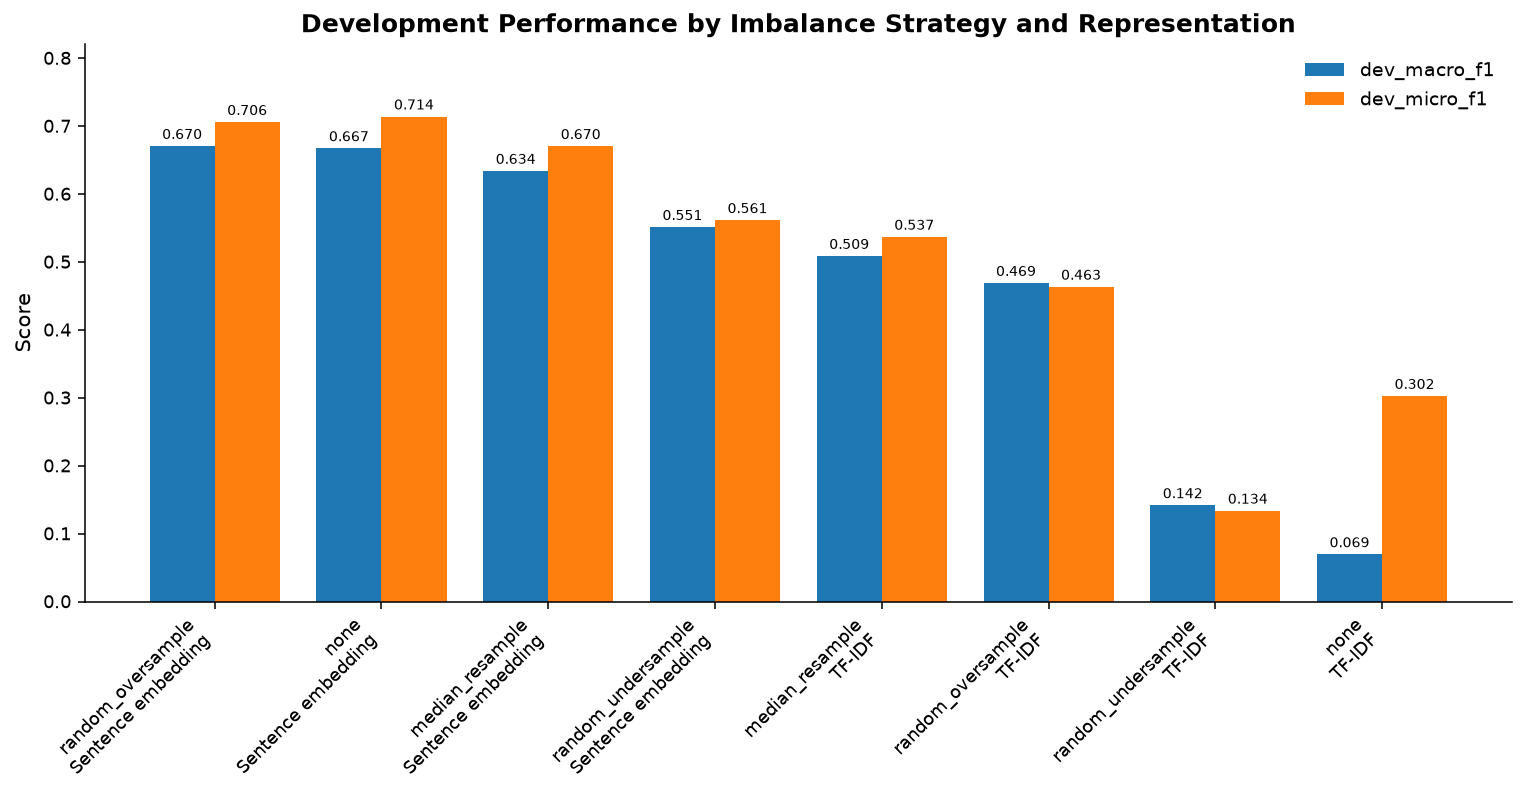

,imbalance_strategy,mean_dev_macro_f1,mean_dev_micro_f1,mean_dev_accuracy,mean_train_size
0,median_resample,0.571150,0.603542,0.603542,1421.0
1,random_oversample,0.569598,0.584469,0.584469,3605.0
2,none,0.368242,0.508174,0.508174,1722.0
3,random_undersample,0.346352,0.347411,0.347411,525.0


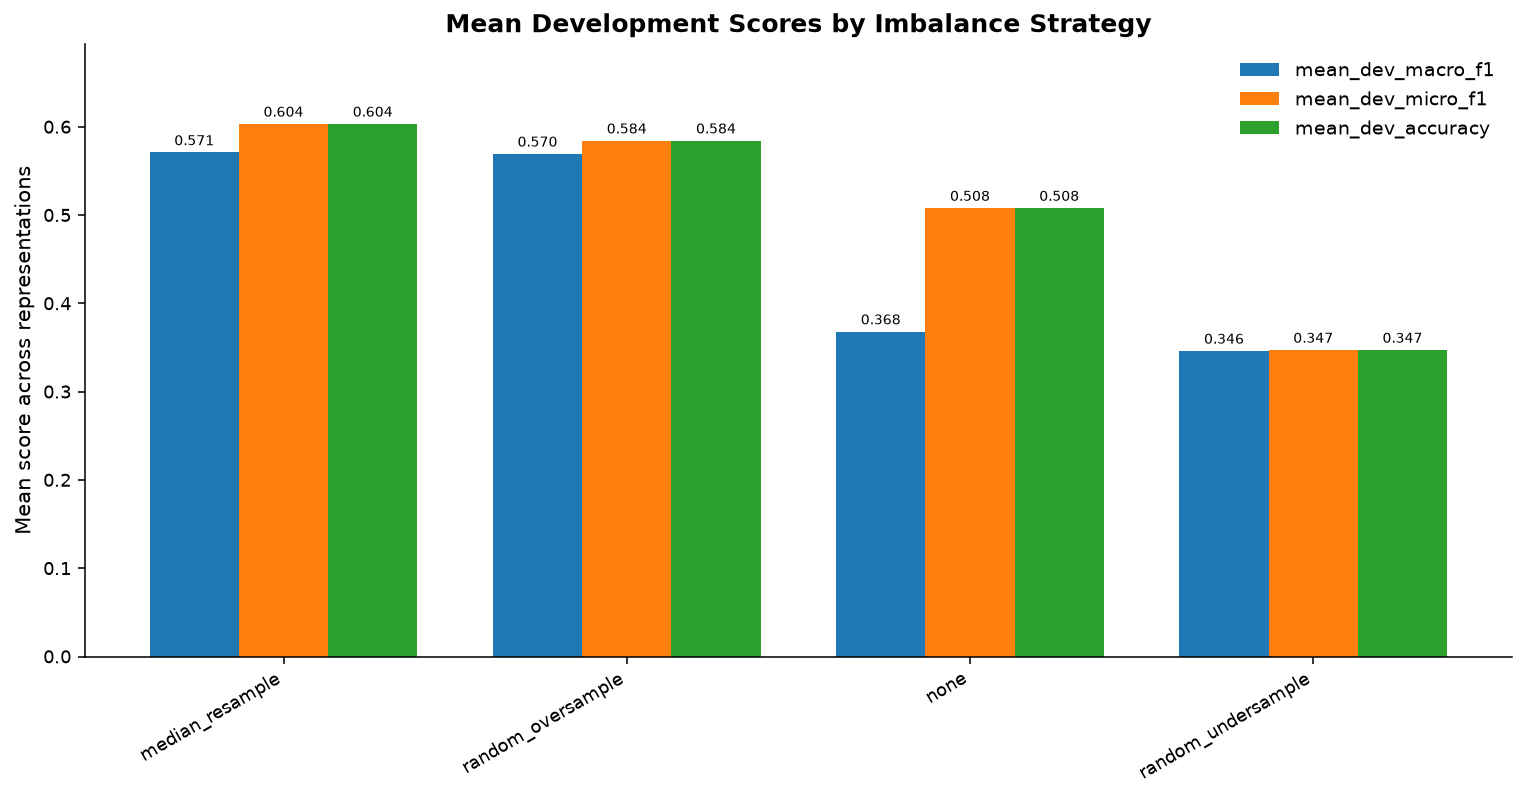

Selected imbalance strategy: median_resample


In [21]:
plot_df = imbalance_results_df.copy()
plot_df["strategy_and_representation"] = (
    plot_df["imbalance_strategy"] + "\n" + plot_df["representation"]
)

plot_grouped_metric_bars(
    plot_df,
    category_col="strategy_and_representation",
    metric_cols=["dev_macro_f1", "dev_micro_f1"],
    title="Development Performance by Imbalance Strategy and Representation",
    ylabel="Score",
    sort_by="dev_macro_f1",
    rotation=45,
)

imbalance_summary_df = (
    imbalance_results_df
    .groupby("imbalance_strategy", as_index=False)
    .agg(
        mean_dev_macro_f1=("dev_macro_f1", "mean"),
        mean_dev_micro_f1=("dev_micro_f1", "mean"),
        mean_dev_accuracy=("dev_accuracy", "mean"),
        mean_train_size=("train_size_after_strategy", "mean"),
    )
    .sort_values(["mean_dev_macro_f1", "mean_dev_micro_f1"], ascending=False)
    .reset_index(drop=True)
)

display(imbalance_summary_df)

plot_grouped_metric_bars(
    imbalance_summary_df,
    category_col="imbalance_strategy",
    metric_cols=["mean_dev_macro_f1", "mean_dev_micro_f1", "mean_dev_accuracy"],
    title="Mean Development Scores by Imbalance Strategy",
    ylabel="Mean score across representations",
    sort_by="mean_dev_macro_f1",
    rotation=30,
)

SELECTED_IMBALANCE_STRATEGY = imbalance_summary_df.loc[0, "imbalance_strategy"]
print("Selected imbalance strategy:", SELECTED_IMBALANCE_STRATEGY)

**TODO:** Which strategy gives the best macro-F1? Is it also the best micro-F1? Which metric should guide the choice here?

### Selected training distribution

Use the selected strategy from this point onward.


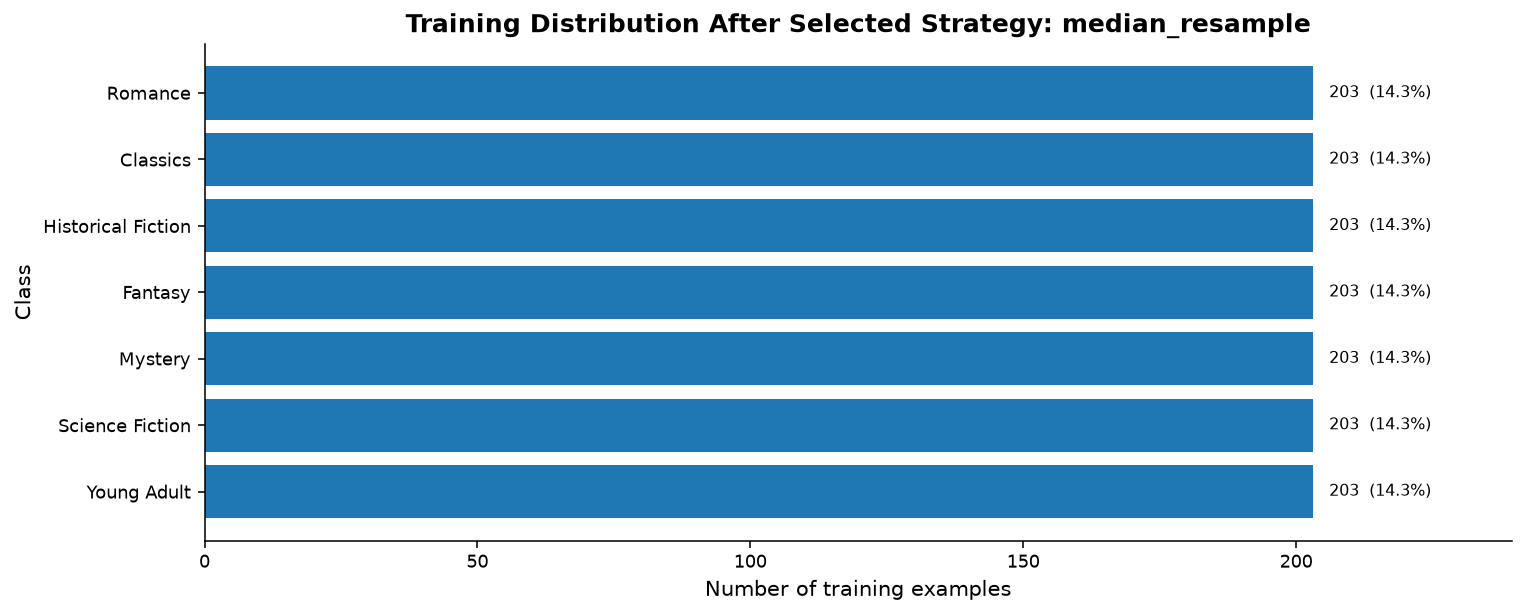

In [22]:
selected_train_rows = make_resampled_indices(
    y_train,
    strategy=SELECTED_IMBALANCE_STRATEGY,
    random_state=RANDOM_STATE,
)

y_train_selected = np.asarray(y_train)[selected_train_rows]

X_tfidf_train_selected = subset_rows(X_tfidf_train, selected_train_rows)
X_emb_train_selected = subset_rows(X_emb_train, selected_train_rows)

selected_counts = pd.Series(
    np.asarray(class_names)[y_train_selected]
).value_counts()

plot_horizontal_count_distribution(
    selected_counts,
    title=f"Training Distribution After Selected Strategy: {SELECTED_IMBALANCE_STRATEGY}",
    xlabel="Number of training examples",
)

## 12. Prepare dense TF-IDF features for the MLP

Train the MLP on dense TF-IDF vectors. Since full TF-IDF can have tens of thousands of columns, select the highest-variance TF-IDF features from the selected training set and convert only those columns to dense arrays.

Keep regular sparse TF-IDF vectors for Naive Bayes, kNN, and Logistic Regression.

In [23]:
n_dense_features = 300  # how many TF-IDF columns to keep as dense features

selected_tfidf_dense_columns = select_top_sparse_columns_by_variance(
    X_tfidf_train_selected,
    max_features=n_dense_features,
)

X_tfidf_dense_train = X_tfidf_train_selected[:, selected_tfidf_dense_columns].toarray()
X_tfidf_dense_dev = X_tfidf_dev[:, selected_tfidf_dense_columns].toarray()
X_tfidf_dense_test = X_tfidf_test[:, selected_tfidf_dense_columns].toarray()

selected_dense_feature_names = tfidf_vectorizer.get_feature_names_out()[selected_tfidf_dense_columns]

print("Dense TF-IDF train shape:", X_tfidf_dense_train.shape)
print("Selected dense TF-IDF features:", len(selected_dense_feature_names))

Dense TF-IDF train shape: (1421, 300)
Selected dense TF-IDF features: 300


## 13. Train the classification models

Train the required models on both representations where appropriate.

Required models:

- Naive Bayes
- kNN
- Logistic Regression
- MLP

In [24]:
trained_models = {}
dev_results = []

def train_dev_model(model_name, representation_name, model, X_train_current, y_train_current, X_dev_current, y_dev_current):
    metrics, train_seconds, predict_seconds, _ = fit_predict_and_score(
        model, X_train_current, y_train_current, X_dev_current, y_dev_current
    )

    key = f"{representation_name} | {model_name}"
    trained_models[key] = model

    dev_results.append({
        "representation": representation_name,
        "model": model_name,
        "imbalance_strategy": SELECTED_IMBALANCE_STRATEGY,
        "train_seconds": train_seconds,
        "dev_predict_seconds": predict_seconds,
        "dev_accuracy": metrics["accuracy"],
        "dev_macro_precision": metrics["macro_precision"],
        "dev_macro_recall": metrics["macro_recall"],
        "dev_macro_f1": metrics["macro_f1"],
        "dev_micro_f1": metrics["micro_f1"],
    })

    print(f"{key}")
    print(f"  dev accuracy : {metrics['accuracy']:.4f}")
    print(f"  dev macro-F1 : {metrics['macro_f1']:.4f}")
    print(f"  train seconds: {train_seconds:.2f}")
    print(f"  pred seconds : {predict_seconds:.2f}")
    print()

### 13.1 TF-IDF models

In [25]:
train_dev_model(
    model_name="MultinomialNB",
    representation_name="TF-IDF",
    model=ScratchMultinomialNB(alpha=0.01),
    X_train_current=X_tfidf_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_tfidf_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="kNN",
    representation_name="TF-IDF",
    model=ScratchKNNClassifier(n_neighbors=KNN_NEIGHBORS, metric="cosine"),
    X_train_current=X_tfidf_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_tfidf_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="Logistic Regression",
    representation_name="TF-IDF",
    model=ScratchSoftmaxLogisticRegression(
        learning_rate=LR_LEARNING_RATE,
        max_epochs=LR_MAX_EPOCHS,
        batch_size=LR_BATCH_SIZE,
        alpha=LR_ALPHA,
        random_state=RANDOM_STATE,
    ),
    X_train_current=X_tfidf_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_tfidf_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="MLP",
    representation_name="TF-IDF-dense",
    model=ScratchScaledClassifier(
        ScratchMLPClassifier(
            hidden_dim=MLP_HIDDEN_DIM,
            learning_rate=MLP_LEARNING_RATE,
            max_epochs=MLP_MAX_EPOCHS,
            batch_size=MLP_BATCH_SIZE,
            alpha=MLP_ALPHA,
            random_state=RANDOM_STATE,
        )
    ),
    X_train_current=X_tfidf_dense_train,
    y_train_current=y_train_selected,
    X_dev_current=X_tfidf_dense_dev,
    y_dev_current=y_dev,
)

TF-IDF | MultinomialNB
  dev accuracy : 0.6240
  dev macro-F1 : 0.5541
  train seconds: 0.00
  pred seconds : 0.00

TF-IDF | kNN
  dev accuracy : 0.5695
  dev macro-F1 : 0.5409
  train seconds: 0.00
  pred seconds : 0.02

TF-IDF | Logistic Regression
  dev accuracy : 0.5531
  dev macro-F1 : 0.5243
  train seconds: 0.08
  pred seconds : 0.00

TF-IDF-dense | MLP
  dev accuracy : 0.1826
  dev macro-F1 : 0.1669
  train seconds: 0.31
  pred seconds : 0.00



### 13.2 Sentence embedding models

In [26]:
train_dev_model(
    model_name="GaussianNB",
    representation_name="Sentence embedding",
    model=ScratchGaussianNB(var_smoothing=1e-9),
    X_train_current=X_emb_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_emb_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="kNN",
    representation_name="Sentence embedding",
    model=ScratchKNNClassifier(n_neighbors=KNN_NEIGHBORS, metric="cosine"),
    X_train_current=X_emb_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_emb_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="Logistic Regression",
    representation_name="Sentence embedding",
    model=ScratchScaledClassifier(
        ScratchSoftmaxLogisticRegression(
            learning_rate=LR_LEARNING_RATE,
            max_epochs=LR_MAX_EPOCHS,
            batch_size=LR_BATCH_SIZE,
            alpha=LR_ALPHA,
            random_state=RANDOM_STATE,
        )
    ),
    X_train_current=X_emb_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_emb_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="MLP",
    representation_name="Sentence embedding",
    model=ScratchScaledClassifier(
        ScratchMLPClassifier(
            hidden_dim=MLP_HIDDEN_DIM,
            learning_rate=MLP_LEARNING_RATE,
            max_epochs=MLP_MAX_EPOCHS,
            batch_size=MLP_BATCH_SIZE,
            alpha=MLP_ALPHA,
            random_state=RANDOM_STATE,
        )
    ),
    X_train_current=X_emb_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_emb_dev,
    y_dev_current=y_dev,
)

Sentence embedding | GaussianNB
  dev accuracy : 0.6349
  dev macro-F1 : 0.6152
  train seconds: 0.01
  pred seconds : 0.02

Sentence embedding | kNN
  dev accuracy : 0.6458
  dev macro-F1 : 0.6138
  train seconds: 0.00
  pred seconds : 0.01

Sentence embedding | Logistic Regression
  dev accuracy : 0.6730
  dev macro-F1 : 0.6368
  train seconds: 0.24
  pred seconds : 0.00

Sentence embedding | MLP
  dev accuracy : 0.4578
  dev macro-F1 : 0.4252
  train seconds: 0.48
  pred seconds : 0.00



## 14. Compare development results

Select the final model using development macro-F1.

In [27]:
dev_results_df = pd.DataFrame(dev_results)
dev_results_df = dev_results_df.sort_values("dev_macro_f1", ascending=False).reset_index(drop=True)
dev_results_df["model_label"] = dev_results_df["representation"] + "\n" + dev_results_df["model"]

display(dev_results_df)

,representation,model,imbalance_strategy,train_seconds,dev_predict_seconds,dev_accuracy,dev_macro_precision,dev_macro_recall,dev_macro_f1,dev_micro_f1,model_label
0,Sentence embedding,Logistic Regression,median_resample,0.242455,0.001998,0.673025,0.627294,0.657791,0.636802,0.673025,Sentence embedding\nLogistic Regression
1,Sentence embedding,GaussianNB,median_resample,0.007024,0.017042,0.634877,0.607885,0.645161,0.615217,0.634877,Sentence embedding\nGaussianNB
2,Sentence embedding,kNN,median_resample,0.003514,0.011416,0.645777,0.614088,0.672126,0.613846,0.645777,Sentence embedding\nkNN
3,TF-IDF,MultinomialNB,median_resample,0.002002,0.000000,0.623978,0.609835,0.559025,0.554127,0.623978,TF-IDF\nMultinomialNB
4,TF-IDF,kNN,median_resample,0.001999,0.017090,0.569482,0.534420,0.592768,0.540942,0.569482,TF-IDF\nkNN
5,TF-IDF,Logistic Regression,median_resample,0.083541,0.001000,0.553134,0.527858,0.571869,0.524287,0.553134,TF-IDF\nLogistic Regression
6,Sentence embedding,MLP,median_resample,0.480937,0.002017,0.457766,0.430045,0.463415,0.425174,0.457766,Sentence embedding\nMLP
7,TF-IDF-dense,MLP,median_resample,0.313235,0.000961,0.182561,0.183861,0.181818,0.166885,0.182561,TF-IDF-dense\nMLP


### Model comparison on the development set

Compare models and representations before touching the test set.



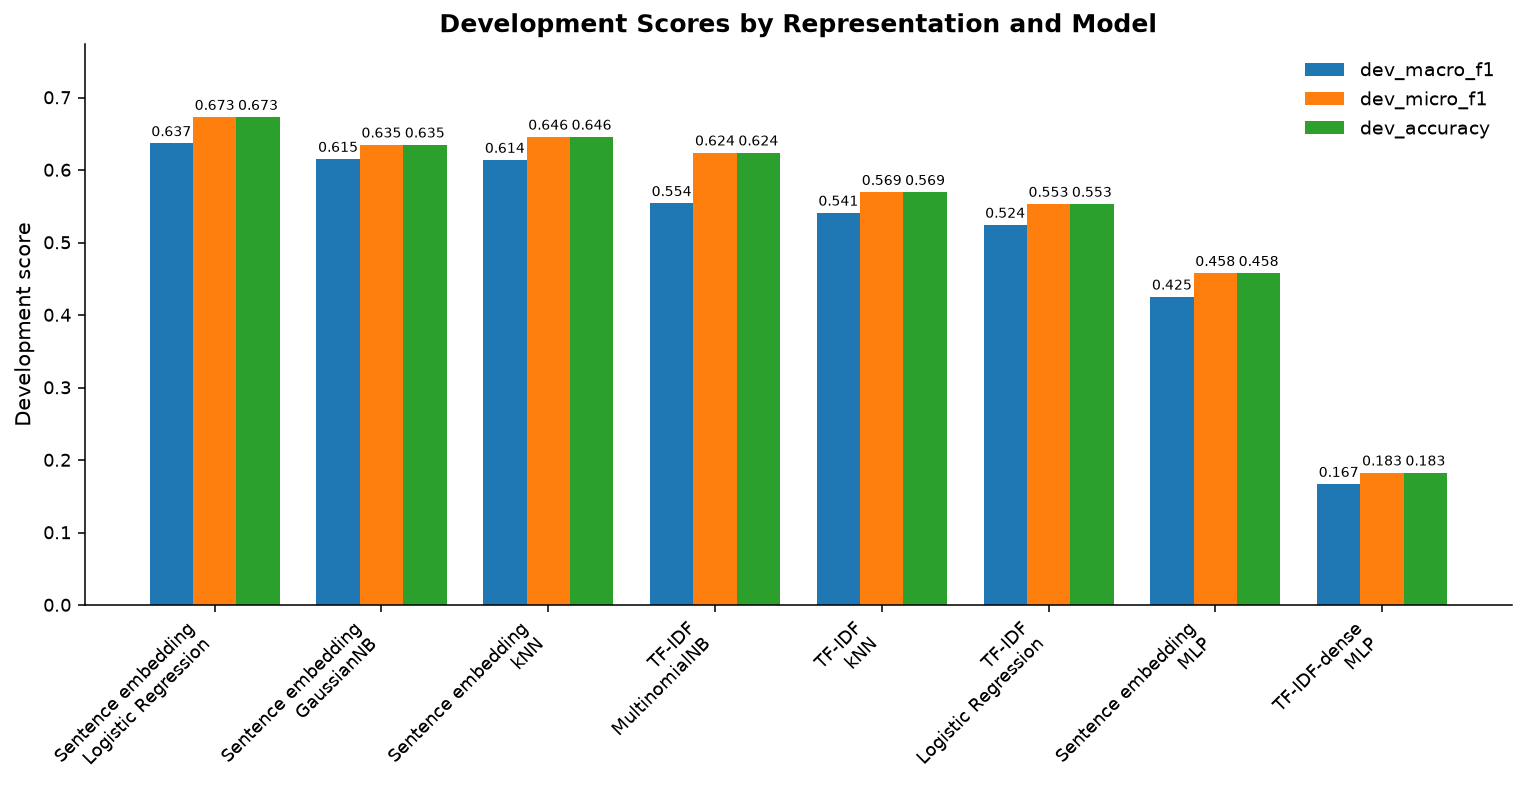

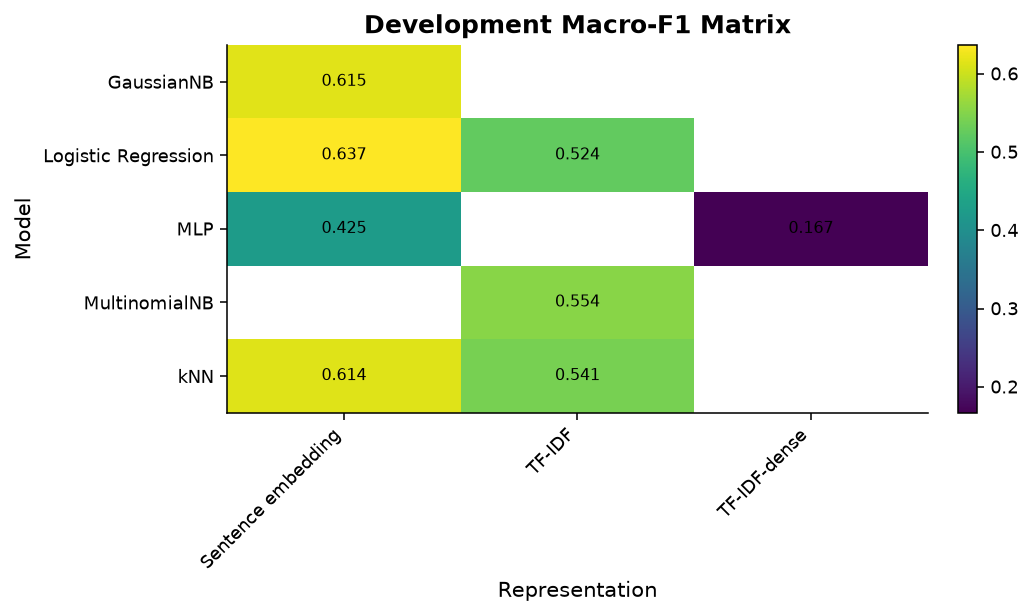

In [28]:
plot_grouped_metric_bars(
    dev_results_df,
    category_col="model_label",
    metric_cols=["dev_macro_f1", "dev_micro_f1", "dev_accuracy"],
    title="Development Scores by Representation and Model",
    ylabel="Development score",
    sort_by="dev_macro_f1",
    rotation=45,
)

macro_matrix = (
    dev_results_df
    .pivot_table(index="model", columns="representation", values="dev_macro_f1", aggfunc="max")
    .sort_index()
)

plot_metric_heatmap(
    macro_matrix,
    title="Development Macro-F1 Matrix",
    xlabel="Representation",
    ylabel="Model",
    value_format=".3f",
)

**TODO:** Which representation works better overall? Which model benefits most from sentence embeddings? Does the MLP improve results enough to justify its cost?

1. Which representation works better overall?

Sentence embeddings work better, top three performance spots. Standard sparse TF-IDF lags behind, and truncating it to (`TF-IDF-dense`) gives the worst performance.

2. Which model benefits most from sentence embeddings?

- The MLP gets the best self-improvement by +0.258 Macro-F1 from dense TF-IDF to sentence embeddings. 
-  Logistic Regression benefits most in terms of peak utility.

3. Does the MLP improve results enough to justify its cost?

No. The performance to result ratio is not justifiable in my opinion.

### Accuracy/efficiency trade-off

Inspect training cost alongside model quality.



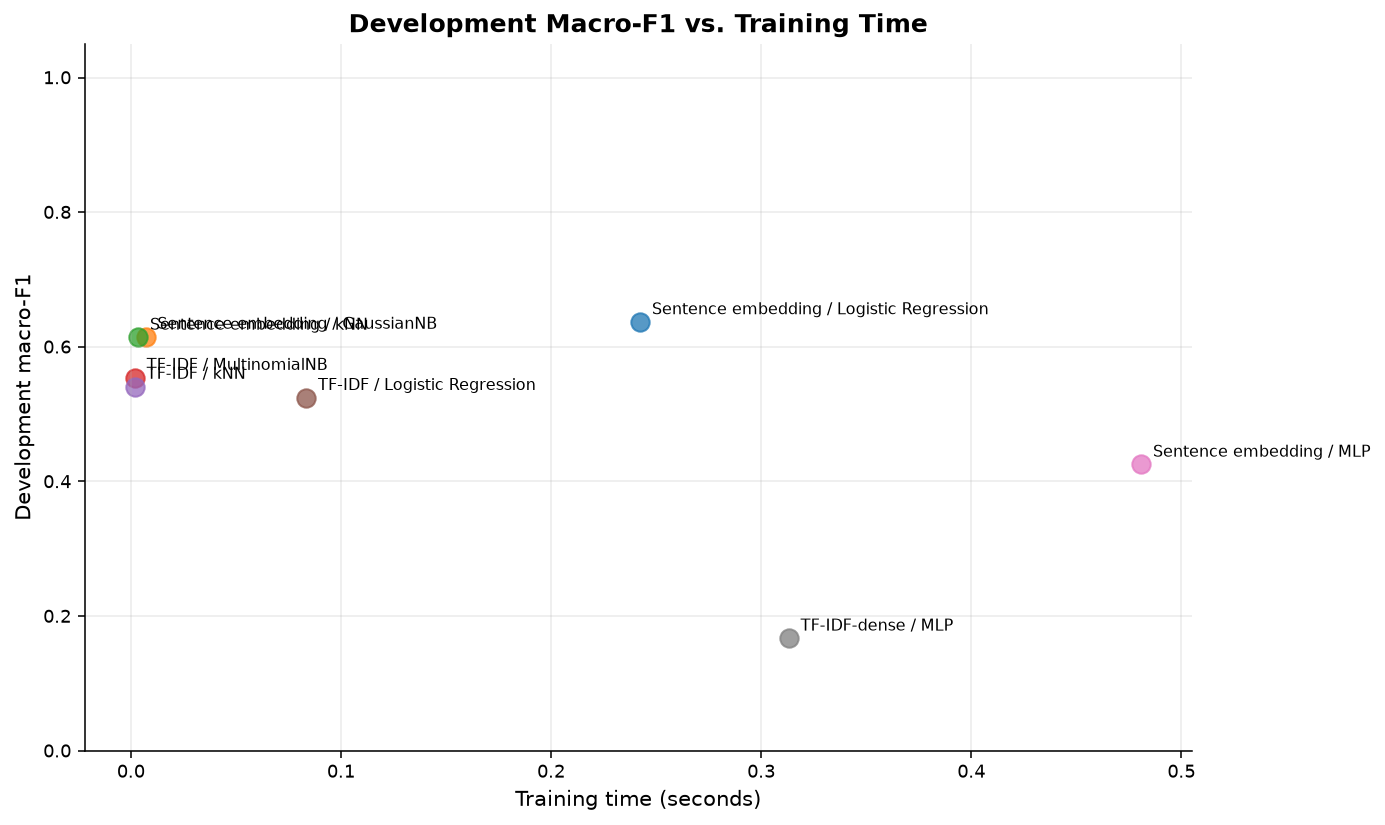

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in dev_results_df.iterrows():
    ax.scatter(row["train_seconds"], row["dev_macro_f1"], s=90, alpha=0.75)
    ax.annotate(
        row["model_label"].replace("\n", " / "),
        (row["train_seconds"], row["dev_macro_f1"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
    )

ax.set_title("Development Macro-F1 vs. Training Time")
ax.set_xlabel("Training time (seconds)")
ax.set_ylabel("Development macro-F1")
ax.set_ylim(0, 1.05)
ax.grid(True)
plt.tight_layout()
plt.show()

**TODO:** Which model is the best trade-off between macro-F1 and training time?

Sentence embedding / GaussianNB offers the best overall trade-off.

### Model selection

Answer the following questions:

1. Which model has the highest development macro-F1?
2. Does the same model also have the highest micro-F1?
3. Which representation is stronger: TF-IDF or sentence embedding?
4. Does MLP improve over Logistic Regression? If yes, is the improvement large enough?
5. Which model should be selected for final test evaluation, and why?

## 15. Final test evaluation

Evaluate every trained model on the test set for reporting. Choose the main final model according to development macro-F1, not test performance.

In [30]:
test_results = []
def get_test_matrix_for_representation(representation_name):
    if representation_name == "TF-IDF":
        return X_tfidf_test
    if representation_name == "TF-IDF-dense":
        return X_tfidf_dense_test
    if representation_name == "Sentence embedding":
        return X_emb_test
    raise ValueError(f"Unknown representation: {representation_name}")


for _, row in dev_results_df.iterrows():
    representation_name = row["representation"]
    model_name = row["model"]
    key = f"{representation_name} | {model_name}"
    model = trained_models[key]
    X_test_current = get_test_matrix_for_representation(representation_name)

    start_time = time.time()
    y_pred_test_current = model.predict(X_test_current)
    test_predict_seconds = time.time() - start_time

    metrics = compute_metrics(y_test, y_pred_test_current)

    test_results.append({
        "representation": representation_name,
        "model": model_name,
        "imbalance_strategy": SELECTED_IMBALANCE_STRATEGY,
        "test_predict_seconds": test_predict_seconds,
        "test_accuracy": metrics["accuracy"],
        "test_macro_precision": metrics["macro_precision"],
        "test_macro_recall": metrics["macro_recall"],
        "test_macro_f1": metrics["macro_f1"],
        "test_micro_f1": metrics["micro_f1"],
    })

test_results_df = pd.DataFrame(test_results)
test_results_df = test_results_df.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
test_results_df["model_label"] = test_results_df["representation"] + "\n" + test_results_df["model"]
display(test_results_df)

test_results_df.to_csv(OUTPUT_TEST_RESULTS_CSV, index=False)
print("Saved test results to:", OUTPUT_TEST_RESULTS_CSV)

,representation,model,imbalance_strategy,test_predict_seconds,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_micro_f1,model_label
0,Sentence embedding,Logistic Regression,median_resample,0.000996,0.672872,0.630511,0.644701,0.632918,0.672872,Sentence embedding\nLogistic Regression
1,Sentence embedding,kNN,median_resample,0.011513,0.654255,0.620758,0.665861,0.619556,0.654255,Sentence embedding\nkNN
2,TF-IDF,MultinomialNB,median_resample,0.000000,0.635638,0.621719,0.571200,0.569546,0.635638,TF-IDF\nMultinomialNB
3,TF-IDF,Logistic Regression,median_resample,0.000000,0.587766,0.561448,0.597189,0.562177,0.587766,TF-IDF\nLogistic Regression
4,Sentence embedding,GaussianNB,median_resample,0.018042,0.627660,0.557975,0.569656,0.556668,0.627660,Sentence embedding\nGaussianNB
5,TF-IDF,kNN,median_resample,0.015998,0.563830,0.532174,0.580533,0.531356,0.563830,TF-IDF\nkNN
6,Sentence embedding,MLP,median_resample,0.003070,0.406915,0.387088,0.409468,0.373698,0.406915,Sentence embedding\nMLP
7,TF-IDF-dense,MLP,median_resample,0.001766,0.148936,0.163661,0.160917,0.141546,0.148936,TF-IDF-dense\nMLP


Saved test results to: classification_test_results.csv


### Model comparison on the test set

Use this as the final report figure. Do not use it to go back and change model choices.



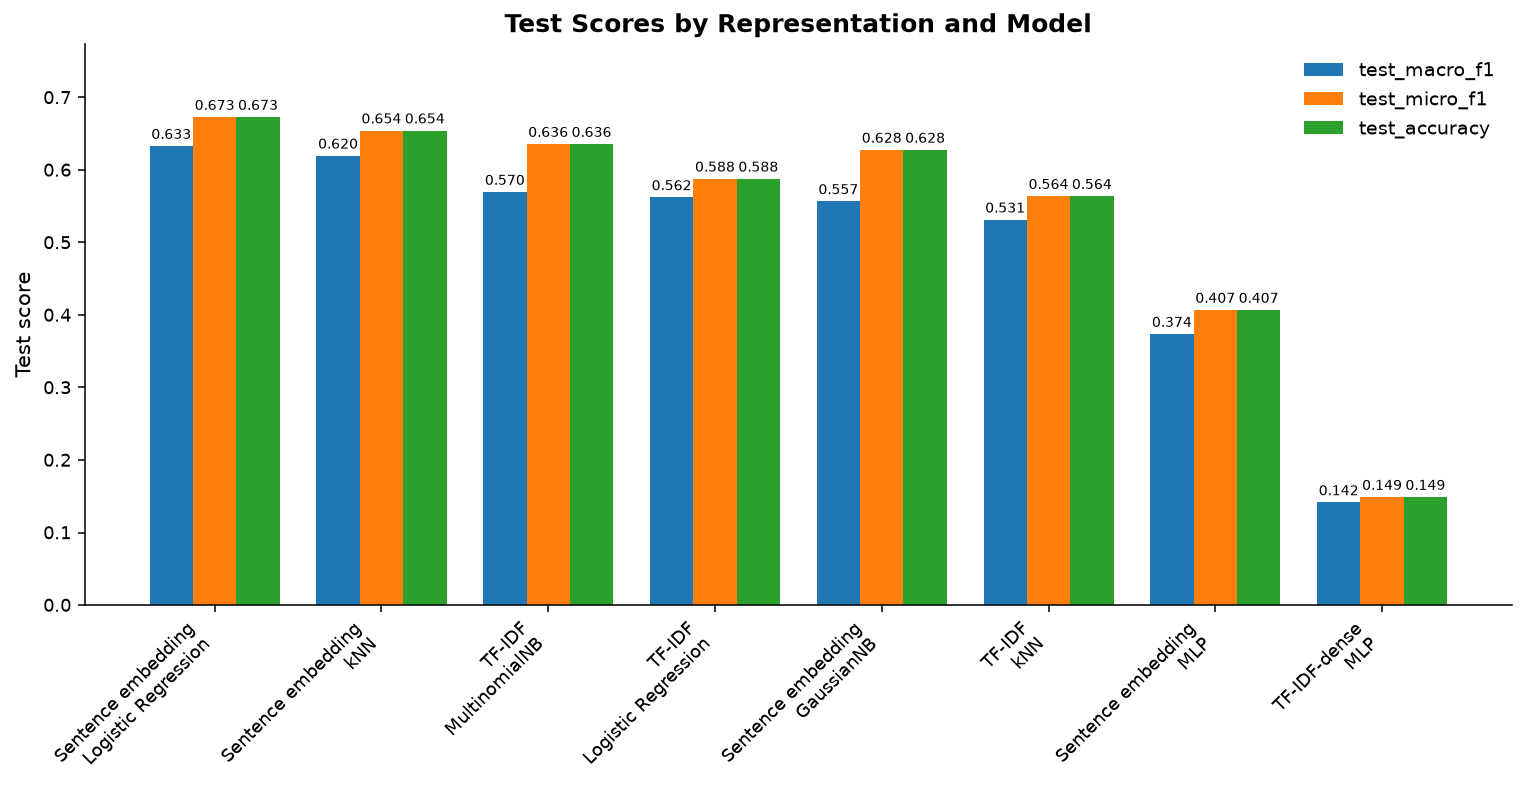

In [31]:
plot_grouped_metric_bars(
    test_results_df,
    category_col="model_label",
    metric_cols=["test_macro_f1", "test_micro_f1", "test_accuracy"],
    title="Test Scores by Representation and Model",
    ylabel="Test score",
    sort_by="test_macro_f1",
    rotation=45,
)

**TODO:** Are test results consistent with development results? Which model generalizes best?


they are consistent. Sentence Embedding / Logistic Regression shows almost no performance drop when moving from validation to  test set:

The Sentence Embedding /Logistic Regression model generalizes the best.



## 16. Inspect the selected final model

Select the final model using development macro-F1, then inspect its test behavior.

In [32]:
best_dev_row = dev_results_df.iloc[0]
best_representation = best_dev_row["representation"]
best_model_name = best_dev_row["model"]
best_key = f"{best_representation} | {best_model_name}"

best_model = trained_models[best_key]
X_test_best = get_test_matrix_for_representation(best_representation)
y_pred_test = best_model.predict(X_test_best)

print("Best model selected using dev macro-F1:")
print(best_key)
print()
print("Selected imbalance strategy:", SELECTED_IMBALANCE_STRATEGY)
print()
print("Test classification report:")
print(classification_report_scratch(
    y_test,
    y_pred_test,
    target_names=class_names,
    digits=3,
))

Best model selected using dev macro-F1:
Sentence embedding | Logistic Regression

Selected imbalance strategy: median_resample

Test classification report:
                      precision     recall   f1-score    support
            Classics      0.675      0.628      0.651         86
             Fantasy      0.788      0.696      0.739        112
  Historical Fiction      0.600      0.643      0.621         42
             Mystery      0.709      0.796      0.750         49
             Romance      0.596      0.705      0.646         44
     Science Fiction      0.545      0.692      0.610         26
         Young Adult      0.500      0.353      0.414         17

            accuracy                            0.673        376
           macro avg      0.631      0.645      0.633        376
           micro avg      0.673      0.673      0.673        376


## 17. Confusion matrix

Inspect the row-normalized confusion matrix. Each cell shows count and row percentage.



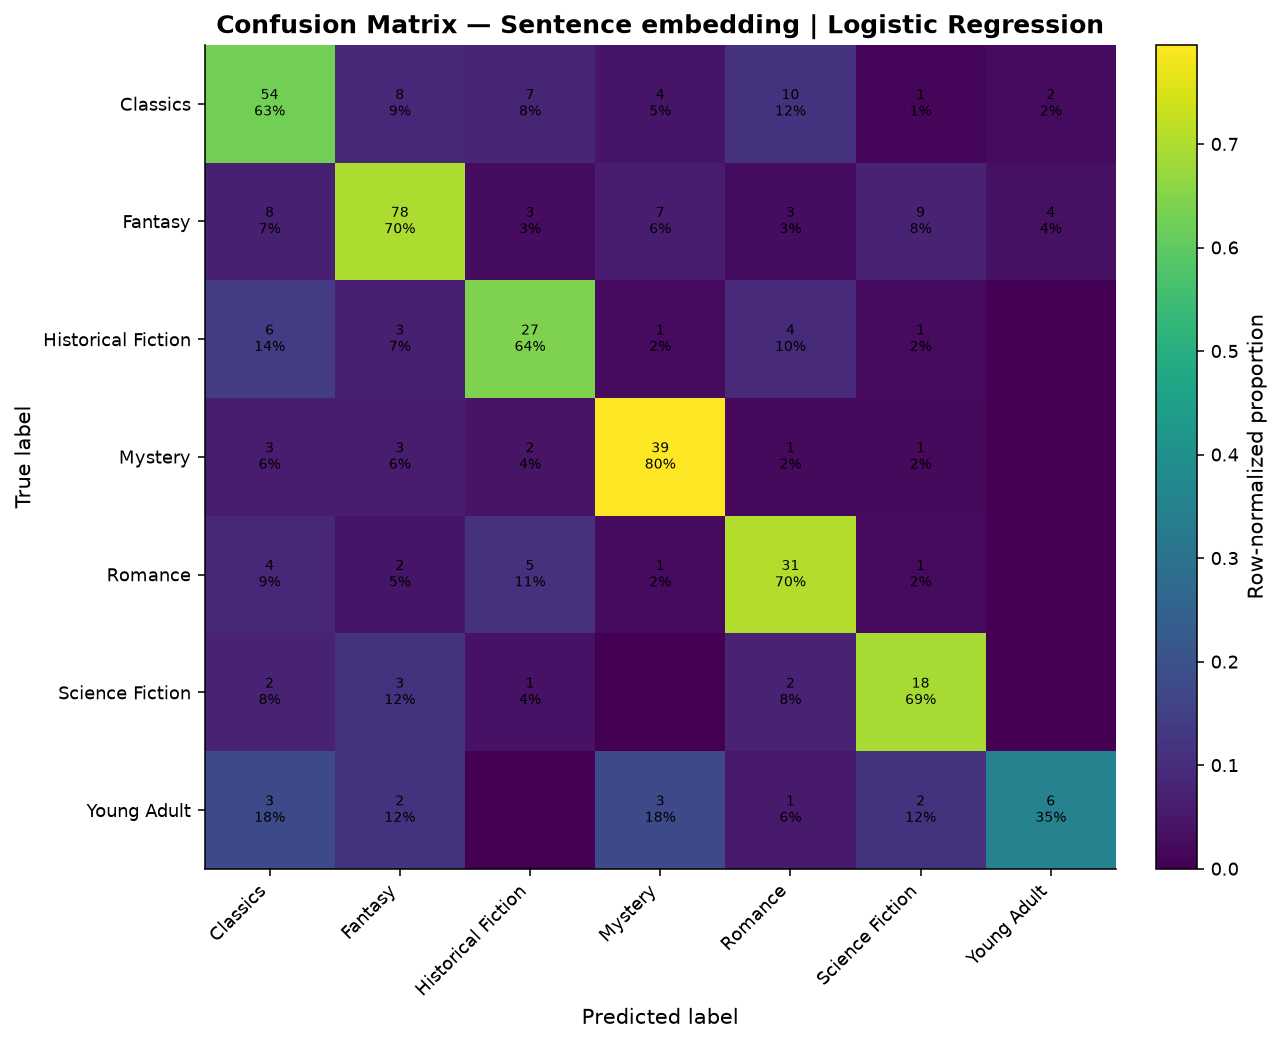

In [33]:
plot_confusion_matrix_professional(
    y_test,
    y_pred_test,
    class_names,
    title=f"Confusion Matrix — {best_key}",
)

**TODO:** Which genres are most often confused? Are these mistakes understandable from the descriptions?



- Historical Fiction / Classics



- Romance / Historical Fiction / Classics



- Fantasy/ Mystery / Science Fiction




Yes. they are completely logical unlike "Mystery" or "Fantasy" which have distinct genre, a book becomes a "Classic" based on age and cultural values and historical eras.

## 18. Per-class F1 analysis

Inspect final model quality per genre.



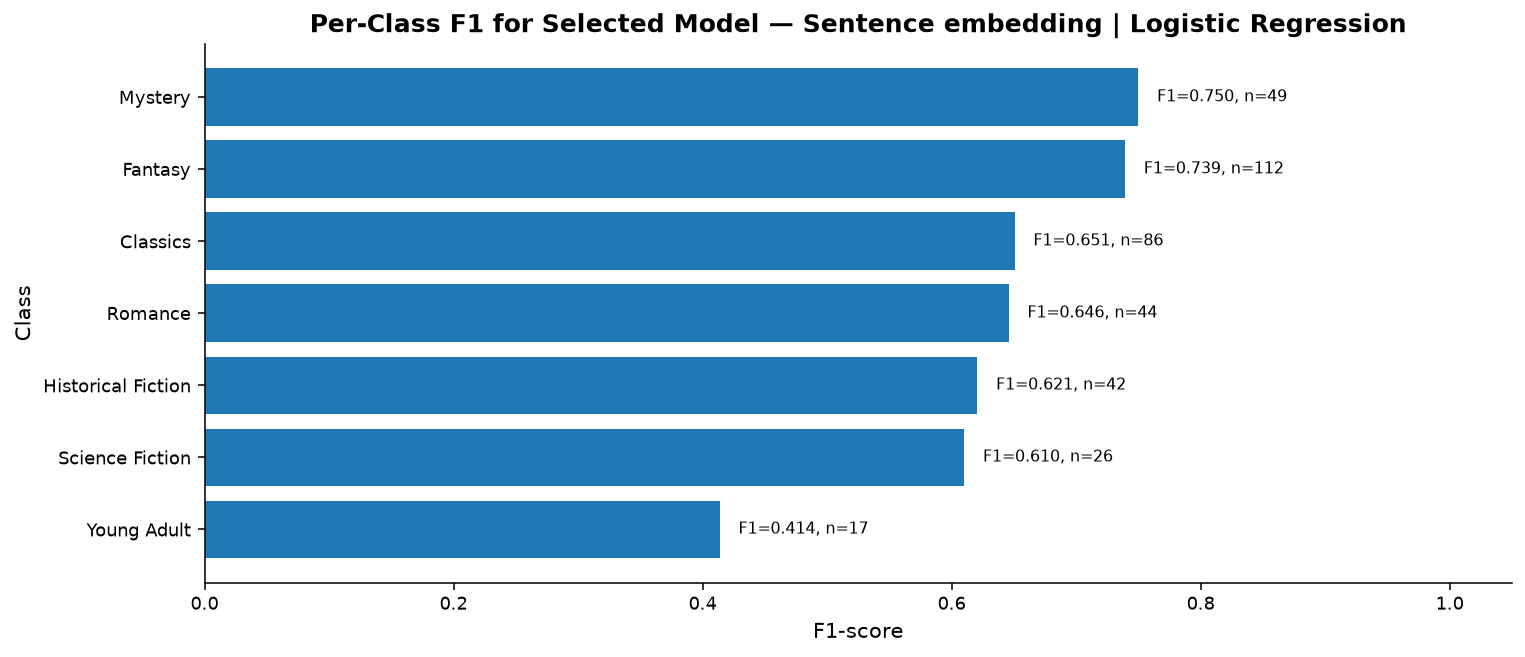

In [34]:
report = classification_report_scratch(
    y_test,
    y_pred_test,
    target_names=class_names,
    output_dict=True,
)

report_df = pd.DataFrame(report).T
class_report_df = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]]

plot_per_class_f1(
    class_report_df,
    title=f"Per-Class F1 for Selected Model — {best_key}",
)

**TODO:** Which classes are easiest? Which classes are hardest? Are weak classes also minority classes?

## 19. Error analysis

Inspect individual mistakes and common confusion pairs.

In [35]:
test_df = df.iloc[test_idx].copy().reset_index(drop=True)
test_df["true_label"] = np.asarray(class_names)[y_test]
test_df["predicted_label"] = np.asarray(class_names)[y_pred_test]
test_df["is_error"] = test_df["true_label"] != test_df["predicted_label"]

columns_to_show = ["true_label", "predicted_label", DESCRIPTION_COLUMN]
if TITLE_COLUMN in test_df.columns:
    columns_to_show = [TITLE_COLUMN] + columns_to_show

errors_df = test_df[test_df["is_error"]].reset_index(drop=True)

print("Number of test errors:", len(errors_df))
print("Test error rate:", len(errors_df) / len(test_df))

display(errors_df[columns_to_show].head(20))

Number of test errors: 123
Test error rate: 0.3271276595744681


,title,true_label,predicted_label,description
0,Frankenstein,Historical Fiction,Classics,Originally published as part of a contest betw...
1,Interpreter of Maladies,Fantasy,Mystery,Navigating between the Indian traditions they'...
2,The Brothers Karamazov,Romance,Historical Fiction,After spending four years in a Siberian penal ...
3,The Great Gatsby,Romance,Classics,"The exemplary novel of the Jazz Age, F. Scott ..."
4,Anne of Avonlea,Fantasy,Science Fiction,"Avonlea's new schoolma'am, at the age of 15, i..."
5,The Scarlet Letter,Young Adult,Mystery,\The Scarlet Letter: A Kaplan SAT Score-Raisin...
6,The Death Of Ivan Ilych,Fantasy,Mystery,This scarce antiquarian book is a facsimile re...
7,Getting Ready to Negotiate: The Getting to Yes...,Romance,Fantasy,This companion volume to the negotiation class...
8,The Hotel New Hampshire,Classics,Romance,"So says John Berry, son of a hapless dreamer, ..."
9,Magician: Master,Romance,Historical Fiction,He held the fate of two worlds in his hands......


### Most common confusion pairs

Use this plot to choose examples for manual error analysis.



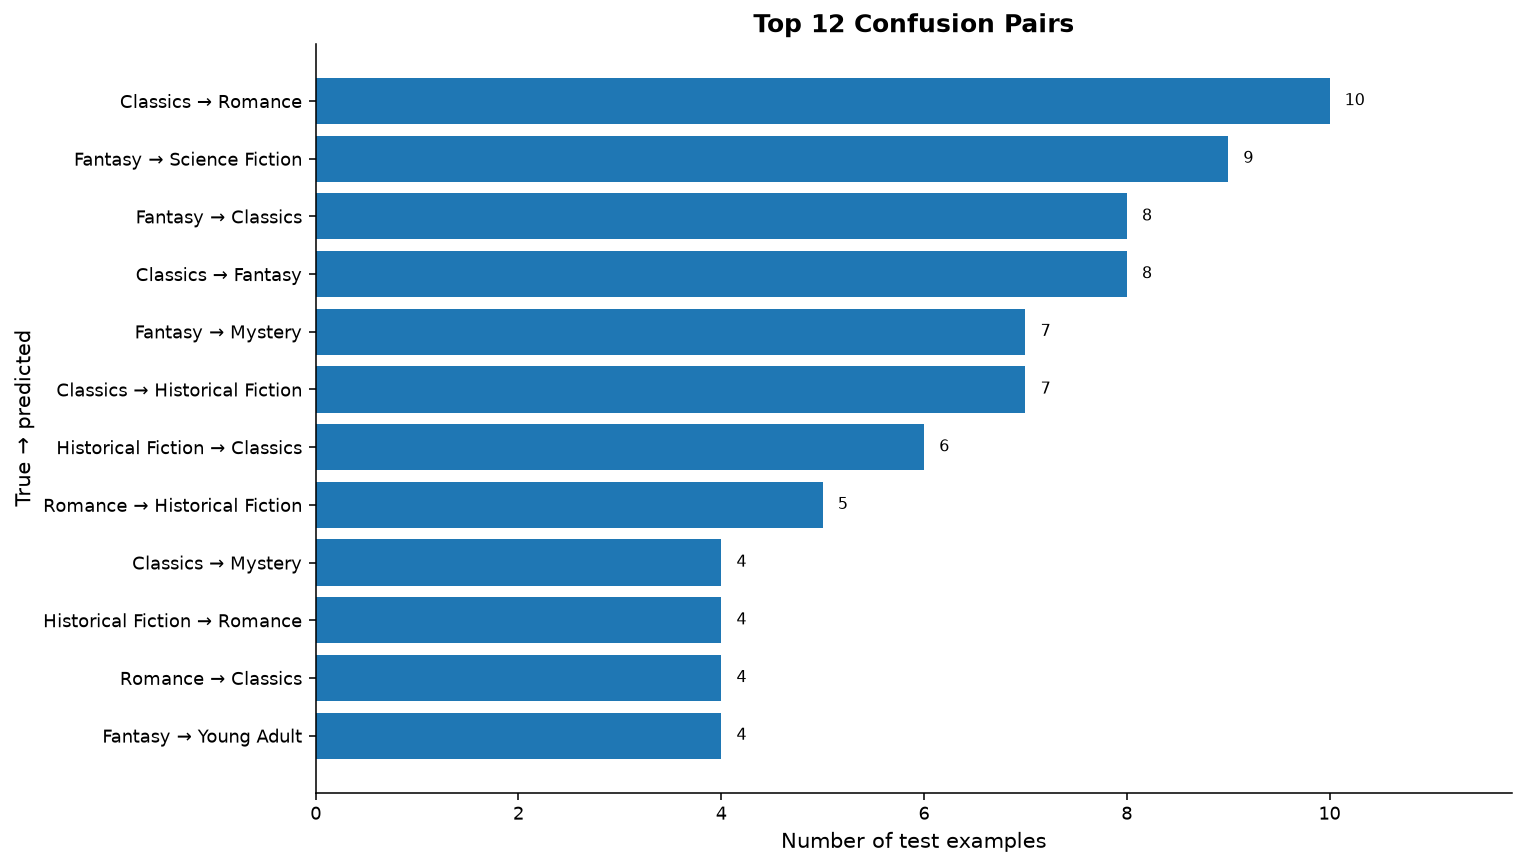

In [36]:
plot_confusion_pairs(errors_df, top_n=12)

**TODO:** Pick three confusion pairs. For each pair, inspect multiple examples and explain why the classifier may be confused.


###  Historical Fiction & Classics

 - Frankenstein
 - Much Ado About Nothing

 Classics isnt a clear genre. It usually means old books.Therefore the model may confuse old fictions with classics because the use of older words is simillarly high.

###  Fantasy & Mystery

- The Death of Ivan Ilych

Books like The Death of Ivan Ilych are tagged as Fantasy but don't have any fantasy words and phrases like magic or wizards. They are actually more of dark dramas.

###  Classics & Romance

- The Hotel New Hampshire
- Tears of the Giraffe

Again here there is an overlaping of phrases and words. When a description focuses heavily on character dynamics historical events or eras, the model picks on that and misclassifies it as a Romance.

## 20. Interpret TF-IDF Logistic Regression features

Inspect the strongest positive terms for each class. This section is only available if TF-IDF Logistic Regression was trained.



In [37]:
tfidf_lr_key = "TF-IDF | Logistic Regression"

if tfidf_lr_key in trained_models:
    lr_model = trained_models[tfidf_lr_key]
    feature_names = tfidf_vectorizer.get_feature_names_out()

    coef = lr_model.coef_          
    rows = []

    top_k = 10
    for class_index, class_name in enumerate(class_names):
        weights = coef[class_index]
        top_indices = np.argsort(weights)[::-1][:top_k]
        top_terms = feature_names[top_indices]
        top_weights = weights[top_indices]

        rows.append({
            "class": class_name,
            "top_terms": ", ".join(top_terms),
            "top_weights": ", ".join([f"{w:.3f}" for w in top_weights]),
        })

    top_features_df = pd.DataFrame(rows)
    display(top_features_df)
else:
    print("TF-IDF Logistic Regression was not trained.")

,class,top_terms,top_weights
0,Classics,"greatest, century, literature, work, society, ...","0.102, 0.094, 0.085, 0.079, 0.077, 0.077, 0.07..."
1,Fantasy,"evil, dark, king, ring, magic, the dark, book,...","0.131, 0.128, 0.120, 0.106, 0.097, 0.093, 0.09..."
2,Historical Fiction,"hesse, siddhartha, novel, tolstoy, babies, ame...","0.184, 0.119, 0.114, 0.112, 0.100, 0.099, 0.09..."
3,Mystery,"murder, detective, case, poirot, murdered, mys...","0.227, 0.196, 0.166, 0.146, 0.132, 0.132, 0.13..."
4,Romance,"her, love, she, life, romance, in love, york, ...","0.276, 0.238, 0.208, 0.101, 0.096, 0.091, 0.08..."
5,Science Fiction,"future, clare, science, 50, science fiction, v...","0.253, 0.161, 0.160, 0.156, 0.145, 0.142, 0.14..."
6,Young Adult,"play, text, hamlet, pants, text of, shakespear...","0.181, 0.178, 0.170, 0.158, 0.134, 0.133, 0.12..."


**TODO:** Are the top terms meaningful for each class? Are there noisy or surprising terms?

- Are the top terms meaningful for each class?

Yes Mystery, Fantasy, and Romance have near-perfect keywords. Words like `murder, detective, poirot` (Mystery), `evil, magic, ring` (Fantasy), and `love, romance, in love` (Romance).


- Are there noisy or surprising terms?

Yes

 1. Historical Fiction Contains highly specific names like `hesse`, `siddhartha`, and `tolstoy`. This indicates the model is overfitting to a handful of specific books.

2. Science Fiction Contains specific names like `clare` and `vonnegut`, and randoms like `50`.


# Part 2: Book Description Clustering

In this part, cluster books using only their descriptions. The true genre labels are not used to form clusters; they are used only after clustering to evaluate and interpret the results.

Work with the same two representations from Part 1:

1. **TF-IDF** from the raw `description` text.
2. **Sentence embeddings** from the existing `description_emb` column.

Implement and compare:

- **K-Means**
- **Spherical K-Means**
- **DBSCAN**
- **Hierarchical Agglomerative Clustering**

The goal is to check whether unsupervised methods can recover meaningful groups of books and how those groups relate to the genre labels.


## 21. Clustering configuration

The clustering section uses smaller samples for the expensive algorithms. This keeps the notebook practical while still showing the behavior of each method.


In [38]:
# =========================
# Clustering settings
# =========================
CLUSTER_SAMPLE_SIZE = 2_000
CLUSTER_RANDOM_SEEDS = [RANDOM_STATE, RANDOM_STATE + 1]

CLUSTER_MAX_TFIDF_FEATURES = 12_000
CLUSTER_TFIDF_MIN_DF = 3
CLUSTER_TFIDF_MAX_DF = 0.85
CLUSTER_NGRAM_RANGE = (1, 2)

K_VALUES = sorted(set([5, 10, 15, 20, len(class_names)]))

KMEANS_MAX_ITER = 40
KMEANS_TOL = 1e-4

SILHOUETTE_SAMPLE_SIZE = 700
PCA_CLUSTER_MAX_POINTS = 1_500

DBSCAN_SAMPLE_SIZE = 800
DBSCAN_MIN_SAMPLES_VALUES = [5, 10]
DBSCAN_EPS_GRID = {
    "TF-IDF": [0.70, 0.80, 0.90, 0.95],
    "Sentence embedding": [0.15, 0.20, 0.25, 0.30, 0.35, 0.40],
}

HAC_SAMPLE_SIZE = 250
HAC_TARGET_K = min(len(class_names), 10)
HAC_LINKAGES = ["single", "complete", "average"]

CLUSTER_OUTPUT_RESULTS_CSV = "clustering_results.csv"
CLUSTER_OUTPUT_INTERPRETATION_CSV = "clustering_cluster_interpretation.csv"


## 22. Build the clustering dataset

Create a clustering sample, build a TF-IDF representation from scratch, and load the precomputed sentence embeddings.


In [ ]:
rng = np.random.default_rng(RANDOM_STATE)

n_total = len(df_model)
cluster_sample_size = min(CLUSTER_SAMPLE_SIZE, n_total)
cluster_indices = rng.choice(np.arange(n_total), size=cluster_sample_size, replace=False)
cluster_indices = np.sort(cluster_indices)

df_cluster = df_model.iloc[cluster_indices].reset_index(drop=True)
y_cluster = y_all[cluster_indices]
cluster_true_labels = label_encoder.inverse_transform(y_cluster)

print("Clustering sample size:", len(df_cluster))
print("Number of true genres:", len(class_names))

clustering_tfidf_vectorizer = ScratchTfidfVectorizer(
    lowercase=True,
    ngram_range=CLUSTER_NGRAM_RANGE,
    min_df=CLUSTER_TFIDF_MIN_DF,
    max_df=CLUSTER_TFIDF_MAX_DF,
    max_features=CLUSTER_MAX_TFIDF_FEATURES,
    sublinear_tf=True,
    norm="l2",
)

cluster_texts = df_cluster[DESCRIPTION_COLUMN].tolist()
X_cluster_tfidf_sparse = clustering_tfidf_vectorizer.fit_transform(cluster_texts)
cluster_tfidf_feature_names = clustering_tfidf_vectorizer.get_feature_names_out()

X_cluster_tfidf = X_cluster_tfidf_sparse
X_cluster_tfidf_dense = X_cluster_tfidf_sparse.toarray().astype(np.float32)

X_cluster_emb = embedding_matrix[cluster_indices]

CLUSTER_REPRESENTATIONS = {
    "TF-IDF": X_cluster_tfidf_dense,
    "Sentence embedding": X_cluster_emb,
}

print("TF-IDF clustering matrix:", X_cluster_tfidf_dense.shape)
print("Sentence embedding clustering matrix:", X_cluster_emb.shape)


Clustering sample size: 2000
Number of true genres: 7


Fitting scratch TF-IDF:   0%|          | 0/2000 [00:00<?, ?it/s]

Transforming with scratch TF-IDF:   0%|          | 0/2000 [00:00<?, ?it/s]

TF-IDF clustering matrix: (2000, 12000)
Sentence embedding clustering matrix: (2000, 1024)


## 23. PCA visualization before clustering

Visualize both representations before running clustering. The colors are true genres, used only for interpretation.


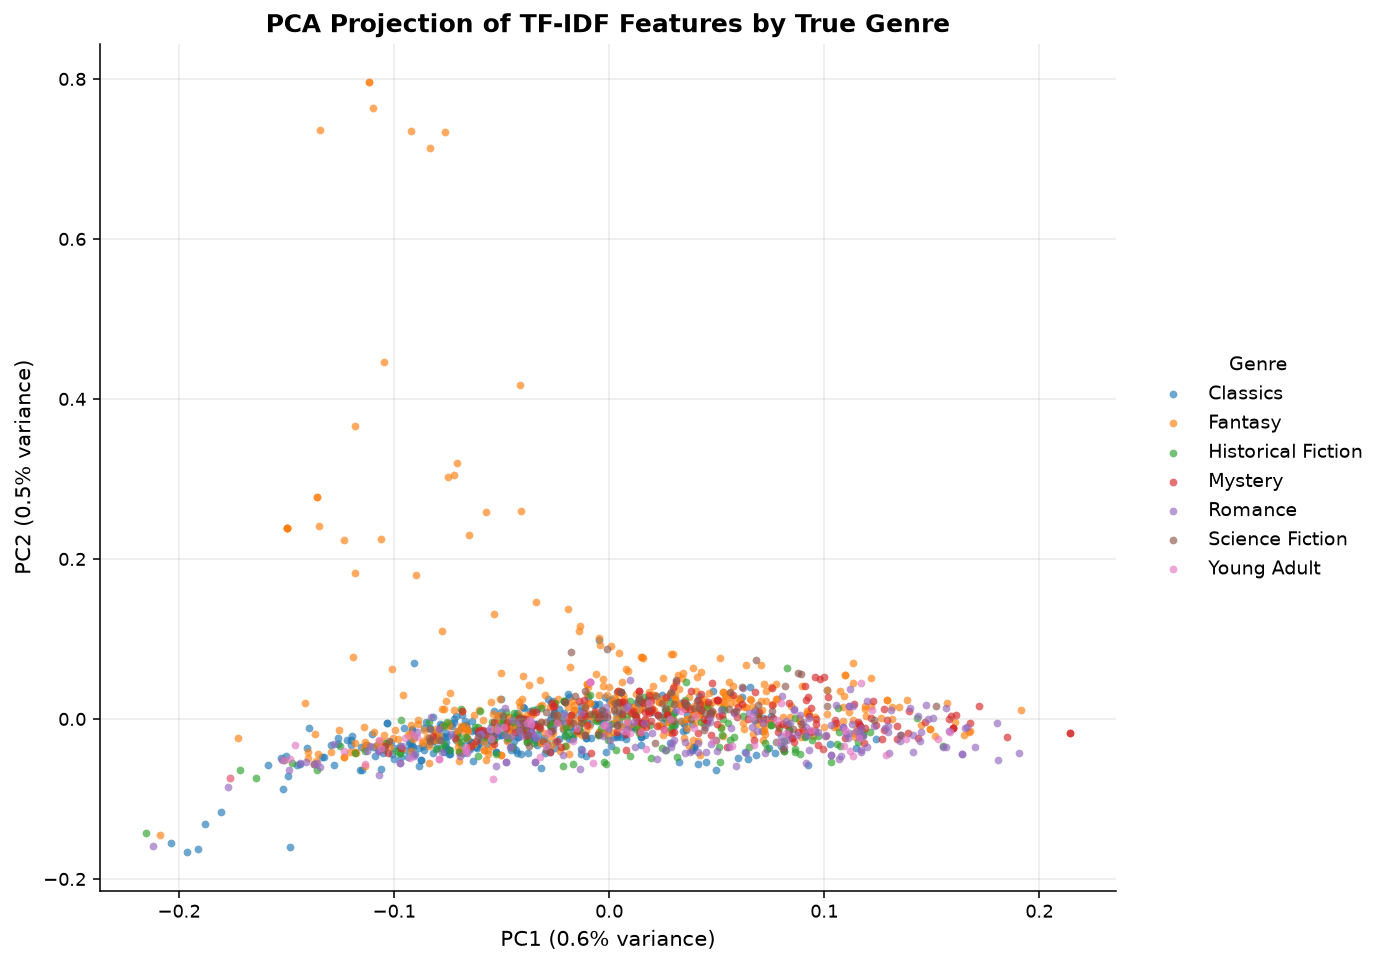

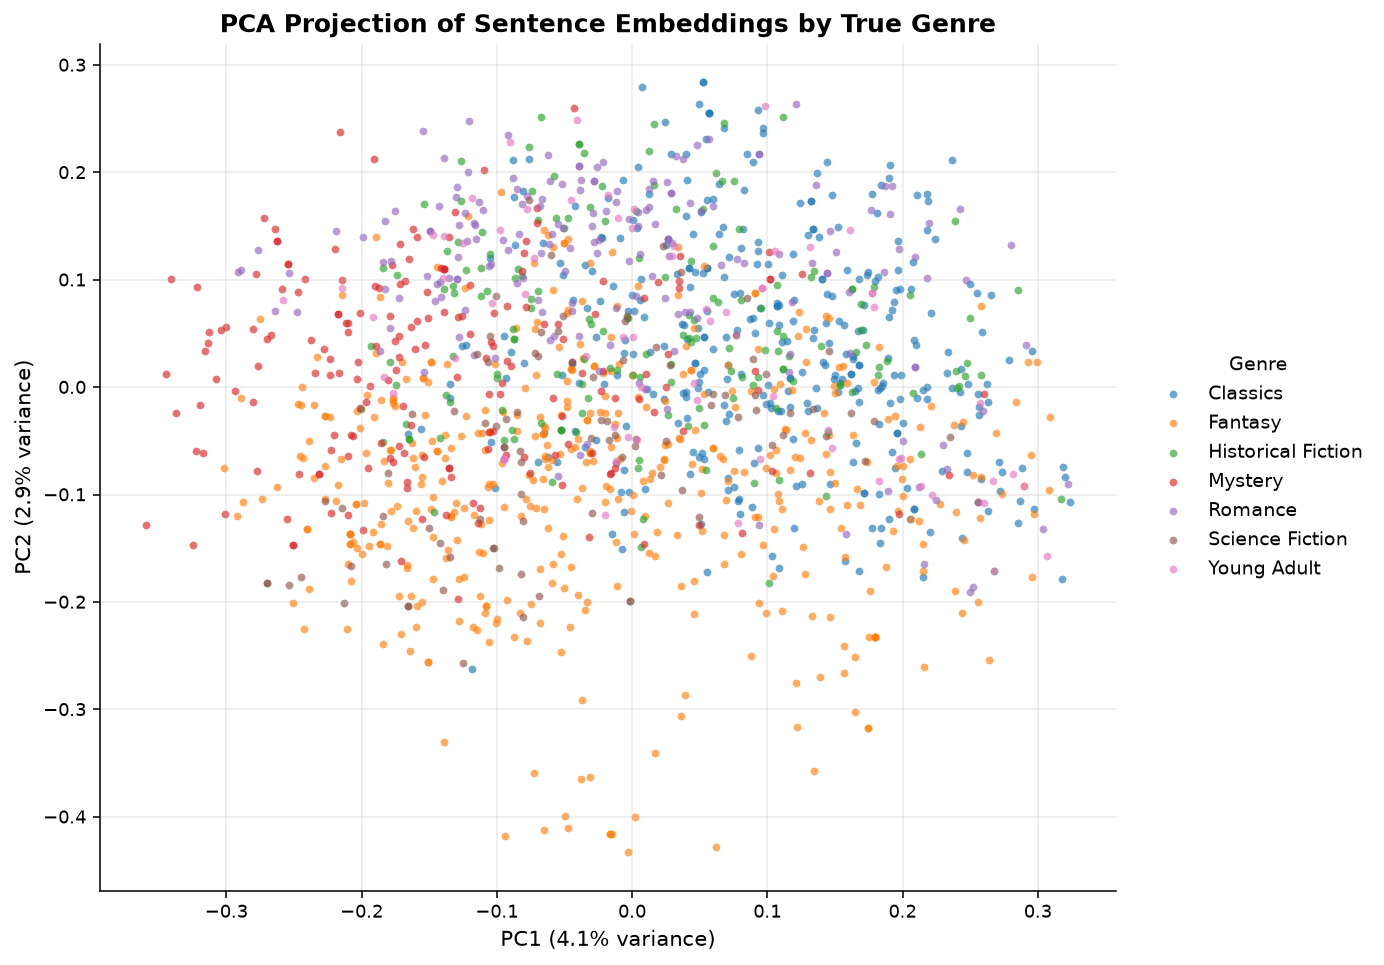

In [41]:
plot_pca_projection(
    X_cluster_tfidf_dense,
    y_cluster,
    class_names,
    title="PCA Projection of TF-IDF Features by True Genre",
    max_points=PCA_CLUSTER_MAX_POINTS,
    random_state=RANDOM_STATE,
)

plot_pca_projection(
    X_cluster_emb,
    y_cluster,
    class_names,
    title="PCA Projection of Sentence Embeddings by True Genre",
    max_points=PCA_CLUSTER_MAX_POINTS,
    random_state=RANDOM_STATE,
)


## 24. Clustering evaluation functions from scratch

Use internal metrics to evaluate the geometry of clusters and external metrics to compare clusters with true genres.


In [42]:
def pairwise_distance_matrix(X, metric="euclidean"):
    X = np.asarray(X, dtype=np.float32)

    if metric == "euclidean":
        sq_norms = np.sum(X ** 2, axis=1, keepdims=True)  # (n, 1)
        D2 = sq_norms + sq_norms.T - 2.0 * (X @ X.T)
        D2 = np.maximum(D2, 0.0)
        return np.sqrt(D2)

    if metric == "cosine":
        Xn = l2_normalize_rows(X)
        similarities = Xn @ Xn.T
        similarities = np.clip(similarities, -1.0, 1.0)
        D = 1.0 - similarities
        np.fill_diagonal(D, 0.0)
        return D

    raise ValueError(f"Unknown metric: {metric}")


def cluster_label_matrix(y_true, cluster_labels, ignore_noise=True):
    y_true = np.asarray(y_true)
    cluster_labels = np.asarray(cluster_labels)

    mask = np.ones(len(y_true), dtype=bool)
    if ignore_noise:
        mask = cluster_labels != -1

    y = y_true[mask]
    z = cluster_labels[mask]

    unique_clusters = np.array(sorted(set(z)))
    unique_classes = np.array(sorted(set(y)))

    matrix = np.zeros((len(unique_clusters), len(unique_classes)), dtype=int)
    cluster_to_row = {cluster: i for i, cluster in enumerate(unique_clusters)}
    class_to_col = {cls: j for j, cls in enumerate(unique_classes)}

    for cluster, cls in zip(z, y):
        matrix[cluster_to_row[cluster], class_to_col[cls]] += 1

    return matrix, unique_clusters, unique_classes


def purity_score_scratch(y_true, cluster_labels, ignore_noise=True):
    matrix, _, _ = cluster_label_matrix(y_true, cluster_labels, ignore_noise=ignore_noise)
    total = matrix.sum()

    if total == 0:
        return np.nan

    return float(matrix.max(axis=1).sum() / total)


def entropy_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()

    if total <= 0:
        return 0.0

    probs = counts[counts > 0] / total
    return float(-np.sum(probs * np.log(probs + 1e-12)))


def nmi_score_scratch(y_true, cluster_labels, ignore_noise=True):
    matrix, _, _ = cluster_label_matrix(y_true, cluster_labels, ignore_noise=ignore_noise)
    n = matrix.sum()

    if n == 0:
        return np.nan

    cluster_counts = matrix.sum(axis=1)  # shape (n_clusters,)
    class_counts = matrix.sum(axis=0)    # shape (n_classes,)

    mutual_info = 0.0
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            nij = matrix[i, j]
            if nij > 0:
                mutual_info += (nij / n) * np.log(
                    (n * nij) / (cluster_counts[i] * class_counts[j] + 1e-12)
                )

    h_clusters = entropy_from_counts(cluster_counts)
    h_classes = entropy_from_counts(class_counts)

    denominator = (h_clusters + h_classes) / 2.0
    if denominator <= 0:
        return np.nan

    return float(mutual_info / denominator)


def rand_index_scratch(y_true, cluster_labels, ignore_noise=True):
    y_true = np.asarray(y_true)
    cluster_labels = np.asarray(cluster_labels)

    mask = np.ones(len(y_true), dtype=bool)
    if ignore_noise:
        mask = cluster_labels != -1

    y = y_true[mask]
    z = cluster_labels[mask]
    n = len(y)

    if n < 2:
        return np.nan

    agree = 0
    total = 0

    for i in range(n):
        same_true = np.where(y[i+1:] == y[i])[0]
        same_cluster = np.where(z[i+1:] == z[i])[0]
        agree += len(set(same_true) & set(same_cluster)) + (
            (n - i - 1) - len(set(same_true) | set(same_cluster))
        )
        total += n - i - 1

    return float(agree / total)


def silhouette_score_scratch(X, cluster_labels, metric="euclidean", max_points=700, random_state=42, ignore_noise=True):
    labels = np.asarray(cluster_labels)
    valid_mask = np.ones(len(labels), dtype=bool)

    if ignore_noise:
        valid_mask = labels != -1

    valid_positions = np.where(valid_mask)[0]
    if len(valid_positions) < 3:
        return np.nan

    valid_labels = labels[valid_positions]
    unique_labels = np.unique(valid_labels)

    if len(unique_labels) < 2:
        return np.nan

    rng = np.random.default_rng(random_state)
    if len(valid_positions) > max_points:
        valid_positions = rng.choice(valid_positions, size=max_points, replace=False)
        valid_positions = np.sort(valid_positions)

    X_sample = np.asarray(X)[valid_positions]
    labels_sample = labels[valid_positions]

    unique_sample_labels = np.unique(labels_sample)
    if len(unique_sample_labels) < 2:
        return np.nan

    D = pairwise_distance_matrix(X_sample, metric=metric)

    silhouettes = []
    for i in range(len(X_sample)):
        own_label = labels_sample[i]
        own_mask = labels_sample == own_label

        if own_mask.sum() <= 1:
            silhouettes.append(0.0)
            continue

        a = D[i, own_mask].sum() / (own_mask.sum() - 1)

        b_values = []
        for other_label in unique_sample_labels:
            if other_label == own_label:
                continue
            other_mask = labels_sample == other_label
            b_values.append(D[i, other_mask].mean())

        b = min(b_values)
        silhouettes.append((b - a) / max(a, b, 1e-12))

    return float(np.mean(silhouettes))


def evaluate_clustering_run(y_true, cluster_labels, X_for_silhouette, silhouette_metric, random_state=42):
    labels = np.asarray(cluster_labels)
    non_noise_mask = labels != -1

    unique_non_noise = np.unique(labels[non_noise_mask])
    n_clusters = len(unique_non_noise)
    noise_ratio = float((~non_noise_mask).sum() / len(labels))

    return {
        "n_clusters": n_clusters,
        "noise_ratio": noise_ratio,
        "silhouette": silhouette_score_scratch(
            X_for_silhouette,
            labels,
            metric=silhouette_metric,
            max_points=SILHOUETTE_SAMPLE_SIZE,
            random_state=random_state,
            ignore_noise=True,
        ),
        "purity": purity_score_scratch(y_true, labels, ignore_noise=True),
        "nmi": nmi_score_scratch(y_true, labels, ignore_noise=True),
        "rand_index": rand_index_scratch(y_true, labels, ignore_noise=True),
    }


## 25. Plotting helpers for clustering


In [43]:
def plot_clustering_lines(results_df, metric, title):
    fig, ax = plt.subplots(figsize=(11, 6))

    grouped = results_df.groupby(["method", "representation", "k"], as_index=False)[metric].mean()
    grouped = grouped.dropna(subset=[metric])

    for (method, representation), group in grouped.groupby(["method", "representation"]):
        group = group.sort_values("k")
        ax.plot(
            group["k"],
            group[metric],
            marker="o",
            linewidth=2,
            label=f"{method} / {representation}",
        )

    ax.set_title(title)
    ax.set_xlabel("Number of clusters K")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_cluster_size_distribution(labels, title):
    labels = np.asarray(labels)
    counts = pd.Series(labels).value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(counts.index.astype(str), counts.values, edgecolor="black", linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel("Cluster label")
    ax.set_ylabel("Number of books")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


def plot_cluster_pca(X, cluster_labels, title, max_points=1500, random_state=42):
    X = np.asarray(X, dtype=np.float32)
    labels = np.asarray(cluster_labels)

    rng = np.random.default_rng(random_state)
    indices = np.arange(len(labels))

    if len(indices) > max_points:
        indices = rng.choice(indices, size=max_points, replace=False)
        indices = np.sort(indices)

    X_plot = X[indices]
    labels_plot = labels[indices]

    pca = PCA(n_components=2, random_state=random_state)
    coords = pca.fit_transform(X_plot)

    fig, ax = plt.subplots(figsize=(10, 7))

    unique_labels = np.array(sorted(pd.Series(labels_plot).unique()))
    for label in unique_labels:
        mask = labels_plot == label
        label_name = "noise" if label == -1 else f"cluster {label}"
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=18,
            alpha=0.72,
            label=label_name,
            edgecolors="none",
        )

    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.grid(True, alpha=0.25)

    if len(unique_labels) <= 20:
        ax.legend(loc="best", fontsize=8, markerscale=1.4)

    plt.tight_layout()
    plt.show()


def plot_cluster_genre_heatmap(y_true, cluster_labels, title, ignore_noise=True):
    matrix, cluster_values, class_values = cluster_label_matrix(
        y_true,
        cluster_labels,
        ignore_noise=ignore_noise,
    )

    if matrix.size == 0:
        print("No non-noise clusters to visualize.")
        return

    class_labels = label_encoder.classes_[class_values]
    cluster_labels_display = [f"cluster {c}" for c in cluster_values]

    matrix_df = pd.DataFrame(matrix, index=cluster_labels_display, columns=class_labels)
    row_sums = matrix_df.sum(axis=1).replace(0, 1)
    normalized_df = matrix_df.div(row_sums, axis=0)

    plot_metric_heatmap(
        normalized_df,
        title=title,
        xlabel="True genre",
        ylabel="Cluster",
        value_format=".2f",
    )


def plot_final_clustering_comparison(results_df, metric, title):
    plot_df = (
        results_df
        .dropna(subset=[metric])
        .sort_values(metric, ascending=False)
        .groupby(["method", "representation"], as_index=False)
        .head(1)
        .copy()
    )

    plot_df["label"] = plot_df["method"] + "\n" + plot_df["representation"]
    plot_df = plot_df.sort_values(metric)

    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.barh(plot_df["label"], plot_df[metric], edgecolor="black", linewidth=0.6)

    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("Best run for each method/representation")
    ax.grid(axis="x", alpha=0.25)

    max_value = plot_df[metric].max()
    for bar in bars:
        width = bar.get_width()
        ax.text(width + max_value * 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()


## 26. K-Means from scratch

Implement standard K-Means and test several values of `K`.


In [44]:
class ScratchKMeans:
    def __init__(self, n_clusters, max_iter=40, tol=1e-4, random_state=42):
        self.n_clusters = int(n_clusters)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.random_state = random_state

    def _initialize_centroids(self, X):
        rng = np.random.default_rng(self.random_state)
        chosen = rng.choice(np.arange(X.shape[0]), size=self.n_clusters, replace=False)
        return X[chosen].copy()

    def _squared_distances(self, X, centroids):
        x_norms = np.sum(X ** 2, axis=1, keepdims=True)       # (n, 1)
        c_norms = np.sum(centroids ** 2, axis=1, keepdims=True)  # (k, 1)
        distances = x_norms + c_norms.T - 2.0 * (X @ centroids.T)
        return np.maximum(distances, 0.0)

    def fit(self, X):
        X = np.asarray(X, dtype=np.float32)
        n_samples = X.shape[0]

        if self.n_clusters < 2:
            raise ValueError("n_clusters must be at least 2.")
        if self.n_clusters > n_samples:
            raise ValueError("n_clusters cannot be larger than the number of samples.")

        centroids = self._initialize_centroids(X)
        previous_inertia = np.inf

        for iteration in range(self.max_iter):
            distances = self._squared_distances(X, centroids)
            labels = np.argmin(distances, axis=1)
            inertia = float(distances[np.arange(n_samples), labels].sum())

            new_centroids = np.zeros_like(centroids)
            for cluster_id in range(self.n_clusters):
                mask = labels == cluster_id
                if mask.any():
                    new_centroids[cluster_id] = X[mask].mean(axis=0)
                else:
                    new_centroids[cluster_id] = X[np.random.default_rng(self.random_state + iteration).integers(0, n_samples)]

            centroid_shift = float(np.linalg.norm(new_centroids - centroids))
            centroids = new_centroids

            if abs(previous_inertia - inertia) < self.tol or centroid_shift < self.tol:
                break

            previous_inertia = inertia

        self.cluster_centers_ = centroids
        self.labels_ = labels
        self.inertia_ = inertia
        self.n_iter_ = iteration + 1
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        distances = self._squared_distances(X, self.cluster_centers_)
        return np.argmin(distances, axis=1)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_


In [45]:
clustering_assignments = {}
kmeans_rows = []

valid_k_values = [k for k in K_VALUES if k >= 2]

for representation_name, X_current in CLUSTER_REPRESENTATIONS.items():
    for k in valid_k_values:
        for seed in CLUSTER_RANDOM_SEEDS:
            start_time = time.time()

            model = ScratchKMeans(
                n_clusters=k,
                max_iter=KMEANS_MAX_ITER,
                tol=KMEANS_TOL,
                random_state=seed,
            )

            labels = model.fit_predict(X_current)
            seconds = time.time() - start_time

            metrics = evaluate_clustering_run(
                y_cluster,
                labels,
                X_current,
                silhouette_metric="euclidean",
                random_state=seed,
            )

            run_key = f"K-Means | {representation_name} | K={k} | seed={seed}"
            clustering_assignments[run_key] = {
                "labels": labels,
                "positions": np.arange(len(df_cluster)),
                "representation": representation_name,
                "method": "K-Means",
                "k": k,
                "seed": seed,
            }

            kmeans_rows.append({
                "run_key": run_key,
                "method": "K-Means",
                "representation": representation_name,
                "k": k,
                "seed": seed,
                "eps": np.nan,
                "min_samples": np.nan,
                "linkage": "",
                "seconds": seconds,
                "inertia": model.inertia_,
                **metrics,
            })

kmeans_results_df = pd.DataFrame(kmeans_rows)
display(kmeans_results_df.sort_values(["representation", "k", "seed"]).head(20))


,run_key,method,representation,k,seed,eps,min_samples,linkage,seconds,inertia,n_clusters,noise_ratio,silhouette,purity,nmi,rand_index
10,K-Means | Sentence embedding | K=5 | seed=42,K-Means,Sentence embedding,5,42,NaN,NaN,,0.084430,940.183960,5,0.0,0.023855,0.4625,0.189570,0.722313
11,K-Means | Sentence embedding | K=5 | seed=43,K-Means,Sentence embedding,5,43,NaN,NaN,,0.095321,943.253967,5,0.0,0.017539,0.4125,0.150259,0.712268
12,K-Means | Sentence embedding | K=7 | seed=42,K-Means,Sentence embedding,7,42,NaN,NaN,,0.163596,923.784607,7,0.0,0.023574,0.4920,0.209171,0.746992
13,K-Means | Sentence embedding | K=7 | seed=43,K-Means,Sentence embedding,7,43,NaN,NaN,,0.216568,925.261353,7,0.0,0.021705,0.4525,0.189019,0.740114
14,K-Means | Sentence embedding | K=10 | seed=42,K-Means,Sentence embedding,10,42,NaN,NaN,,0.084907,913.210693,10,0.0,0.022001,0.4870,0.206123,0.761971
15,K-Means | Sentence embedding | K=10 | seed=43,K-Means,Sentence embedding,10,43,NaN,NaN,,0.204528,909.693604,10,0.0,0.021180,0.4985,0.205130,0.768486
16,K-Means | Sentence embedding | K=15 | seed=42,K-Means,Sentence embedding,15,42,NaN,NaN,,0.106248,885.751099,15,0.0,0.027517,0.5340,0.237894,0.788909
17,K-Means | Sentence embedding | K=15 | seed=43,K-Means,Sentence embedding,15,43,NaN,NaN,,0.109572,886.354919,15,0.0,0.021970,0.5080,0.223327,0.784231
18,K-Means | Sentence embedding | K=20 | seed=42,K-Means,Sentence embedding,20,42,NaN,NaN,,0.117687,877.663879,20,0.0,0.025476,0.5295,0.237629,0.793579
19,K-Means | Sentence embedding | K=20 | seed=43,K-Means,Sentence embedding,20,43,NaN,NaN,,0.104682,874.579773,20,0.0,0.021259,0.5505,0.256701,0.798883


### K-Means visual comparison


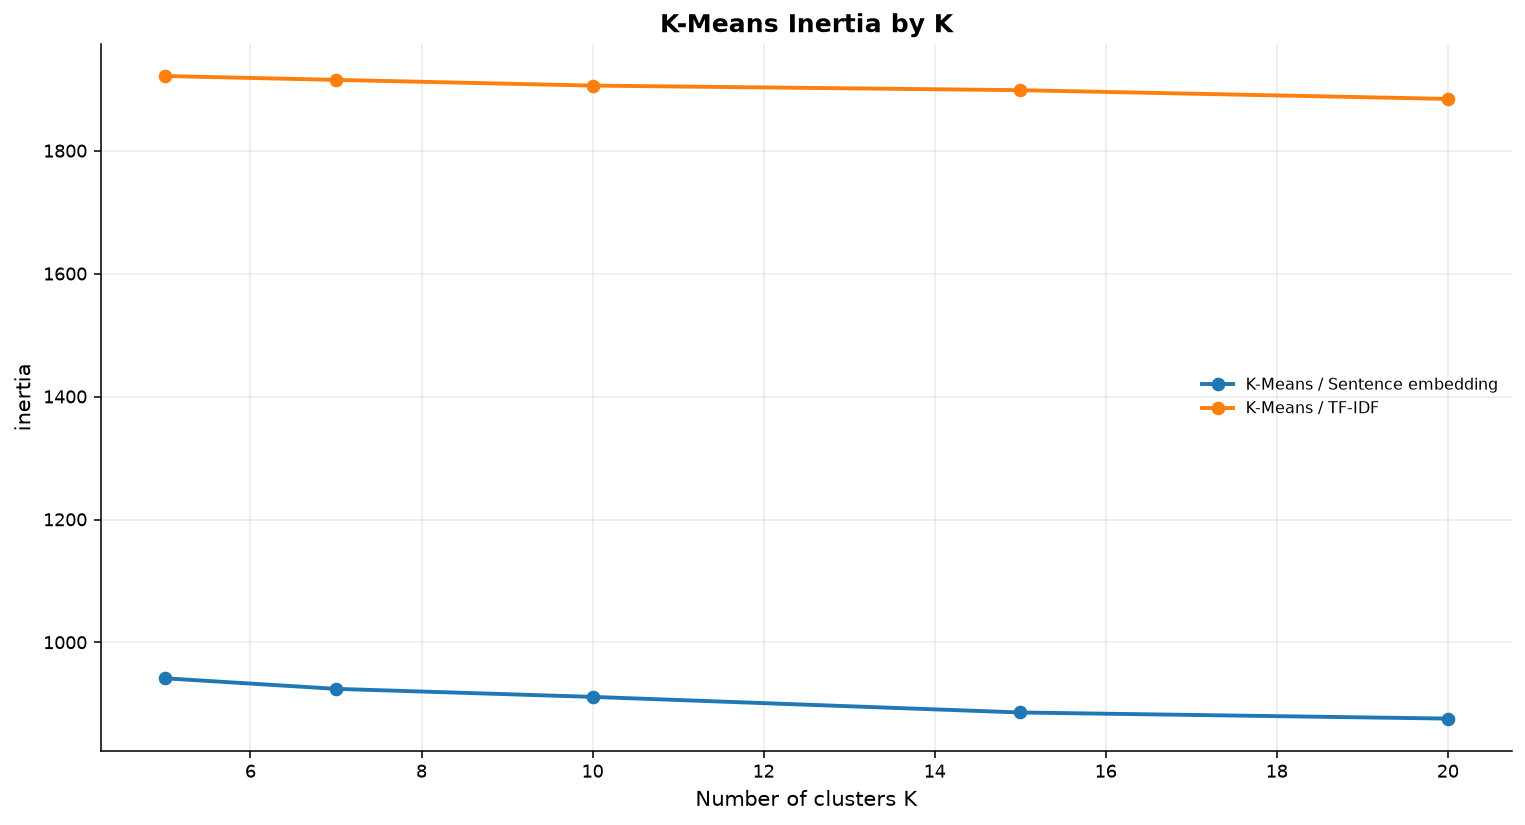

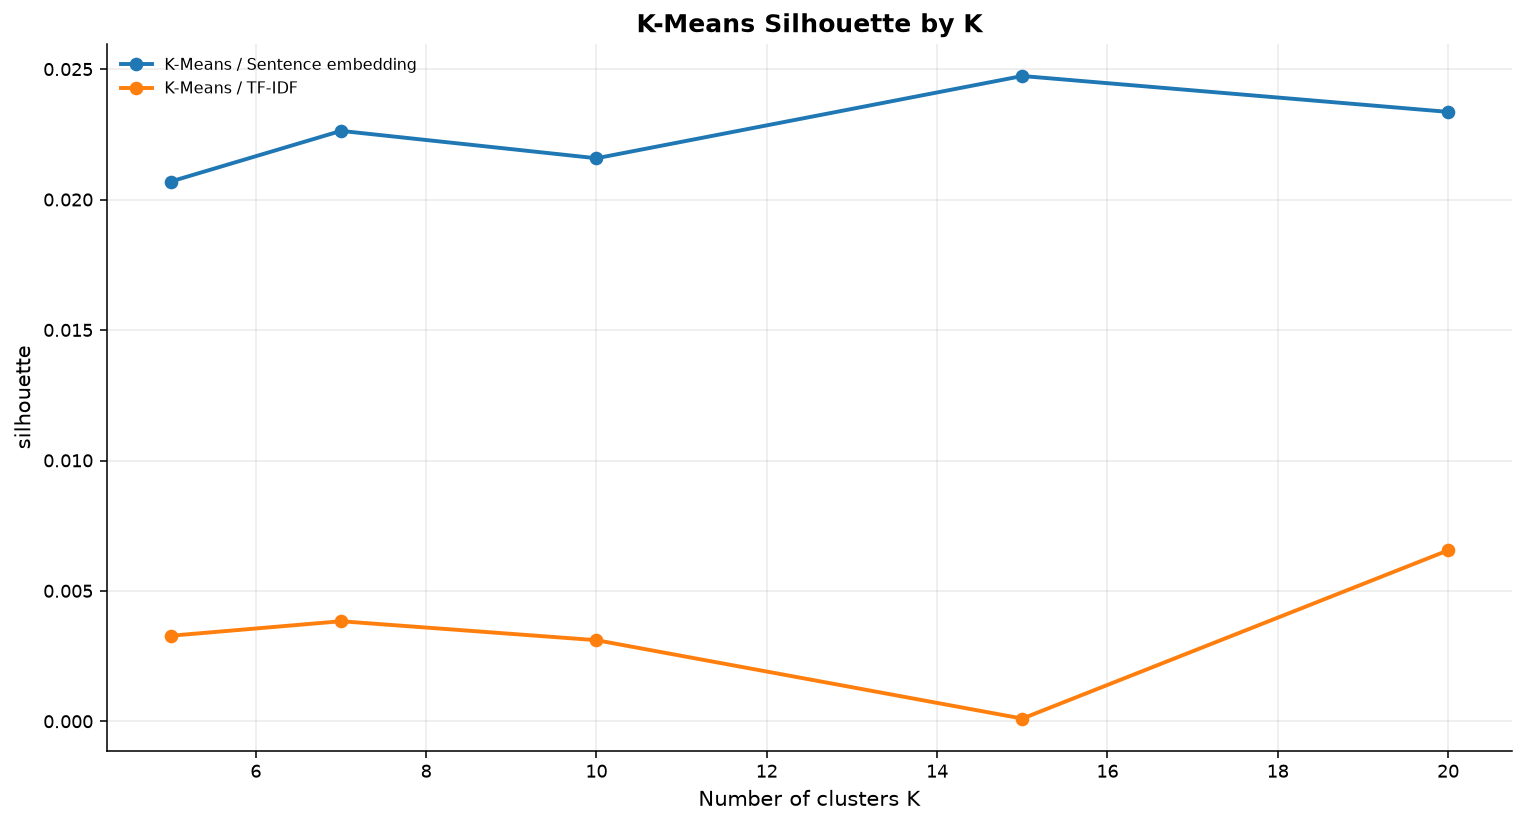

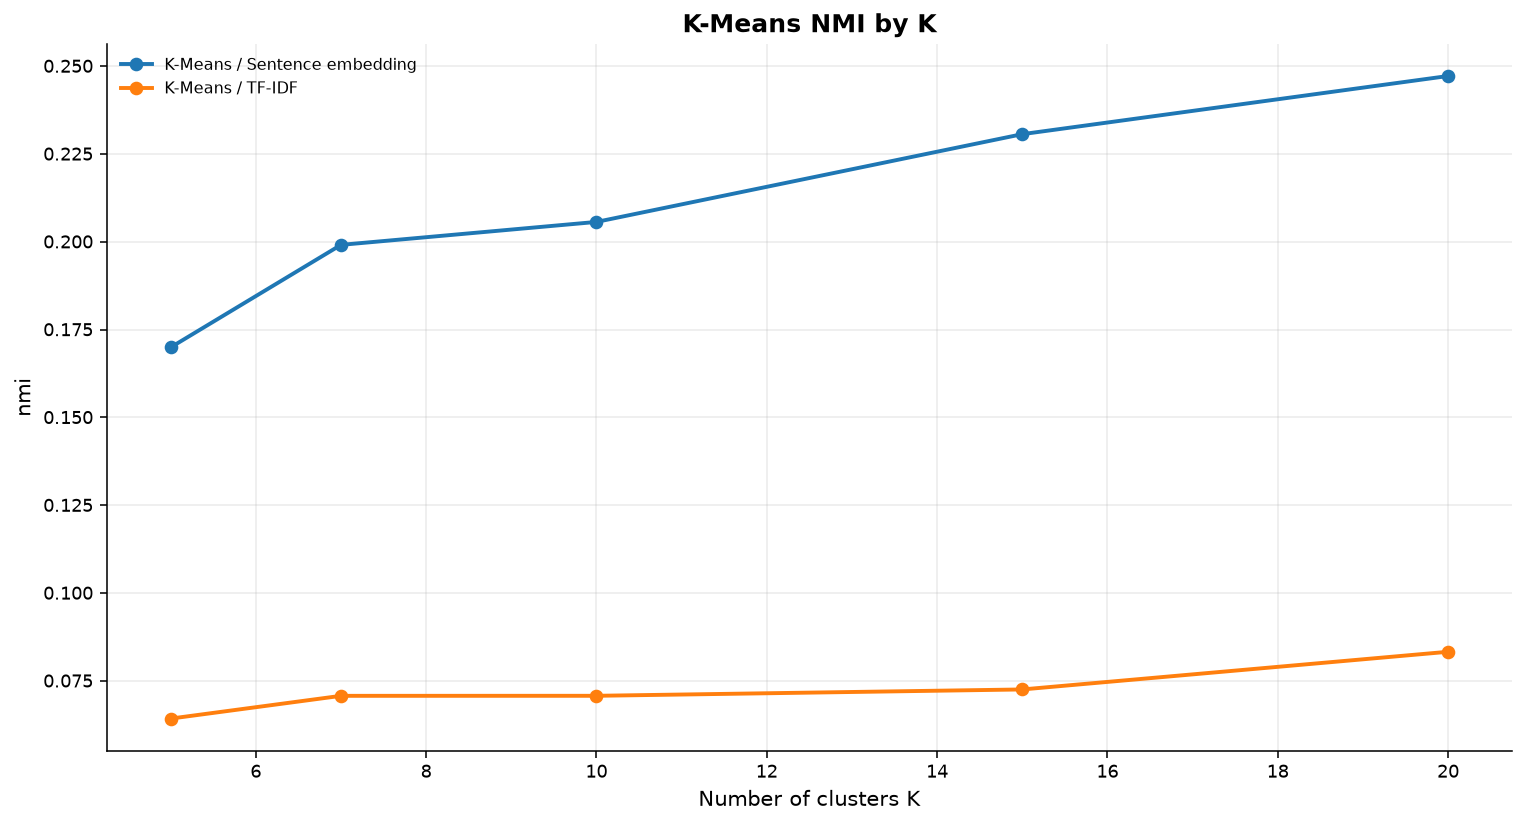

In [46]:
plot_clustering_lines(
    kmeans_results_df,
    metric="inertia",
    title="K-Means Inertia by K",
)

plot_clustering_lines(
    kmeans_results_df,
    metric="silhouette",
    title="K-Means Silhouette by K",
)

plot_clustering_lines(
    kmeans_results_df,
    metric="nmi",
    title="K-Means NMI by K",
)


**TODO:** Which `K` gives the best internal score? Which `K` gives the best agreement with the true genres?


### 1. Best Internal Score

- For sentence embedding as we can see K=15.
- for TD-IDF K=20 yields the best results.


### 2. Best Agreement with True Genres

- NMI increases rather monotonicly. but this is artifitially true.This happens because the more the clusters the easier we can assign a datapoint to a cluster. But we only have 10 True-Genres so maybe K=10 is the best choice internally.


## 27. Spherical K-Means from scratch

Spherical K-Means normalizes vectors and assigns documents by cosine similarity. This is often more appropriate for text data.


In [47]:
class ScratchSphericalKMeans:
    def __init__(self, n_clusters, max_iter=40, tol=1e-4, random_state=42):
        self.n_clusters = int(n_clusters)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.random_state = random_state

    def _initialize_centroids(self, X):
        rng = np.random.default_rng(self.random_state)
        chosen = rng.choice(np.arange(X.shape[0]), size=self.n_clusters, replace=False)
        centroids = X[chosen].copy()
        return l2_normalize_rows(centroids)

    def fit(self, X):
        X = l2_normalize_rows(np.asarray(X, dtype=np.float32))
        n_samples = X.shape[0]

        if self.n_clusters < 2:
            raise ValueError("n_clusters must be at least 2.")
        if self.n_clusters > n_samples:
            raise ValueError("n_clusters cannot be larger than the number of samples.")

        centroids = self._initialize_centroids(X)
        previous_cost = np.inf

        for iteration in range(self.max_iter):
            similarities = X @ centroids.T          # (n, k)
            labels = np.argmax(similarities, axis=1)
            max_similarities = similarities[np.arange(n_samples), labels]
            cost = float(np.sum(1.0 - max_similarities))

            new_centroids = centroids.copy()
            for cluster_id in range(self.n_clusters):
                mask = labels == cluster_id
                if mask.any():
                    new_centroids[cluster_id] = X[mask].mean(axis=0)
                else:
                    new_centroids[cluster_id] = X[np.random.default_rng(self.random_state + iteration).integers(0, n_samples)]

            new_centroids = l2_normalize_rows(new_centroids)
            centroid_shift = float(np.linalg.norm(new_centroids - centroids))
            centroids = new_centroids

            if abs(previous_cost - cost) < self.tol or centroid_shift < self.tol:
                break

            previous_cost = cost

        self.cluster_centers_ = centroids
        self.labels_ = labels
        self.inertia_ = cost
        self.n_iter_ = iteration + 1
        return self

    def predict(self, X):
        X = l2_normalize_rows(np.asarray(X, dtype=np.float32))
        similarities = X @ self.cluster_centers_.T
        return np.argmax(similarities, axis=1)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_


In [48]:
spherical_rows = []

for representation_name, X_current in CLUSTER_REPRESENTATIONS.items():
    for k in valid_k_values:
        for seed in CLUSTER_RANDOM_SEEDS:
            start_time = time.time()

            model = ScratchSphericalKMeans(
                n_clusters=k,
                max_iter=KMEANS_MAX_ITER,
                tol=KMEANS_TOL,
                random_state=seed,
            )

            labels = model.fit_predict(X_current)
            seconds = time.time() - start_time

            metrics = evaluate_clustering_run(
                y_cluster,
                labels,
                X_current,
                silhouette_metric="cosine",
                random_state=seed,
            )

            run_key = f"Spherical K-Means | {representation_name} | K={k} | seed={seed}"
            clustering_assignments[run_key] = {
                "labels": labels,
                "positions": np.arange(len(df_cluster)),
                "representation": representation_name,
                "method": "Spherical K-Means",
                "k": k,
                "seed": seed,
            }

            spherical_rows.append({
                "run_key": run_key,
                "method": "Spherical K-Means",
                "representation": representation_name,
                "k": k,
                "seed": seed,
                "eps": np.nan,
                "min_samples": np.nan,
                "linkage": "",
                "seconds": seconds,
                "inertia": model.inertia_,
                **metrics,
            })

spherical_results_df = pd.DataFrame(spherical_rows)
display(spherical_results_df.sort_values(["representation", "k", "seed"]).head(20))


,run_key,method,representation,k,seed,eps,min_samples,linkage,seconds,inertia,n_clusters,noise_ratio,silhouette,purity,nmi,rand_index
10,Spherical K-Means | Sentence embedding | K=5 |...,Spherical K-Means,Sentence embedding,5,42,NaN,NaN,,0.064400,544.083862,5,0.0,0.044752,0.4700,0.195950,0.725212
11,Spherical K-Means | Sentence embedding | K=5 |...,Spherical K-Means,Sentence embedding,5,43,NaN,NaN,,0.063019,546.230835,5,0.0,0.034197,0.4115,0.149239,0.712286
12,Spherical K-Means | Sentence embedding | K=7 |...,Spherical K-Means,Sentence embedding,7,42,NaN,NaN,,0.081043,533.205444,7,0.0,0.044976,0.4965,0.215960,0.748540
13,Spherical K-Means | Sentence embedding | K=7 |...,Spherical K-Means,Sentence embedding,7,43,NaN,NaN,,0.100280,534.497314,7,0.0,0.038778,0.4395,0.188686,0.738422
14,Spherical K-Means | Sentence embedding | K=10 ...,Spherical K-Means,Sentence embedding,10,42,NaN,NaN,,0.048360,525.813904,10,0.0,0.040709,0.4815,0.202230,0.762023
15,Spherical K-Means | Sentence embedding | K=10 ...,Spherical K-Means,Sentence embedding,10,43,NaN,NaN,,0.077109,523.530823,10,0.0,0.040903,0.5075,0.206397,0.771224
16,Spherical K-Means | Sentence embedding | K=15 ...,Spherical K-Means,Sentence embedding,15,42,NaN,NaN,,0.060585,507.683838,15,0.0,0.049396,0.5275,0.234427,0.788036
17,Spherical K-Means | Sentence embedding | K=15 ...,Spherical K-Means,Sentence embedding,15,43,NaN,NaN,,0.056984,507.811279,15,0.0,0.041767,0.5075,0.222404,0.784788
18,Spherical K-Means | Sentence embedding | K=20 ...,Spherical K-Means,Sentence embedding,20,42,NaN,NaN,,0.042701,502.148651,20,0.0,0.044838,0.5240,0.235078,0.793406
19,Spherical K-Means | Sentence embedding | K=20 ...,Spherical K-Means,Sentence embedding,20,43,NaN,NaN,,0.040336,501.132629,20,0.0,0.038220,0.5290,0.246785,0.797437


### K-Means vs. Spherical K-Means


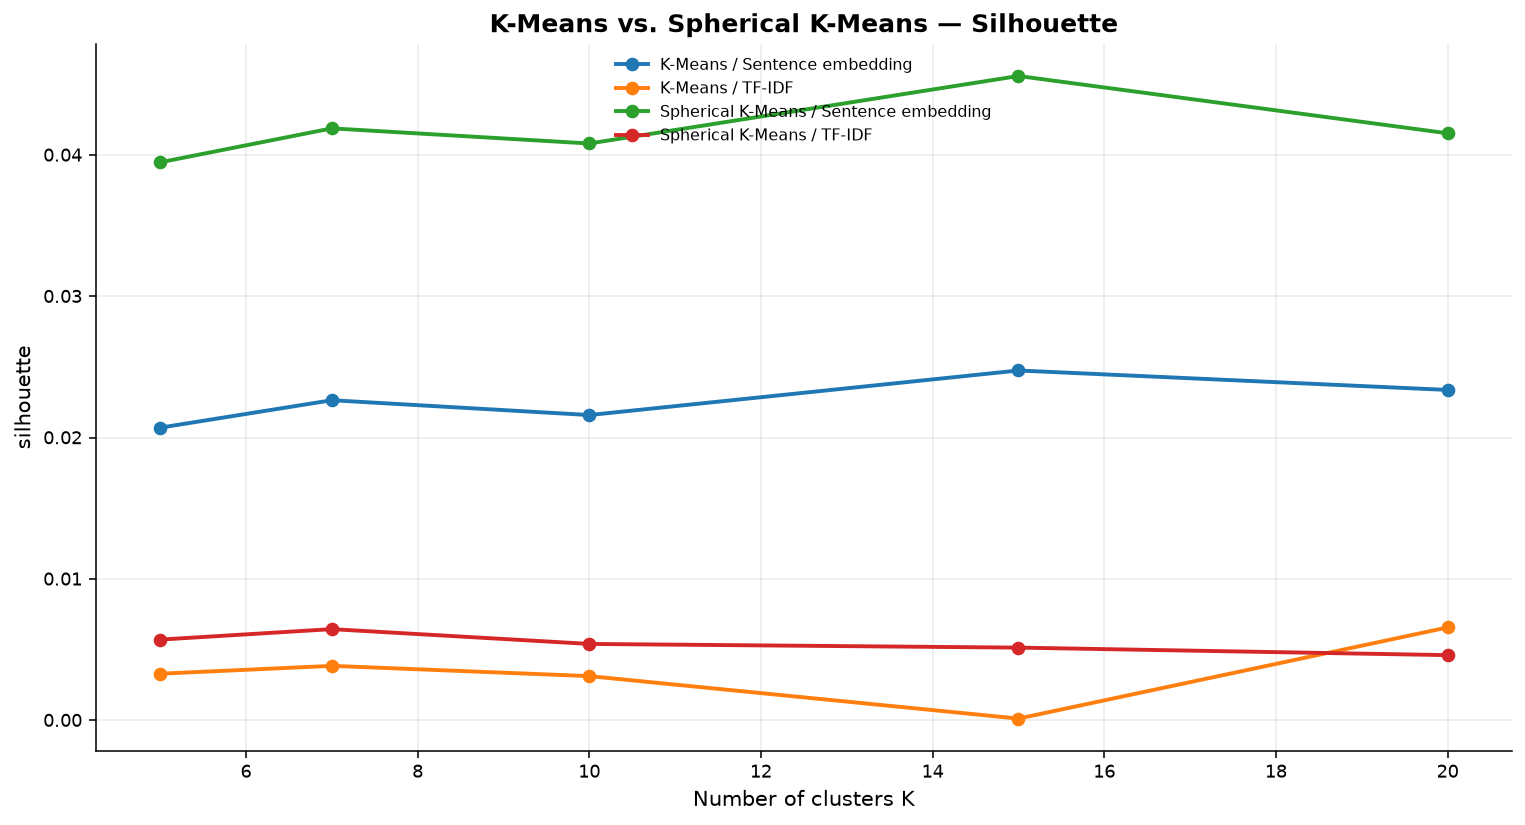

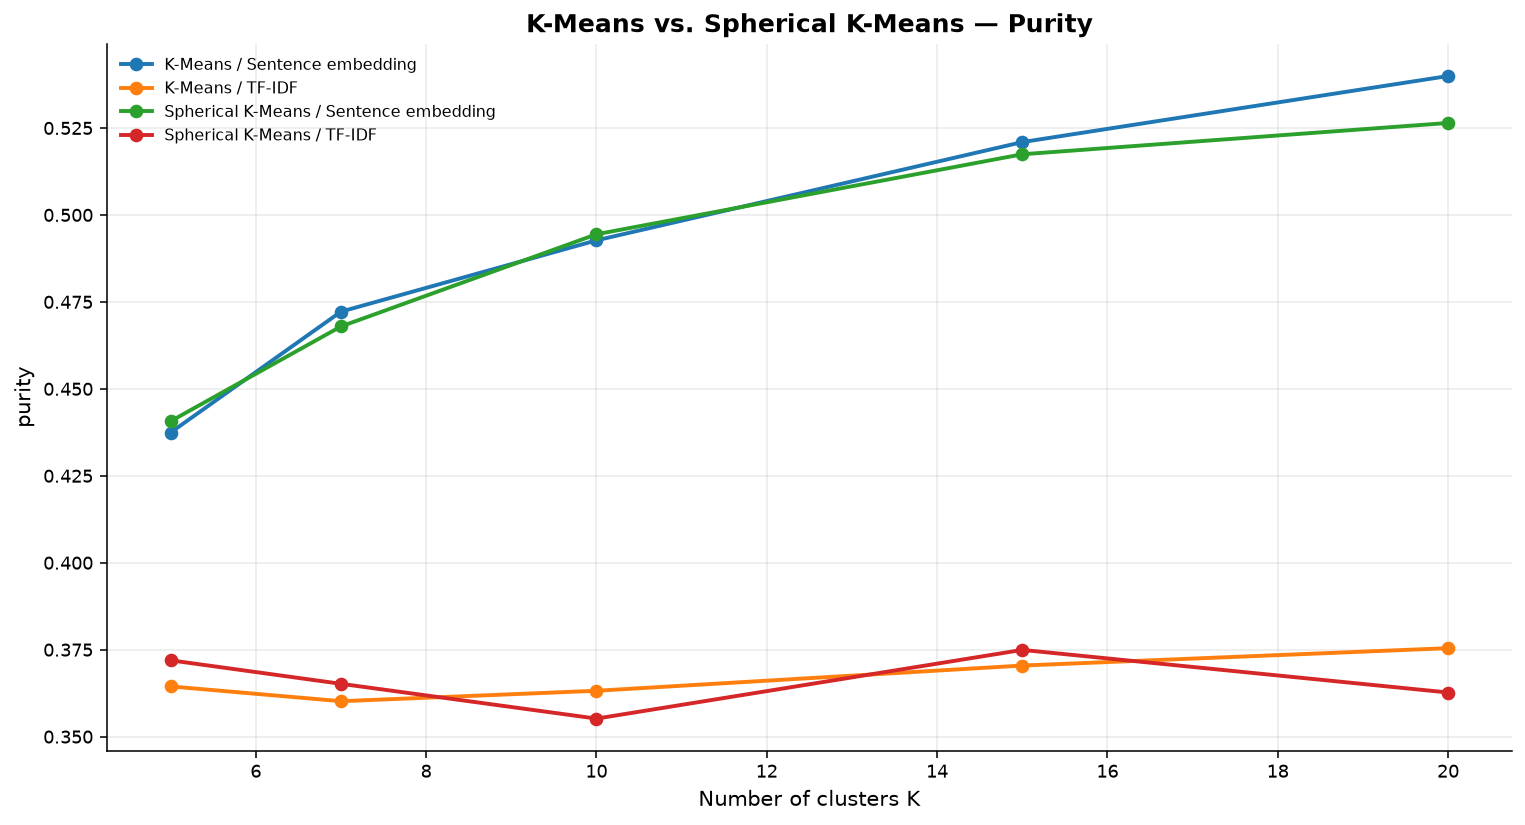

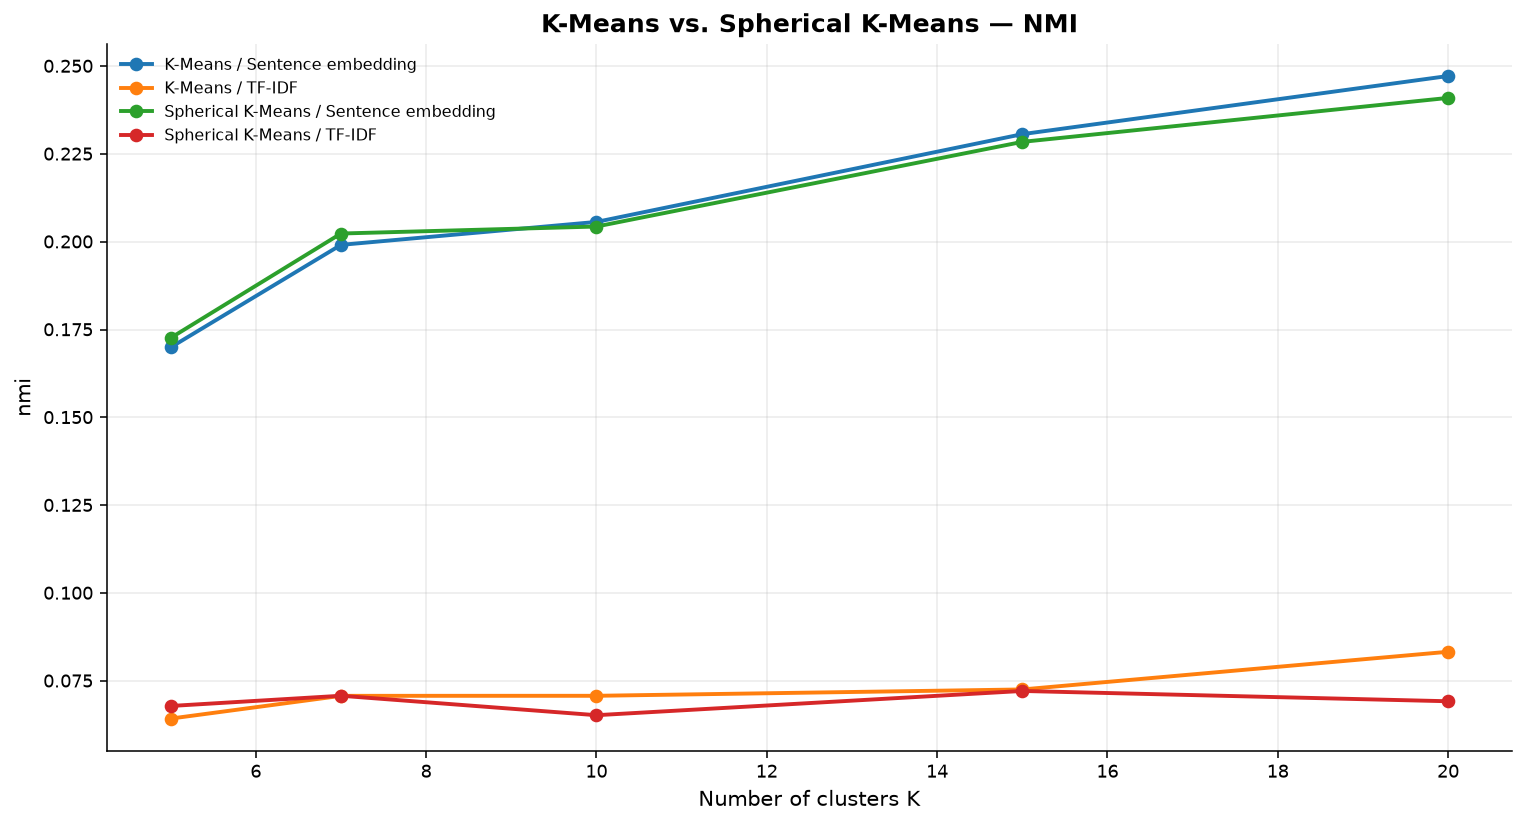

In [49]:
kmeans_family_results_df = pd.concat(
    [kmeans_results_df, spherical_results_df],
    ignore_index=True,
)

plot_clustering_lines(
    kmeans_family_results_df,
    metric="silhouette",
    title="K-Means vs. Spherical K-Means — Silhouette",
)

plot_clustering_lines(
    kmeans_family_results_df,
    metric="purity",
    title="K-Means vs. Spherical K-Means — Purity",
)

plot_clustering_lines(
    kmeans_family_results_df,
    metric="nmi",
    title="K-Means vs. Spherical K-Means — NMI",
)


**TODO:** Does cosine-based clustering work better than Euclidean clustering? Is the difference larger for TF-IDF or sentence embeddings?


#### Does cosine-based clustering work better than Euclidean clustering?

Yes. But only only on the internal metric. On silhouette, Spherical K-Means / sentence embedding dominates other clustering algorithms. almost 2 times better than  K-Means / sentence embedding.

#### Is the difference larger for TF-IDF or sentence embeddings?

Larger for sentence embeddings. 

## 28. DBSCAN from scratch

DBSCAN does not require a predefined number of clusters. It can also mark books as noise.


In [ ]:
def dbscan_from_distance_matrix(D, eps, min_samples):
    D = np.asarray(D, dtype=np.float32)
    n = D.shape[0]

    UNVISITED = -2
    NOISE = -1

    labels = np.full(n, UNVISITED, dtype=int)
    neighbors = [np.where(D[i] <= eps)[0].tolist() for i in range(n)]

    cluster_id = 0

    for point in range(n):
        if labels[point] != UNVISITED:
            continue

        point_neighbors = neighbors[point]

        if len(point_neighbors) < min_samples:
            labels[point] = NOISE
            continue

        labels[point] = cluster_id

        seeds = list(point_neighbors)
        seed_set = set(seeds)

        i = 0
        while i < len(seeds):
            neighbor = seeds[i]

            if labels[neighbor] == NOISE:
                labels[neighbor] = cluster_id

            if labels[neighbor] != UNVISITED:
                i += 1
                continue

            labels[neighbor] = cluster_id
            neighbor_neighbors = neighbors[neighbor]

            if len(neighbor_neighbors) >= min_samples:
                for candidate in neighbor_neighbors:
                    if candidate not in seed_set:
                        seeds.append(candidate)
                        seed_set.add(candidate)

            i += 1

        cluster_id += 1

    labels[labels == UNVISITED] = NOISE
    return labels


DBSCAN_MAX_NOISE_RATIO_FOR_SCORING = 0.50


def evaluate_dbscan_run(
    y_true,
    labels,
    X,
    silhouette_metric="cosine",
    random_state=RANDOM_STATE,
    max_noise_ratio=DBSCAN_MAX_NOISE_RATIO_FOR_SCORING,
):
    labels = np.asarray(labels)
    y_true = np.asarray(y_true)

    non_noise_mask = labels != -1
    clustered_count = int(non_noise_mask.sum())
    noise_ratio = 1.0 - (clustered_count / len(labels))

    non_noise_labels = labels[non_noise_mask]
    n_clusters = len(set(non_noise_labels))

    # DBSCAN can produce degenerate outputs:
    # - everything is noise
    # - only one real cluster
    # - too many points are noise
    # These cases should not receive a strong NMI/purity score.
    if n_clusters < 2 or clustered_count < 2 or noise_ratio > max_noise_ratio:
        return {
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "clustered_points": clustered_count,
            "valid_dbscan_score": False,
            "purity": np.nan,
            "nmi": np.nan,
            "silhouette": np.nan,
        }

    X_eval = X[non_noise_mask]
    y_eval = y_true[non_noise_mask]
    labels_eval = labels[non_noise_mask]

    metrics = evaluate_clustering_run(
        y_eval,
        labels_eval,
        X_eval,
        silhouette_metric=silhouette_metric,
        random_state=random_state,
    )

    metrics["n_clusters"] = n_clusters
    metrics["noise_ratio"] = noise_ratio
    metrics["clustered_points"] = clustered_count
    metrics["valid_dbscan_score"] = True

    return metrics


In [51]:
dbscan_sample_size = min(DBSCAN_SAMPLE_SIZE, len(df_cluster))
dbscan_positions = rng.choice(
    np.arange(len(df_cluster)),
    size=dbscan_sample_size,
    replace=False,
)
dbscan_positions = np.sort(dbscan_positions)

dbscan_rows = []

for representation_name in ["TF-IDF", "Sentence embedding"]:
    X_dbscan = CLUSTER_REPRESENTATIONS[representation_name][dbscan_positions]
    y_dbscan = y_cluster[dbscan_positions]

    print(f"Computing DBSCAN distance matrix for {representation_name}...")
    D_dbscan = pairwise_distance_matrix(X_dbscan, metric="cosine")

    for eps in DBSCAN_EPS_GRID[representation_name]:
        for min_samples in DBSCAN_MIN_SAMPLES_VALUES:
            start_time = time.time()

            labels = dbscan_from_distance_matrix(
                D_dbscan,
                eps=eps,
                min_samples=min_samples,
            )

            seconds = time.time() - start_time

            metrics = evaluate_dbscan_run(
                y_dbscan,
                labels,
                X_dbscan,
                silhouette_metric="cosine",
                random_state=RANDOM_STATE,
            )

            run_key = (
                f"DBSCAN | {representation_name} | "
                f"eps={eps} | min_samples={min_samples}"
            )

            clustering_assignments[run_key] = {
                "labels": labels,
                "positions": dbscan_positions,
                "representation": representation_name,
                "method": "DBSCAN",
                "eps": eps,
                "min_samples": min_samples,
            }

            dbscan_rows.append({
                "run_key": run_key,
                "method": "DBSCAN",
                "representation": representation_name,
                "k": np.nan,
                "seed": np.nan,
                "eps": eps,
                "min_samples": min_samples,
                "linkage": "",
                "seconds": seconds,
                "inertia": np.nan,
                **metrics,
            })

dbscan_results_df = pd.DataFrame(dbscan_rows)

display(
    dbscan_results_df
    .sort_values(["representation", "eps", "min_samples"])
    .reset_index(drop=True)
)


Computing DBSCAN distance matrix for TF-IDF...
Computing DBSCAN distance matrix for Sentence embedding...


,run_key,method,representation,k,seed,eps,min_samples,linkage,seconds,inertia,n_clusters,noise_ratio,clustered_points,valid_dbscan_score,purity,nmi,silhouette,rand_index
0,DBSCAN | Sentence embedding | eps=0.15 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.15,5,,0.001998,NaN,1,0.99375,5,False,NaN,NaN,NaN,NaN
1,DBSCAN | Sentence embedding | eps=0.15 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.15,10,,0.002001,NaN,0,1.00000,0,False,NaN,NaN,NaN,NaN
2,DBSCAN | Sentence embedding | eps=0.2 | min_sa...,DBSCAN,Sentence embedding,NaN,NaN,0.20,5,,0.002003,NaN,2,0.98250,14,False,NaN,NaN,NaN,NaN
3,DBSCAN | Sentence embedding | eps=0.2 | min_sa...,DBSCAN,Sentence embedding,NaN,NaN,0.20,10,,0.001000,NaN,0,1.00000,0,False,NaN,NaN,NaN,NaN
4,DBSCAN | Sentence embedding | eps=0.25 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.25,5,,0.002000,NaN,4,0.96000,32,False,NaN,NaN,NaN,NaN
5,DBSCAN | Sentence embedding | eps=0.25 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.25,10,,0.001001,NaN,0,1.00000,0,False,NaN,NaN,NaN,NaN
6,DBSCAN | Sentence embedding | eps=0.3 | min_sa...,DBSCAN,Sentence embedding,NaN,NaN,0.30,5,,0.002000,NaN,11,0.78500,172,False,NaN,NaN,NaN,NaN
7,DBSCAN | Sentence embedding | eps=0.3 | min_sa...,DBSCAN,Sentence embedding,NaN,NaN,0.30,10,,0.001999,NaN,4,0.91875,65,False,NaN,NaN,NaN,NaN
8,DBSCAN | Sentence embedding | eps=0.35 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.35,5,,0.002013,NaN,2,0.33000,536,True,0.305970,0.021933,0.063334,0.200258
9,DBSCAN | Sentence embedding | eps=0.35 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.35,10,,0.001998,NaN,1,0.43375,453,False,NaN,NaN,NaN,NaN


### DBSCAN parameter analysis


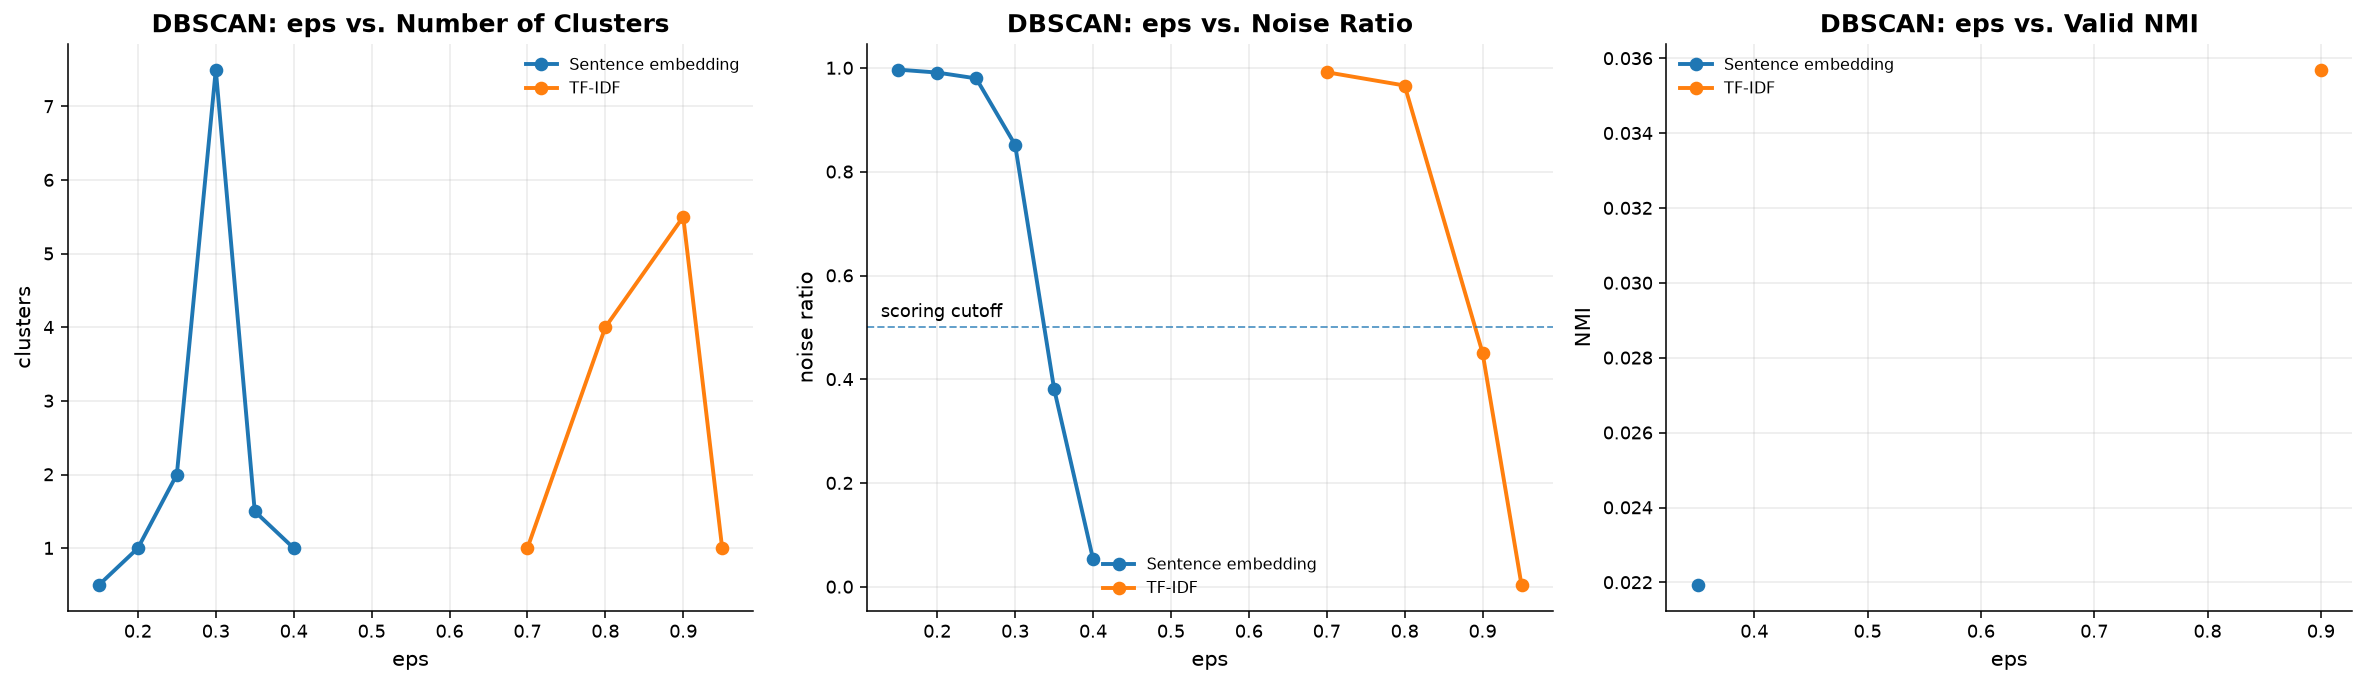

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for representation_name, group in dbscan_results_df.groupby("representation"):
    grouped = (
        group
        .groupby("eps", as_index=False)
        .agg({
            "n_clusters": "mean",
            "noise_ratio": "mean",
            "nmi": "mean",
            "valid_dbscan_score": "sum",
        })
    )

    axes[0].plot(
        grouped["eps"],
        grouped["n_clusters"],
        marker="o",
        linewidth=2,
        label=representation_name,
    )

    axes[1].plot(
        grouped["eps"],
        grouped["noise_ratio"],
        marker="o",
        linewidth=2,
        label=representation_name,
    )

    axes[2].plot(
        grouped["eps"],
        grouped["nmi"],
        marker="o",
        linewidth=2,
        label=representation_name,
    )

axes[0].set_title("DBSCAN: eps vs. Number of Clusters", fontsize=13, fontweight="bold")
axes[0].set_xlabel("eps")
axes[0].set_ylabel("clusters")

axes[1].set_title("DBSCAN: eps vs. Noise Ratio", fontsize=13, fontweight="bold")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("noise ratio")
axes[1].axhline(
    DBSCAN_MAX_NOISE_RATIO_FOR_SCORING,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)
axes[1].text(
    0.02,
    DBSCAN_MAX_NOISE_RATIO_FOR_SCORING + 0.02,
    "scoring cutoff",
    transform=axes[1].get_yaxis_transform(),
    fontsize=9,
)

axes[2].set_title("DBSCAN: eps vs. Valid NMI", fontsize=13, fontweight="bold")
axes[2].set_xlabel("eps")
axes[2].set_ylabel("NMI")

for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


**TODO:** How sensitive is DBSCAN to `eps`? Which setting creates meaningful clusters without marking too many books as noise?

Also explain the role of NMI and if DBSCAN is a good choice for this dataset.



#### How sensitive is DBSCAN to eps?

Extremely sensitive:

For sentence embeddings: eps=0.15 and 0.20 produce essentially 1 cluster with 100% noise. eps=0.25 spikes to 7–8 clusters but noise is still 83%. eps=0.30 drops back to ~2 clusters with noise below 0.50. 

the same sensitivity applies to td-idf.


#### Which setting creates meaningful clusters without too much noise?


- Sentence embedding: eps≈0.30, min_samples=5 
- TF-IDF: eps≈0.90, min_samples=5 



#### The role of NMI here:

NMI is only reported when noise_ratio ≤ 0.50 and n_clusters ≥ 2. the reasom is that a DBSCAN that labels 90% of books as noise and clusters the remaining 10% could get a high NMI on that tiny subset, but it's measuring the easiest books only. Restricting NMI on the noise prevents that.

#### Is DBSCAN a good choice for this dataset?

No. Genres are overlapping categories, not  separated by empty space. 



## 29. Hierarchical Agglomerative Clustering from scratch

Run HAC on a smaller subset because agglomerative clustering is computationally expensive.


In [53]:
def hac_from_distance_matrix(D, n_clusters=10, linkage="average"):
    D = np.asarray(D, dtype=np.float32)
    n = D.shape[0]

    if n_clusters < 1 or n_clusters > n:
        raise ValueError("n_clusters must be between 1 and the number of samples.")

    active = set(range(n))
    cluster_sizes = {i: 1 for i in range(n)}
    cluster_members = {i: [i] for i in range(n)}

    max_clusters = 2 * n
    cluster_dist = np.full((max_clusters, max_clusters), np.inf, dtype=np.float32)
    cluster_dist[:n, :n] = D
    np.fill_diagonal(cluster_dist, np.inf)

    next_cluster_id = n
    merge_distances = []

    while len(active) > n_clusters:
        active_list = sorted(active)
        best_i, best_j, best_distance = None, None, np.inf

        for i_index, i in enumerate(active_list[:-1]):
            js = active_list[i_index + 1:]
            distances = cluster_dist[i, js]
            min_position = int(np.argmin(distances))
            candidate_j = js[min_position]
            candidate_distance = float(distances[min_position])

            if candidate_distance < best_distance:
                best_i, best_j, best_distance = i, candidate_j, candidate_distance

        new_id = next_cluster_id
        next_cluster_id += 1

        members_i = cluster_members[best_i]
        members_j = cluster_members[best_j]

        cluster_members[new_id] = members_i + members_j
        cluster_sizes[new_id] = cluster_sizes[best_i] + cluster_sizes[best_j]

        active.remove(best_i)
        active.remove(best_j)

        for other in list(active):
            if linkage == "single":
                new_distance = min(cluster_dist[best_i, other], cluster_dist[best_j, other])
            elif linkage == "complete":
                new_distance = max(cluster_dist[best_i, other], cluster_dist[best_j, other])
            elif linkage == "average":
                size_i = cluster_sizes[best_i]
                size_j = cluster_sizes[best_j]
                new_distance = (
                    size_i * cluster_dist[best_i, other] +
                    size_j * cluster_dist[best_j, other]
                ) / (size_i + size_j)
            else:
                raise ValueError(f"Unknown linkage: {linkage}")

            cluster_dist[new_id, other] = new_distance
            cluster_dist[other, new_id] = new_distance

        active.add(new_id)
        merge_distances.append(best_distance)

    labels = np.empty(n, dtype=int)

    for new_label, cluster_id in enumerate(sorted(active)):
        for original_index in cluster_members[cluster_id]:
            labels[original_index] = new_label

    return labels, np.array(merge_distances, dtype=np.float32)


In [54]:
hac_sample_size = min(HAC_SAMPLE_SIZE, len(df_cluster))
hac_positions = rng.choice(np.arange(len(df_cluster)), size=hac_sample_size, replace=False)
hac_positions = np.sort(hac_positions)

hac_rows = []
hac_merge_history = {}

for representation_name in ["TF-IDF", "Sentence embedding"]:
    X_hac = CLUSTER_REPRESENTATIONS[representation_name][hac_positions]
    y_hac = y_cluster[hac_positions]

    print(f"Computing HAC distance matrix for {representation_name}...")
    D_hac = pairwise_distance_matrix(X_hac, metric="cosine")

    for linkage in HAC_LINKAGES:
        start_time = time.time()
        labels, merge_distances = hac_from_distance_matrix(
            D_hac,
            n_clusters=HAC_TARGET_K,
            linkage=linkage,
        )
        seconds = time.time() - start_time

        metrics = evaluate_clustering_run(
            y_hac,
            labels,
            X_hac,
            silhouette_metric="cosine",
            random_state=RANDOM_STATE,
        )

        run_key = f"HAC | {representation_name} | linkage={linkage} | K={HAC_TARGET_K}"
        clustering_assignments[run_key] = {
            "labels": labels,
            "positions": hac_positions,
            "representation": representation_name,
            "method": "HAC",
            "linkage": linkage,
            "k": HAC_TARGET_K,
        }
        hac_merge_history[run_key] = merge_distances

        hac_rows.append({
            "run_key": run_key,
            "method": "HAC",
            "representation": representation_name,
            "k": HAC_TARGET_K,
            "seed": np.nan,
            "eps": np.nan,
            "min_samples": np.nan,
            "linkage": linkage,
            "seconds": seconds,
            "inertia": np.nan,
            **metrics,
        })

hac_results_df = pd.DataFrame(hac_rows)
display(hac_results_df.sort_values(["representation", "linkage"]))


Computing HAC distance matrix for TF-IDF...
Computing HAC distance matrix for Sentence embedding...


,run_key,method,representation,k,seed,eps,min_samples,linkage,seconds,inertia,n_clusters,noise_ratio,silhouette,purity,nmi,rand_index
5,HAC | Sentence embedding | linkage=average | K=7,HAC,Sentence embedding,7,NaN,NaN,NaN,average,0.179080,NaN,7,0.0,0.009211,0.284,0.059516,0.272257
4,HAC | Sentence embedding | linkage=complete | K=7,HAC,Sentence embedding,7,NaN,NaN,NaN,complete,0.176728,NaN,7,0.0,0.035761,0.340,0.112907,0.646586
3,HAC | Sentence embedding | linkage=single | K=7,HAC,Sentence embedding,7,NaN,NaN,NaN,single,0.179613,NaN,7,0.0,-0.021728,0.280,0.045327,0.207100
2,HAC | TF-IDF | linkage=average | K=7,HAC,TF-IDF,7,NaN,NaN,NaN,average,0.176247,NaN,7,0.0,0.004696,0.280,0.071564,0.269044
1,HAC | TF-IDF | linkage=complete | K=7,HAC,TF-IDF,7,NaN,NaN,NaN,complete,0.179981,NaN,7,0.0,0.005308,0.320,0.078530,0.622811
0,HAC | TF-IDF | linkage=single | K=7,HAC,TF-IDF,7,NaN,NaN,NaN,single,0.195849,NaN,7,0.0,0.003541,0.284,0.064666,0.218988


### HAC merge-distance plots


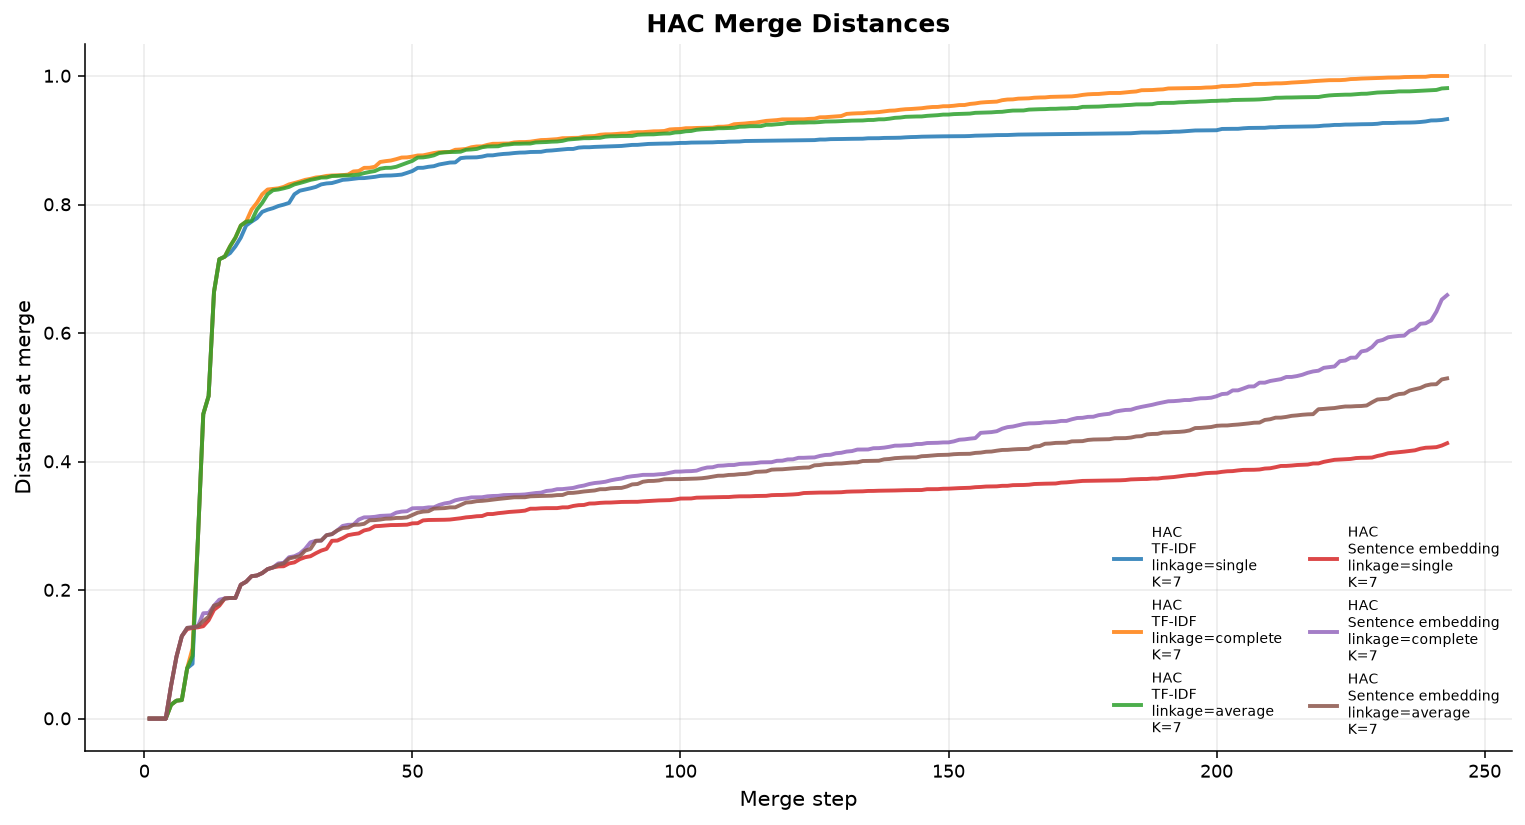

In [55]:
fig, ax = plt.subplots(figsize=(11, 6))

for run_key, distances in hac_merge_history.items():
    if len(distances) == 0:
        continue

    ax.plot(
        np.arange(1, len(distances) + 1),
        distances,
        linewidth=2,
        label=run_key.replace(" | ", "\n"),
        alpha=0.85,
    )

ax.set_title("HAC Merge Distances")
ax.set_xlabel("Merge step")
ax.set_ylabel("Distance at merge")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


**TODO:** Which linkage produces tighter clusters? Which linkage shows signs of chaining?



#### Which linkage produces tighter clusters?

Complete linkage  produces the tightest clusters. But for td_idf the difference is not substantial.

Average linkage is performing between complete and single and is a good choice.

#### Which linkage shows signs of chaining?

Single linkage. 

It merges clusters based on the minimum pairwise distance, which means two close points can connect two  distant groups. 

## 30. Final clustering comparison

Compare all clustering methods using the same evaluation metrics.


In [56]:
all_clustering_results_df = pd.concat(
    [
        kmeans_results_df,
        spherical_results_df,
        dbscan_results_df,
        hac_results_df,
    ],
    ignore_index=True,
)

all_clustering_results_df = all_clustering_results_df.sort_values(
    ["nmi", "silhouette", "purity"],
    ascending=[False, False, False],
).reset_index(drop=True)

display(all_clustering_results_df.head(30))

all_clustering_results_df.to_csv(CLUSTER_OUTPUT_RESULTS_CSV, index=False)
print("Saved clustering results to:", CLUSTER_OUTPUT_RESULTS_CSV)


,run_key,method,representation,k,seed,eps,min_samples,linkage,seconds,inertia,n_clusters,noise_ratio,silhouette,purity,nmi,rand_index,clustered_points,valid_dbscan_score
0,K-Means | Sentence embedding | K=20 | seed=43,K-Means,Sentence embedding,20.0,43.0,NaN,NaN,,0.104682,874.579773,20,0.0,0.021259,0.5505,0.256701,0.798883,NaN,NaN
1,Spherical K-Means | Sentence embedding | K=20 ...,Spherical K-Means,Sentence embedding,20.0,43.0,NaN,NaN,,0.040336,501.132629,20,0.0,0.038220,0.5290,0.246785,0.797437,NaN,NaN
2,K-Means | Sentence embedding | K=15 | seed=42,K-Means,Sentence embedding,15.0,42.0,NaN,NaN,,0.106248,885.751099,15,0.0,0.027517,0.5340,0.237894,0.788909,NaN,NaN
3,K-Means | Sentence embedding | K=20 | seed=42,K-Means,Sentence embedding,20.0,42.0,NaN,NaN,,0.117687,877.663879,20,0.0,0.025476,0.5295,0.237629,0.793579,NaN,NaN
4,Spherical K-Means | Sentence embedding | K=20 ...,Spherical K-Means,Sentence embedding,20.0,42.0,NaN,NaN,,0.042701,502.148651,20,0.0,0.044838,0.5240,0.235078,0.793406,NaN,NaN
5,Spherical K-Means | Sentence embedding | K=15 ...,Spherical K-Means,Sentence embedding,15.0,42.0,NaN,NaN,,0.060585,507.683838,15,0.0,0.049396,0.5275,0.234427,0.788036,NaN,NaN
6,K-Means | Sentence embedding | K=15 | seed=43,K-Means,Sentence embedding,15.0,43.0,NaN,NaN,,0.109572,886.354919,15,0.0,0.021970,0.5080,0.223327,0.784231,NaN,NaN
7,Spherical K-Means | Sentence embedding | K=15 ...,Spherical K-Means,Sentence embedding,15.0,43.0,NaN,NaN,,0.056984,507.811279,15,0.0,0.041767,0.5075,0.222404,0.784788,NaN,NaN
8,Spherical K-Means | Sentence embedding | K=7 |...,Spherical K-Means,Sentence embedding,7.0,42.0,NaN,NaN,,0.081043,533.205444,7,0.0,0.044976,0.4965,0.215960,0.748540,NaN,NaN
9,K-Means | Sentence embedding | K=7 | seed=42,K-Means,Sentence embedding,7.0,42.0,NaN,NaN,,0.163596,923.784607,7,0.0,0.023574,0.4920,0.209171,0.746992,NaN,NaN


Saved clustering results to: clustering_results.csv


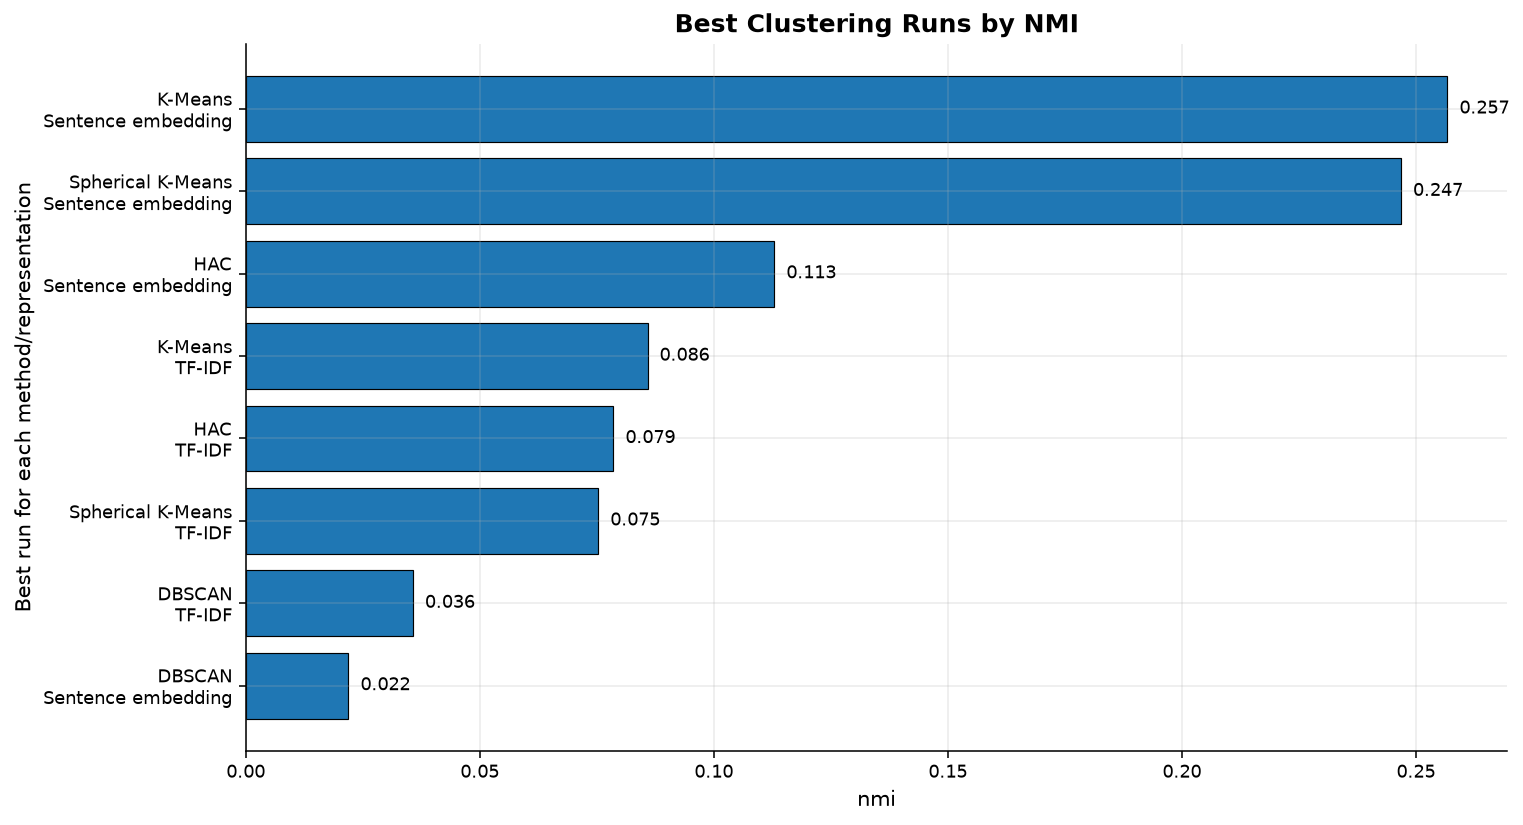

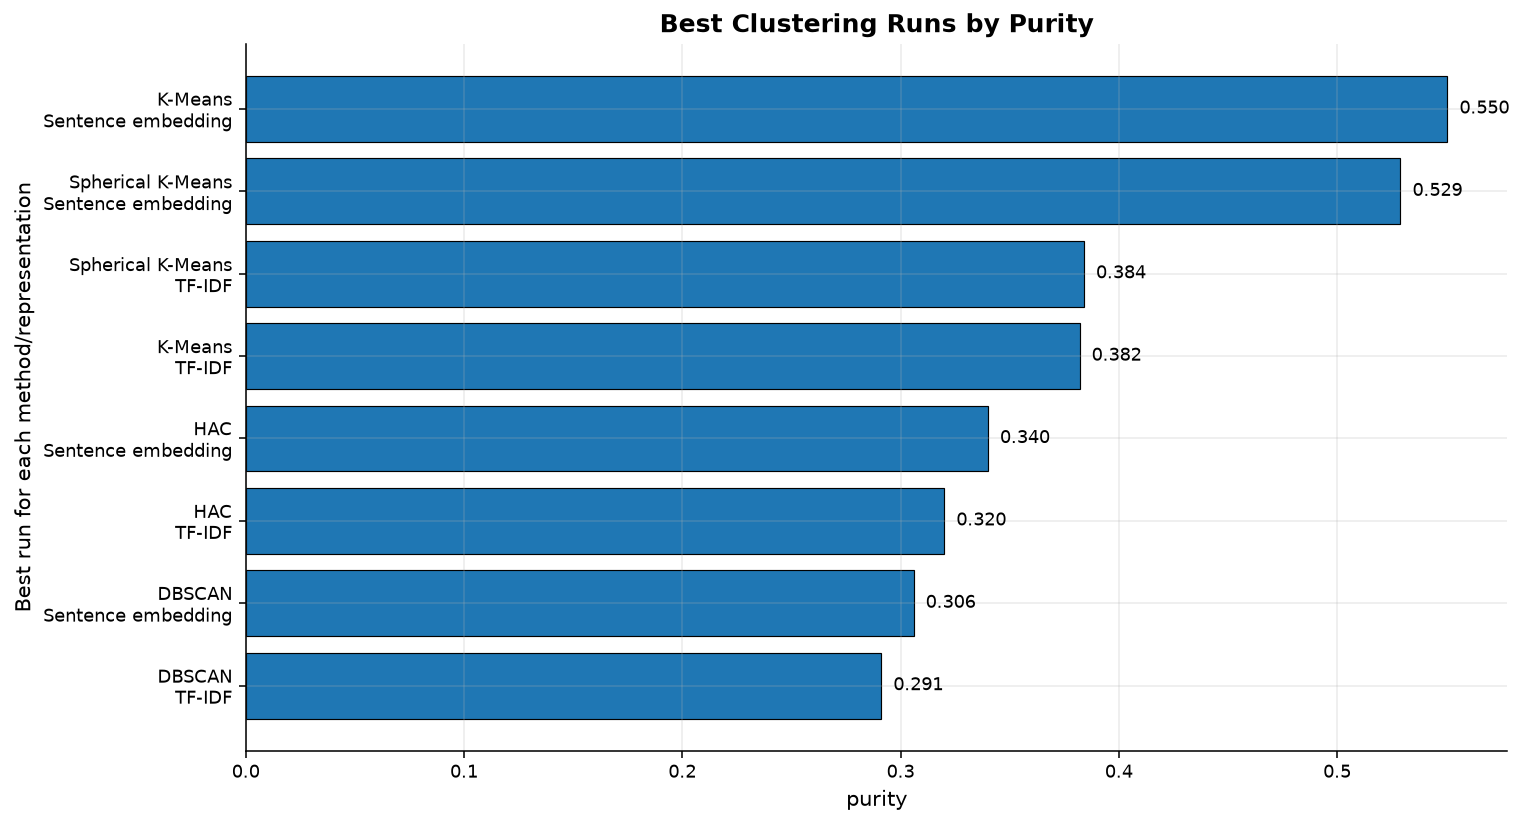

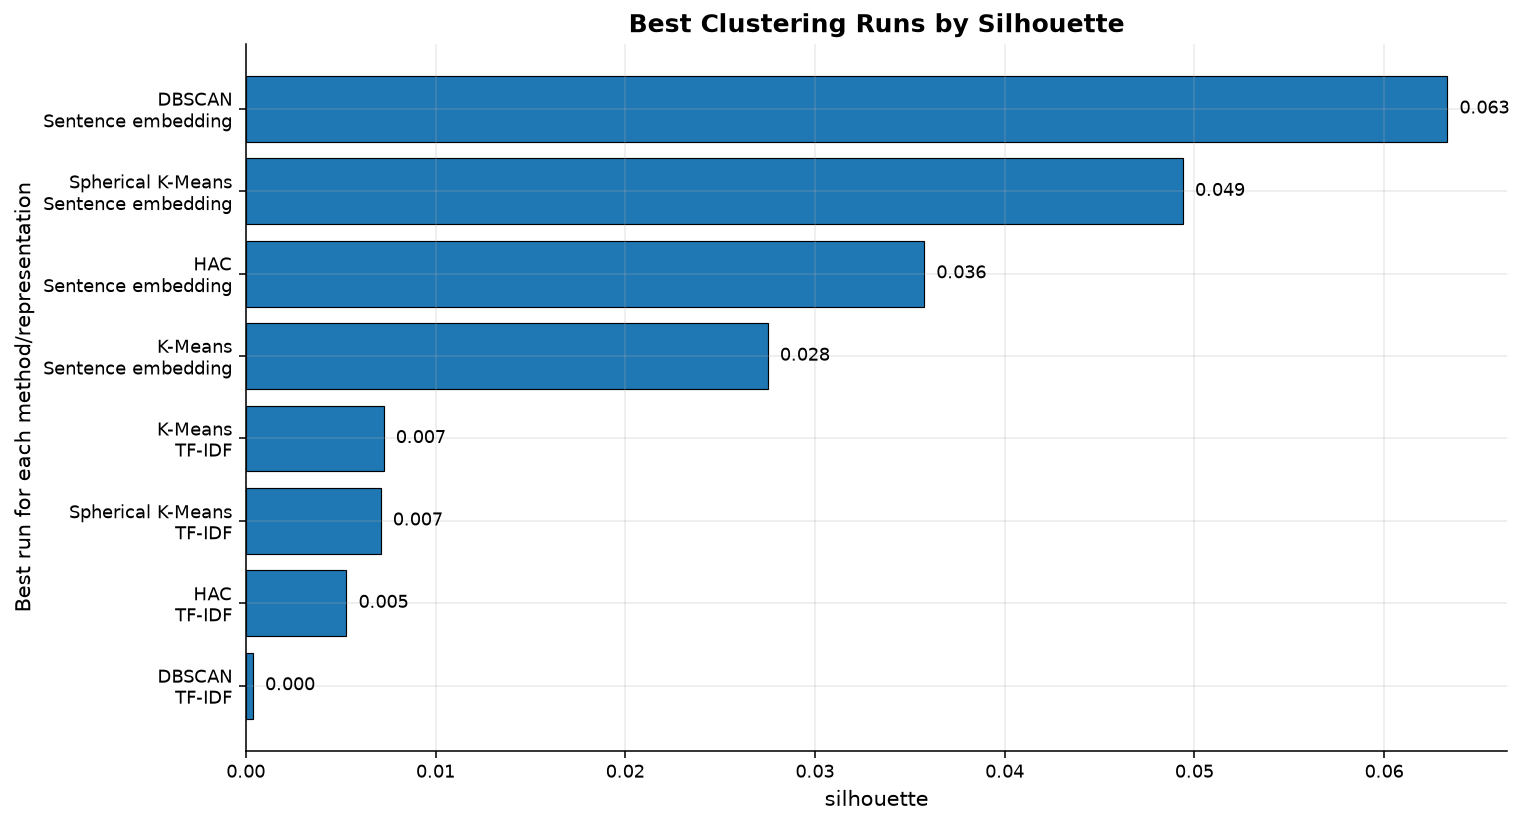

In [58]:
plot_final_clustering_comparison(
    all_clustering_results_df,
    metric="nmi",
    title="Best Clustering Runs by NMI",
)

plot_final_clustering_comparison(
    all_clustering_results_df,
    metric="purity",
    title="Best Clustering Runs by Purity",
)

plot_final_clustering_comparison(
    all_clustering_results_df,
    metric="silhouette",
    title="Best Clustering Runs by Silhouette",
)


**TODO:** Which method gives the best numerical result? Is it also the most interpretable method?


#### Which method gives the best numerical result?

It depends on the metric:

- NMI: K-Means / Sentence embedding == 0.257, Spherical K-Means / Sentence embedding = 0.247


- Purity:  K-Means / Sentence embedding = 0.550, Spherical K-Means / Sentence embedding =0.529. 


- Silhouette: DBSCAN / Sentence embedding wins =0.063 Spherical K-Means / Sentence embedding =0.049

The winner is between the K-Means / Sentence embedding and  Spherical K-Means / Sentence embedding.

#### Is it also the most interpretable?

No. K-Means on sentence embeddings is numerically the best but the least interpretable.

the cluster centroids  are in a 1024-dimensional dense space. There is no natural way to answer "what is this cluster about" from the centroid vector.


## 31. Inspect the selected clustering result

Select the best run by NMI and inspect its clusters visually.


Selected clustering run:
K-Means | Sentence embedding | K=20 | seed=43

method                       K-Means
representation    Sentence embedding
n_clusters                        20
noise_ratio                      0.0
silhouette                  0.021259
purity                        0.5505
nmi                         0.256701
rand_index                  0.798883
Name: 0, dtype: object


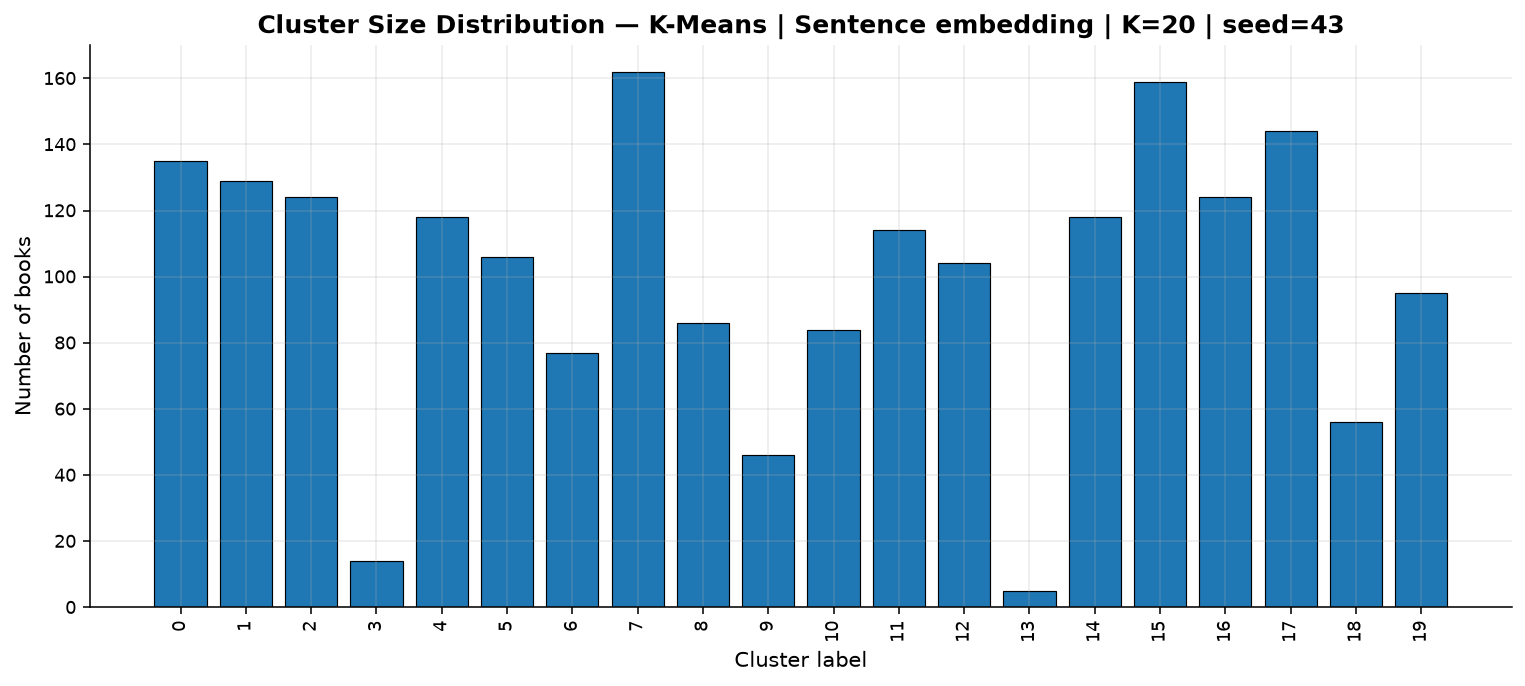

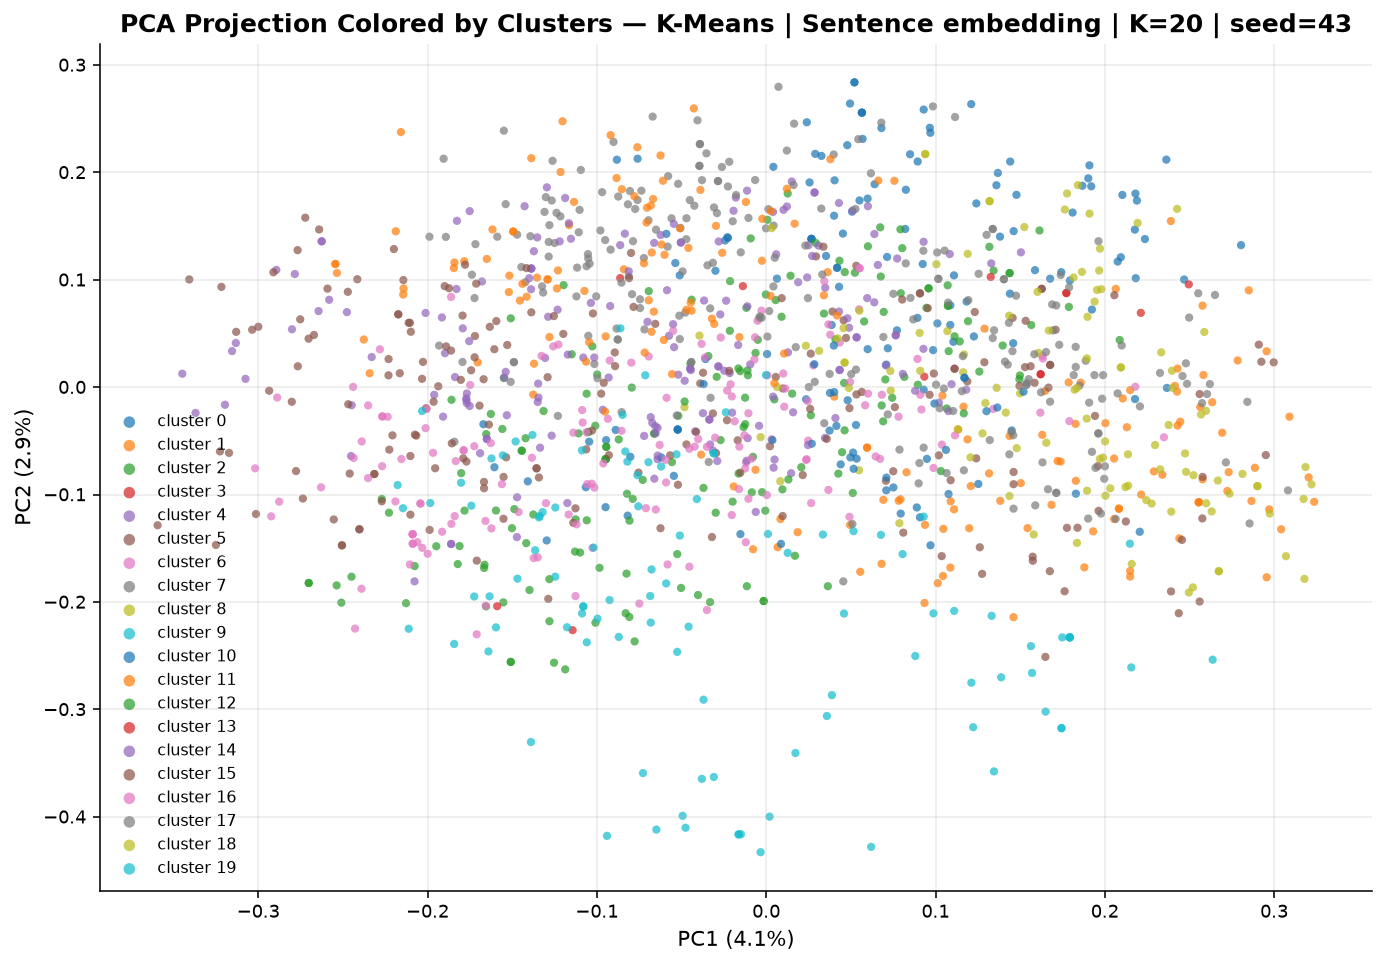

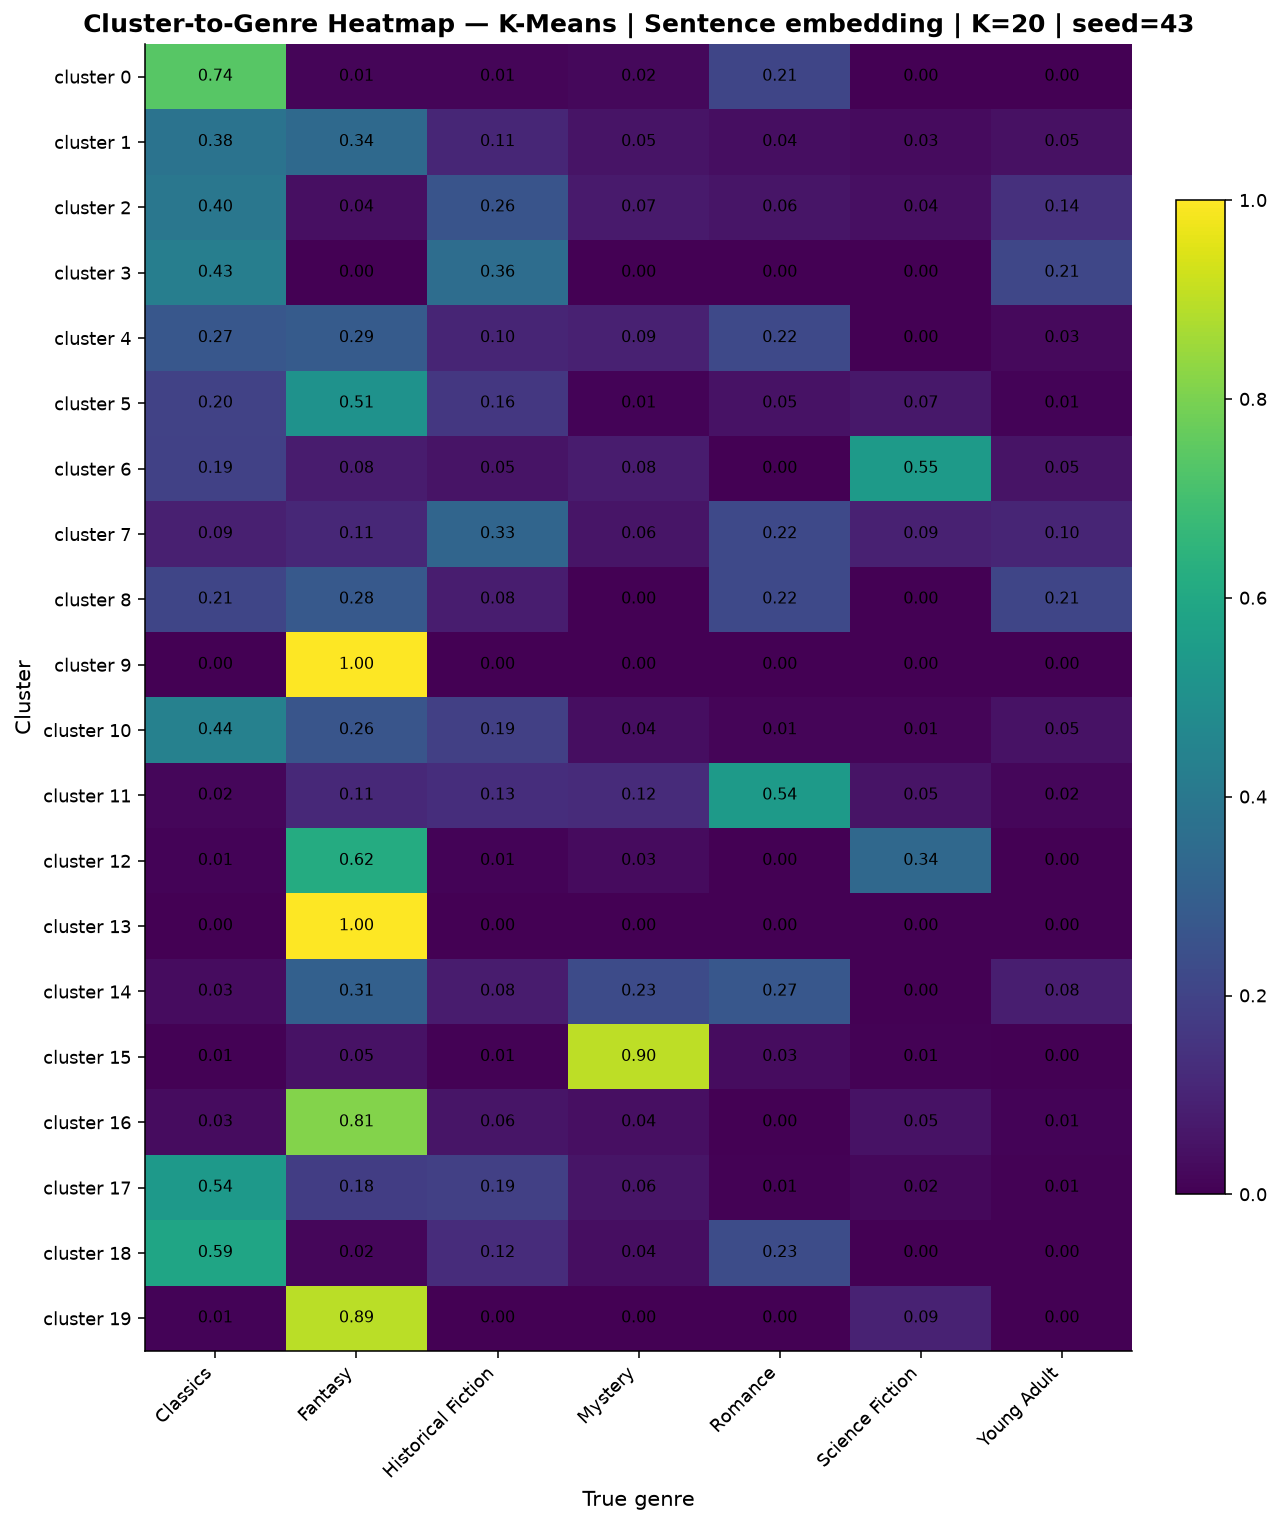

In [59]:
best_cluster_row = all_clustering_results_df.dropna(subset=["nmi"]).iloc[0]
best_cluster_key = best_cluster_row["run_key"]
best_cluster_run = clustering_assignments[best_cluster_key]

best_cluster_labels = best_cluster_run["labels"]
best_cluster_positions = best_cluster_run["positions"]
best_cluster_representation = best_cluster_run["representation"]
best_cluster_X = CLUSTER_REPRESENTATIONS[best_cluster_representation][best_cluster_positions]
best_cluster_y = y_cluster[best_cluster_positions]

print("Selected clustering run:")
print(best_cluster_key)
print()
print(best_cluster_row[[
    "method",
    "representation",
    "n_clusters",
    "noise_ratio",
    "silhouette",
    "purity",
    "nmi",
    "rand_index",
]])

plot_cluster_size_distribution(
    best_cluster_labels,
    title=f"Cluster Size Distribution — {best_cluster_key}",
)

plot_cluster_pca(
    best_cluster_X,
    best_cluster_labels,
    title=f"PCA Projection Colored by Clusters — {best_cluster_key}",
    max_points=PCA_CLUSTER_MAX_POINTS,
    random_state=RANDOM_STATE,
)

plot_cluster_genre_heatmap(
    best_cluster_y,
    best_cluster_labels,
    title=f"Cluster-to-Genre Heatmap — {best_cluster_key}",
    ignore_noise=True,
)


**TODO:** Do the discovered clusters correspond to genres, broader themes, or something else?

The clusters partially correspond to genres, but the alignment is imperfect. 

Certain genre pairs that are semantically close — Fantasy/Science Fiction, Mystery/Thriller, Historical Fiction/Classics tend to merge into shared clusters.

- we have a similar issue in the clssiffing section of the dataset.


## 32. Cluster interpretation

For each cluster, inspect its dominant genres, top TF-IDF terms, representative books, and sample titles.


In [60]:
def nearest_books_to_cluster_center(X, positions, labels, cluster_id, top_n=5):
    cluster_mask = labels == cluster_id
    X_cluster = np.asarray(X[cluster_mask], dtype=np.float32)

    if len(X_cluster) == 0:
        return []

    center = X_cluster.mean(axis=0, keepdims=True)
    X_norm = l2_normalize_rows(X_cluster)
    center_norm = l2_normalize_rows(center)
    similarities = (X_norm @ center_norm.T).ravel()

    local_top = np.argsort(-similarities)[:top_n]
    global_positions = positions[cluster_mask][local_top]

    titles = []
    for pos in global_positions:
        title = df_cluster.loc[pos, TITLE_COLUMN] if TITLE_COLUMN in df_cluster.columns else f"row {pos}"
        titles.append(str(title))

    return titles


def top_terms_for_cluster(tfidf_matrix, feature_names, positions, labels, cluster_id, top_n=12):
    cluster_mask = labels == cluster_id
    selected_positions = positions[cluster_mask]

    if len(selected_positions) == 0:
        return []

    X_sub = tfidf_matrix[selected_positions]
    if sparse.issparse(X_sub):
        mean_vector = np.asarray(X_sub.mean(axis=0)).ravel()
    else:
        mean_vector = np.asarray(X_sub).mean(axis=0).ravel()

    if mean_vector.max() <= 0:
        return []

    top_indices = np.argsort(-mean_vector)[:top_n]
    return feature_names[top_indices].tolist()


def build_cluster_interpretation_table(run_key, top_n_terms=12, top_n_books=5):
    run = clustering_assignments[run_key]
    labels = run["labels"]
    positions = run["positions"]
    representation_name = run["representation"]

    X_repr = CLUSTER_REPRESENTATIONS[representation_name][positions]

    rows = []
    for cluster_id in sorted(pd.Series(labels).unique()):
        cluster_mask = labels == cluster_id
        size = int(cluster_mask.sum())

        true_genres = label_encoder.inverse_transform(y_cluster[positions][cluster_mask])
        genre_counts = pd.Series(true_genres).value_counts()

        top_genres = ", ".join([
            f"{genre} ({count})"
            for genre, count in genre_counts.head(5).items()
        ])

        if cluster_id == -1:
            top_terms = []
            representative_books = []
        else:
            top_terms = top_terms_for_cluster(
                X_cluster_tfidf_sparse,
                cluster_tfidf_feature_names,
                positions,
                labels,
                cluster_id,
                top_n=top_n_terms,
            )
            representative_books = nearest_books_to_cluster_center(
                X_repr,
                positions,
                labels,
                cluster_id,
                top_n=top_n_books,
            )

        sample_positions = positions[cluster_mask][:5]
        sample_titles = []
        for pos in sample_positions:
            title = df_cluster.loc[pos, TITLE_COLUMN] if TITLE_COLUMN in df_cluster.columns else f"row {pos}"
            sample_titles.append(str(title))

        rows.append({
            "cluster": cluster_id,
            "size": size,
            "top_true_genres": top_genres,
            "top_terms": ", ".join(top_terms),
            "representative_books": " | ".join(representative_books),
            "sample_titles": " | ".join(sample_titles),
        })

    return pd.DataFrame(rows).sort_values("size", ascending=False).reset_index(drop=True)


cluster_interpretation_df = build_cluster_interpretation_table(best_cluster_key)
display(cluster_interpretation_df)

cluster_interpretation_df.to_csv(CLUSTER_OUTPUT_INTERPRETATION_CSV, index=False)
print("Saved cluster interpretation to:", CLUSTER_OUTPUT_INTERPRETATION_CSV)


,cluster,size,top_true_genres,top_terms,representative_books,sample_titles
0,7,162,"Historical Fiction (53), Romance (36), Fantasy...","her, she, in, to, is, their, family, with, as,...",Secret Garden | The Secret Garden | Anne of Gr...,"The Lion, the Witch and the Wardrobe | Lovely ..."
1,15,159,"Mystery (143), Fantasy (8), Romance (5), Class...","to, is, in, murder, on, his, he, an, her, she,...",Trace | Trace | Hour Game | Poirot Investigate...,Angels & Demons | The Lovely Bones | The Lovel...
2,17,144,"Classics (78), Historical Fiction (27), Fantas...","in, his, is, to, of the, by, this, that, trans...",The Brothers Karamazov | Siddhartha | The Brot...,Lord of the Flies | Dracula | Anna Karenina | ...
3,0,135,"Classics (100), Romance (28), Mystery (3), His...","her, in, to, novel, is, of the, love, by, with...",Pride and Prejudice | Sense and Sensibility | ...,Pride and Prejudice | Pride and Prejudice | Pr...
4,1,129,"Classics (49), Fantasy (44), Historical Fictio...","book, edition, text, original, paperback, this...",A Tale of Two Cities | Leviathan | The Scarlet...,To Kill a Mockingbird | The Catcher In The Rye...
5,2,124,"Classics (49), Historical Fiction (32), Young ...","in, his, american, is, to, of the, an, by, nov...",Invisible Man | Invisible Man | Angle of Repos...,To Kill a Mockingbird | To Kill a Mockingbird ...
6,16,124,"Fantasy (101), Historical Fiction (7), Science...","to, in, his, he, king, is, stephen king, that,...",'Salem's Lot | Skeleton Crew | Nightmares and ...,Twilight | Frankenstein | Frankenstein | The S...
7,14,118,"Fantasy (36), Romance (32), Mystery (27), Youn...","her, she, to, is, in, for, at, but, who, with,...",School's Out—Forever | Three to Get Deadly | S...,The Catcher In The Rye | The Catcher in the Ry...
8,4,118,"Fantasy (34), Classics (32), Romance (26), His...","to, in, is, with, his, as, of the, that, an, f...",Perfume: The Story of a Murderer | Blind Willo...,The Great Gatsby | Memoirs of a Geisha | Memoi...
9,11,114,"Romance (62), Historical Fiction (15), Mystery...","her, she, love, to, in, is, that, his, he, for...",Suzanne's Diary for Nicholas | Message in a Bo...,The Book Thief | The Book Thief | The Time Tra...


Saved cluster interpretation to: clustering_cluster_interpretation.csv


**TODO:** Pick five clusters. For each one, explain what the cluster seems to represent and whether its mixed genres make sense.




#### Cluster 17 

Top terms: `ring, tolkien, rings, the rings, lord, the ring`. 

Genre: Fantasy (46/46).

This is the cleanest cluster in the entire table.

the top words are more specifically related to Tolkin`s Lordof the rings, and since and since there are alot of these books and they are all simillar in letrature; they create their own cluster.

#### Cluster 13 

Top terms: `shakespeare, play, the play, plays, of shakespeare`.

Genres: Fantasy (24), Romance (19), Young Adult (18)

Since Shakespeare is the dominate figure in classical victorian english leatreture and his association with Plays. the words make sense. Also his books include mostly the genres mentioned so that makes sense as well.



#### Cluster 11

Top terms: `to, earth, is, planet, it, his, that, in, are`.

 Genres: Fantasy (64), Science Fiction (35), Mystery (3).

with overuse of words such as planet, earth etc. we do expect the genre sience fiction here; but the number of books labeled Fantasy here is even greater which is probably because the science fictions are also label fantasy.


#### Cluster 12 

Top terms: `to, magic, of the, is, he, his, but, with, in`. 

Genres: Fantasy (85), Science Fiction (9), Classics (1).

many of the words are none informative. but the single word `magic` is the indication of the magic related fantasies like *Silver on the Tree*, *The Elfstones of Shannara*, and  Harry Potter. THerefore the genres make sense as well.


#### Cluster 3

Top terms: `her, in, to, novel, is, of the, love, by, with`. 

Genres: Classics (100), Romance (28), Mystery (3).

Representative books: *Pride and Prejudice*, *Sense and Sensibility*

 These aare classic books written by `Jane austin` an English writer in the 19th century. who is widely regarded as the first mainstream female writer known to western civilization. Her books are mostly about girls coming of age in England, hense the ggenres and word `her` makes total sense.

## 33. DBSCAN noise examples

If the selected or any DBSCAN run contains noise points, inspect examples that DBSCAN could not place into a cluster.


In [61]:
dbscan_candidate_rows = all_clustering_results_df[
    (all_clustering_results_df["method"] == "DBSCAN") &
    (all_clustering_results_df["noise_ratio"] > 0)
].sort_values(["nmi", "noise_ratio"], ascending=[False, True])

if len(dbscan_candidate_rows) == 0:
    print("No DBSCAN run produced noise points in the tested settings.")
else:
    dbscan_key = dbscan_candidate_rows.iloc[0]["run_key"]
    dbscan_run = clustering_assignments[dbscan_key]

    labels = dbscan_run["labels"]
    positions = dbscan_run["positions"]
    noise_positions = positions[labels == -1]

    print("DBSCAN run selected for noise inspection:")
    print(dbscan_key)
    print("Number of noise books:", len(noise_positions))

    columns_to_show = []
    if TITLE_COLUMN in df_cluster.columns:
        columns_to_show.append(TITLE_COLUMN)
    columns_to_show += ["label", DESCRIPTION_COLUMN]

    display(df_cluster.loc[noise_positions, columns_to_show].head(15))


DBSCAN run selected for noise inspection:
DBSCAN | TF-IDF | eps=0.9 | min_samples=5
Number of noise books: 168


,title,label,description
5,To Kill a Mockingbird,Young Adult,",,"
15,1984,Science Fiction,"Aldous Huxley's,and George Orwell's,are the gr..."
16,1984,Science Fiction,"The year 1984 has come and gone, but George Or..."
49,The Kite Runner,Historical Fiction,Taking us from Afghanistan in the final days o...
58,Lord Of The Flies,Young Adult,"As New, 50th Anniversary Edition. 1st Edition ..."
118,The Illustrated Jane Eyre,Classics,A devoted readership will recognize Dame Darcy...
119,The Time Traveler's Wife,Science Fiction,"This is the story of Henry and Clare, who've k..."
120,The Time Traveler's Wife,Science Fiction,A dazzling novel in the most untraditional fas...
143,Life of Pi,Fantasy,"After the tragic sinking of a cargo ship, a so..."
155,The Curious Incident of the Dog in the Night-Time,Mystery,Christopher John Francis Boone knows all the c...


**TODO:** Are the noise books actually unusual, or are they examples of parameter sensitivity?


mostly parameter sensitivity.Relaxing eps by one step would almost certainly absorb most of them into the nearest cluster.

Several of these have clearly wrong genre:

- *The Shining* labeled Fantasy (it's Horror)
- *Life of Pi* labeled Fantasy (it's Literary Fiction)

- *Lord of the Flies* labeled Young Adult (it's taught as a Classic)
- *The Time Traveler's Wife* labeled Science Fiction (primarily a Romance)

This is actually interesting the words inside the book are actually important in the final clustering not what we think the genre is. 

## 34. Final clustering questions

Answer these after completing the experiments:

1. Which representation gives better clusters: TF-IDF or sentence embeddings?


Sentence embeddings, by a large margin. NMI ~0.25 vs ~0.08 for TF-IDF across all methods. TF-IDF vectors are too sparse and distance-compressed to form meaningful clusters.


2. Which method is strongest numerically: K-Means, Spherical K-Means, DBSCAN, or HAC?



K-Means / sentence embedding wins on NMI (0.257) and purity (0.550) but spherical K-Means is 99% percentile.


3. Which method gives the most interpretable clusters?


 K-Means on TF-IDF. Despite weaker scores, TF-IDF centroids give you human-readable top terms per cluster. 


4. Does clustering recover the genre labels well?

 Partially. Semantically close genres (Fantasy/Sci-Fi, Classics/Historical Fiction, Romance/Historical Fiction) often mix because their descriptions overlap.



5. What does clustering reveal that classification did not?


-  author-specific clusters, can be found by clustering. by simillar vocabulary, world POV of the same writer.  

-  several genre label assignments in the dataset are wrong or debatable. 

- some genre pairs are indistinguishable from text.